# Диагностика сердечно-сосудистых заболеваний по медицинским показателям

**Домашнее задание #3 — ML Start 2026**

**Датасет:** Heart Disease — Cleveland Clinic Foundation (UCI ML Repository)

## Постановка задачи

Бинарная классификация: определить наличие ишемической болезни сердца (ИБС)
у пациента по результатам неинвазивных обследований — анамнез, ЭКГ покоя,
нагрузочный тест, биохимия крови.

Практический смысл: ангиография (золотой стандарт диагностики) — инвазивная,
дорогая и рискованная процедура. Модель, работающая на дешёвых показателях,
позволяет приоритизировать пациентов для направления на ангиографию.

**Ключевое следствие для выбора метрики:** цена ошибок несимметрична.
False Negative (пропустить больного) — потенциально фатален.
False Positive (лишнее направление на обследование) — это издержки, но не жизнь.
Поэтому целевая метрика — **ROC-AUC** (для сравнения моделей независимо от порога),
плюс отдельно **sensitivity/specificity** при подобранном пороге.

## План работы

1. Загрузка данных, EDA, обработка пропусков и выбросов, feature engineering
2. Классические ML-модели (linear / tree-based / ensemble / boosting) + подбор гиперпараметров + CV
3. Нейронная сеть MLP на PyTorch с регуляризацией
4. Stacking и Blending
5. Интерпретация (SHAP, permutation importance), error analysis
6. Сводное сравнение и выводы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     StratifiedKFold, GridSearchCV, RandomizedSearchCV,
                                     learning_curve, validation_curve)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             log_loss, brier_score_loss)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.width', 150)
pd.set_option('display.precision', 3)

SEED = 42
np.random.seed(SEED)

print('Библиотеки загружены. SEED =', SEED)

Библиотеки загружены. SEED = 42


In [2]:
# Глушим шумные предупреждения, но НЕ те, что сигнализируют о реальном сбое.
# FitFailedWarning и "Scoring failed" — признак того, что модель не обучилась
# и CV молча вернёт nan. Их нужно видеть.
from sklearn.exceptions import FitFailedWarning, ConvergenceWarning

warnings.filterwarnings('ignore')
warnings.filterwarnings('always', category=FitFailedWarning)
warnings.filterwarnings('always', category=UserWarning, message='.*Scoring failed.*')

print('Предупреждения о сбоях обучения и скоринга снова видимы.')

Предупреждения о сбоях обучения и скоринга снова видимы.


## 1. Загрузка данных

Данные: **processed.cleveland.data** из UCI ML Repository — 303 пациента,
13 диагностических признаков + целевая переменная.

Исходная целевая переменная `num` принимает значения 0–4 (степень сужения
коронарных артерий по ангиографии). Стандартная постановка задачи для этого
датасета — бинаризация: `0` = здоров, `1–4` = есть ИБС.

Пропуски закодированы символом `?`.

In [3]:
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
LOCAL_PATH = "cleveland.csv"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Загружаем один раз и кэшируем локально: сервер UCI периодически недоступен,
# а упавшая ячейка в сданном ноутбуке — плохо.
if os.path.exists(LOCAL_PATH):
    df_raw = pd.read_csv(LOCAL_PATH)
    print('Загружено из локального кэша')
else:
    df_raw = pd.read_csv(URL, names=columns, na_values='?')
    df_raw.to_csv(LOCAL_PATH, index=False)
    print('Загружено с UCI и сохранено в', LOCAL_PATH)

print(f'Размер датасета: {df_raw.shape[0]} объектов x {df_raw.shape[1]} колонок')
df_raw.head()

Загружено из локального кэша
Размер датасета: 303 объектов x 14 колонок


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df_raw.info()
print()
print('Пропуски по колонкам:')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print()
print('Дубликаты строк:', df_raw.duplicated().sum())
print()
print('Распределение исходной целевой переменной (степень поражения 0-4):')
print(df_raw['target'].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Пропуски по колонкам:
ca      4
thal    2
dtype: int64

Дубликаты строк: 0

Распределение исходной целевой переменной (степень поражения 0-4):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int

### 1.1 Описание признаков

| Признак | Тип | Описание |
|---|---|---|
| `age` | числовой | Возраст, лет |
| `sex` | бинарный | Пол: 1 = мужчина, 0 = женщина |
| `cp` | категориальный | Тип боли в груди: 1 = типичная стенокардия, 2 = атипичная, 3 = не ангинозная, 4 = бессимптомно |
| `trestbps` | числовой | Артериальное давление в покое, мм рт. ст. |
| `chol` | числовой | Холестерин сыворотки, мг/дл |
| `fbs` | бинарный | Глюкоза натощак > 120 мг/дл (1 = да) |
| `restecg` | категориальный | ЭКГ покоя: 0 = норма, 1 = аномалия ST-T, 2 = гипертрофия ЛЖ |
| `thalach` | числовой | Максимальная достигнутая ЧСС при нагрузке |
| `exang` | бинарный | Стенокардия, вызванная нагрузкой (1 = да) |
| `oldpeak` | числовой | Депрессия сегмента ST при нагрузке относительно покоя |
| `slope` | категориальный | Наклон сегмента ST на пике: 1 = восходящий, 2 = плоский, 3 = нисходящий |
| `ca` | порядковый | Число крупных сосудов (0–3), окрашенных при флюороскопии |
| `thal` | категориальный | Таллиевый стресс-тест: 3 = норма, 6 = фиксированный дефект, 7 = обратимый дефект |
| `target` | **целевая** | Степень поражения коронарных артерий 0–4 → бинаризуем в 0/1 |

**Важное замечание о признаках `ca` и `thal`.** Оба получены инвазивными или дорогими
процедурами (флюороскопия, сцинтиграфия с таллием). Формально это не утечка данных —
они измеряются до постановки диагноза по ангиографии, — но они гораздо ближе к
целевой переменной, чем остальные признаки. Ниже это подтвердится в анализе
важности признаков, и мы вернёмся к этому в выводах: модель без `ca`/`thal`
имеет другой практический смысл (скрининг), чем модель с ними (уточняющая диагностика).

In [5]:
df = df_raw.copy()

# Бинаризация целевой переменной: 0 = здоров, 1-4 = есть ИБС
df['target'] = (df['target'] > 0).astype(int)

print('Распределение классов после бинаризации:')
print(df['target'].value_counts())
print()
print(df['target'].value_counts(normalize=True).round(3))
print()
print(f'Дисбаланс умеренный: {df["target"].mean():.1%} положительного класса.')
print('SMOTE/undersampling не требуется, но stratify при разбиении обязателен.')

Распределение классов после бинаризации:
target
0    164
1    139
Name: count, dtype: int64

target
0    0.541
1    0.459
Name: proportion, dtype: float64

Дисбаланс умеренный: 45.9% положительного класса.
SMOTE/undersampling не требуется, но stratify при разбиении обязателен.


## 2. Разведочный анализ данных (EDA)

### 2.1 Целевая переменная

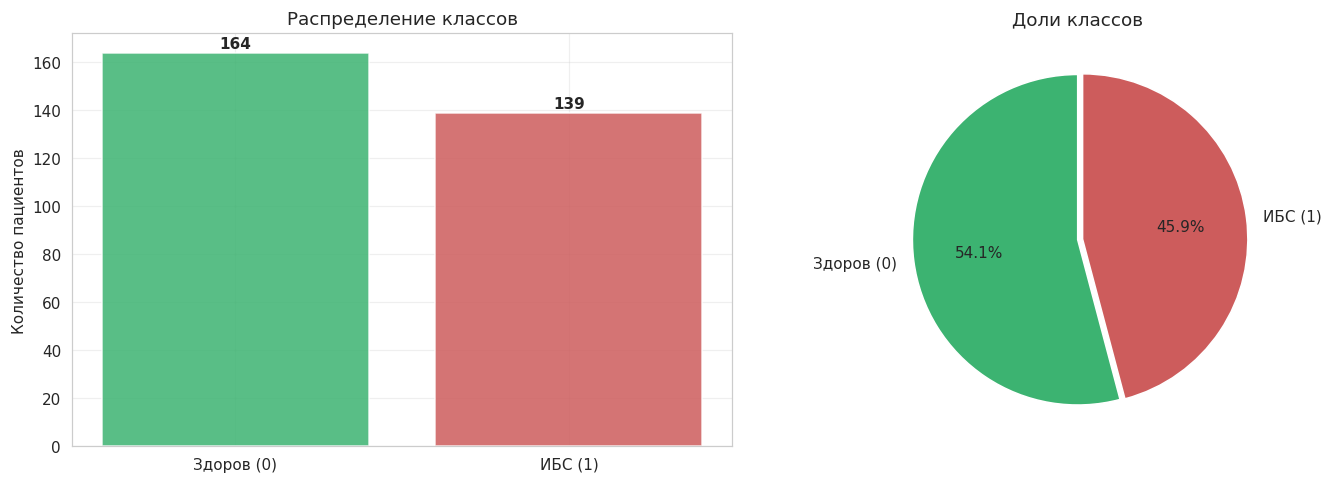

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

vc = df['target'].value_counts().sort_index()
bars = axes[0].bar(['Здоров (0)', 'ИБС (1)'], vc.values, color=['mediumseagreen', 'indianred'], alpha=0.85)
for b, v in zip(bars, vc.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('Количество пациентов')
axes[0].set_title('Распределение классов')

axes[1].pie(vc.values, labels=['Здоров (0)', 'ИБС (1)'], autopct='%1.1f%%',
            colors=['mediumseagreen', 'indianred'], startangle=90, explode=(0, 0.03))
axes[1].set_title('Доли классов')

plt.tight_layout()
plt.show()

In [7]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


### 2.2 Распределения признаков

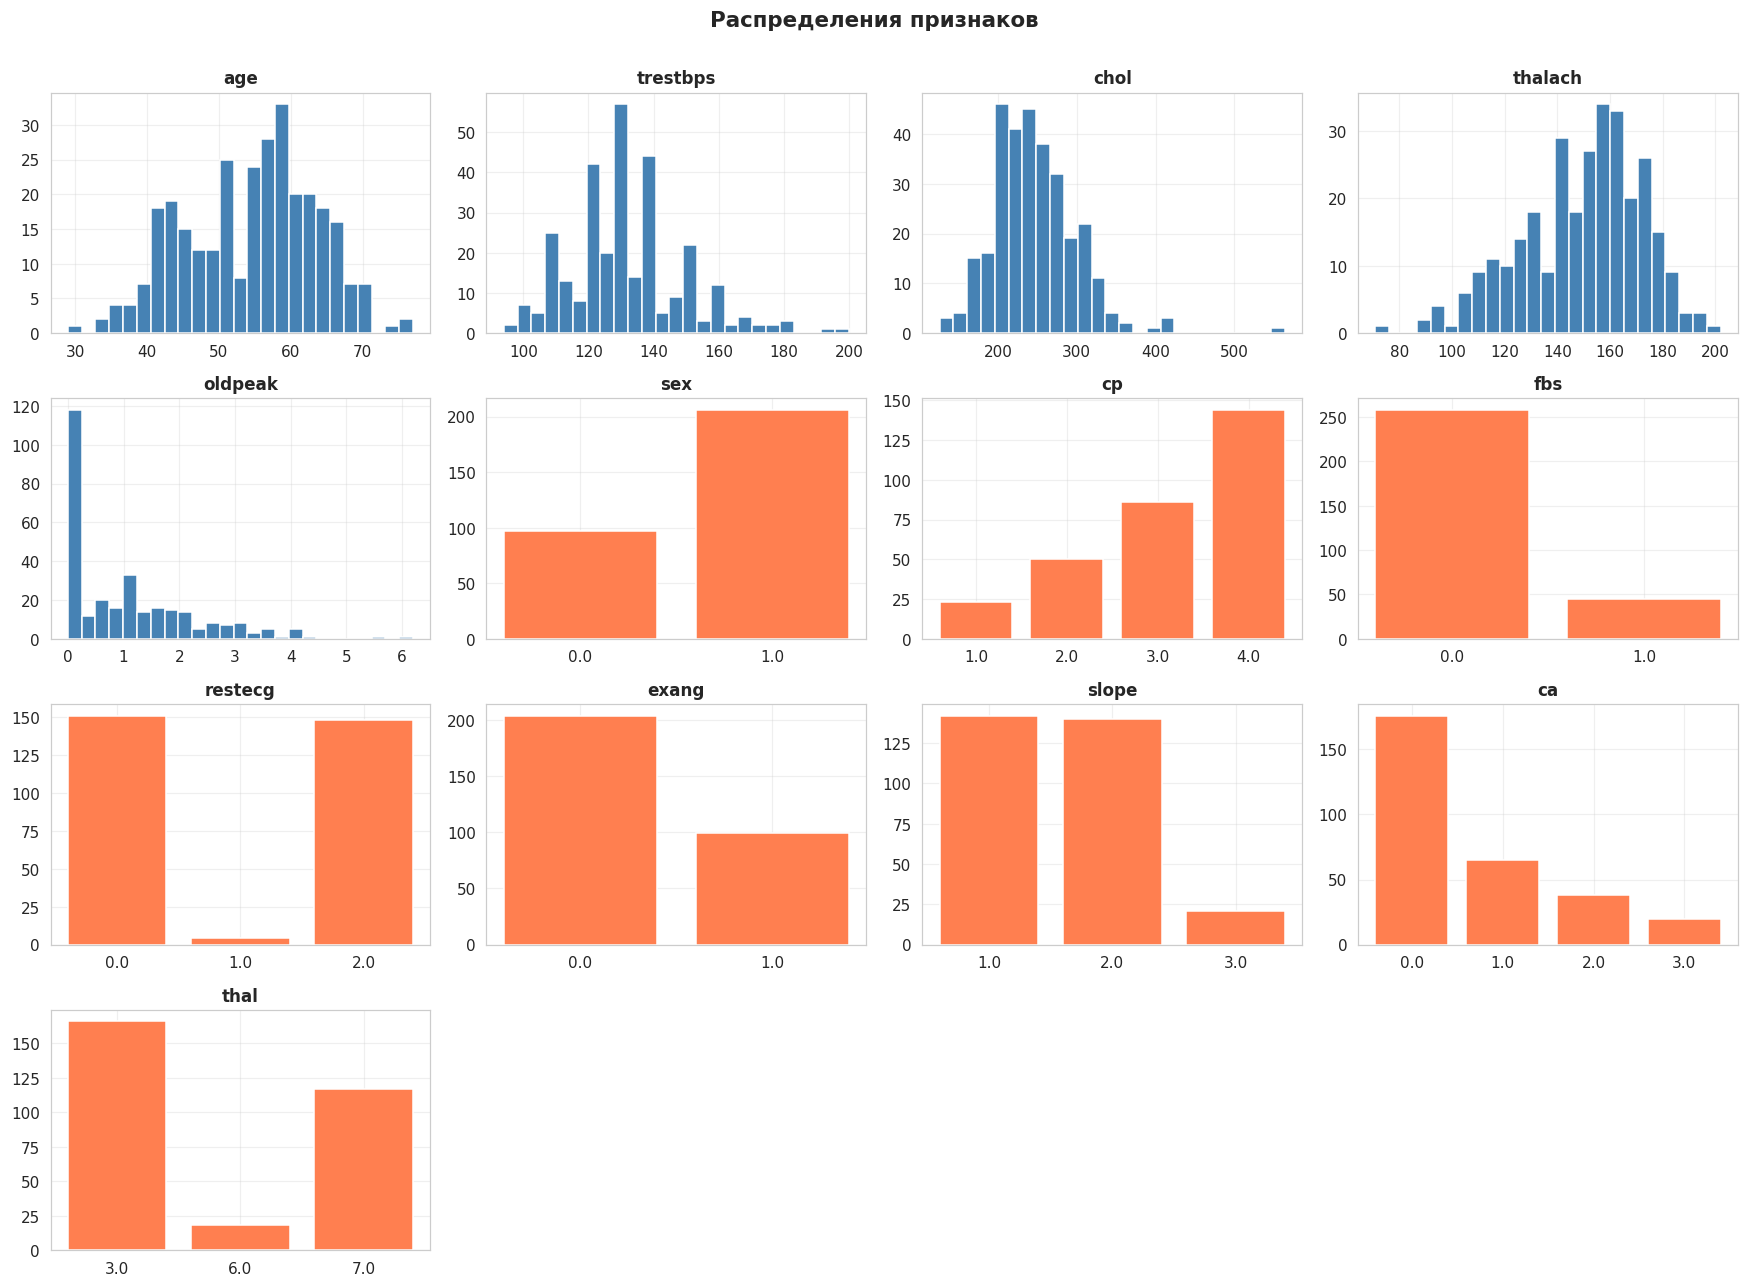

In [8]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

all_feats = numeric_cols + categorical_cols
n_cols = 4
n_rows = int(np.ceil(len(all_feats) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.9))
axes = axes.flatten()

for i, col in enumerate(all_feats):
    if col in numeric_cols:
        axes[i].hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white')
    else:
        vals = df[col].dropna().value_counts().sort_index()
        axes[i].bar(vals.index.astype(str), vals.values, color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')

for j in range(len(all_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения признаков', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

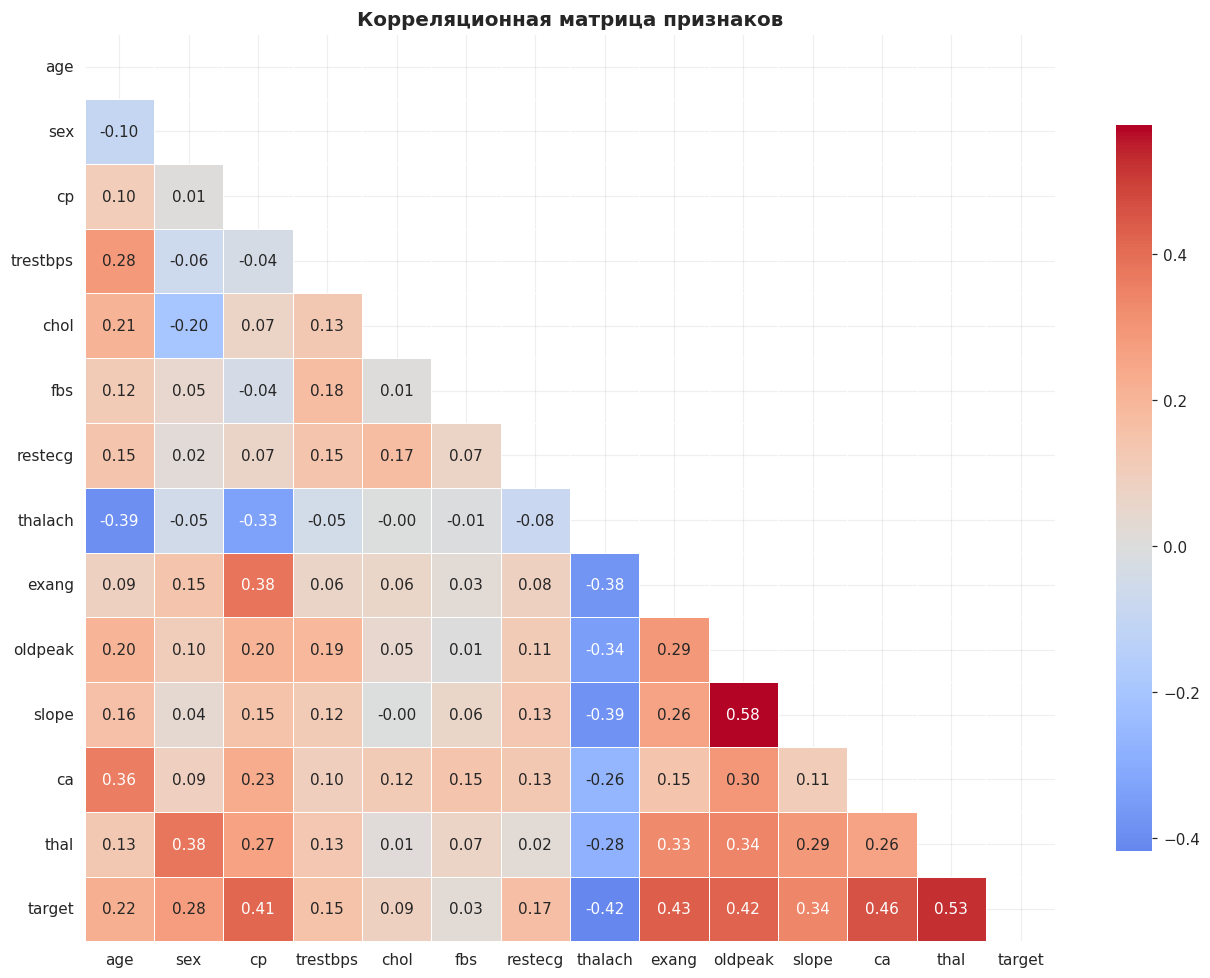

Корреляция признаков с целевой переменной (по убыванию |r|):
thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025


In [9]:
# Корреляционная матрица (маска верхнего треугольника — как на семинаре 1)
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица признаков', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Корреляция признаков с целевой переменной (по убыванию |r|):')
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print(target_corr.round(3).to_string())

**Что видно на корреляционной матрице.**

Сильной мультиколлинеарности между признаками нет: максимальные попарные
корреляции по модулю — около 0.4 (`slope`–`oldpeak`, `age`–`thalach`).
Это значит, что проблема неустойчивости коэффициентов линейных моделей
(раздутая дисперсия при высоком VIF) здесь не критична, и Ridge-регуляризация
нужна скорее для контроля переобучения на 240 обучающих объектах,
чем для борьбы с коллинеарностью.

Пары `slope`–`oldpeak` и `age`–`thalach` связаны физиологически: депрессия
сегмента ST и его наклон описывают одно и то же явление на ЭКГ,
а максимальная ЧСС естественно снижается с возрастом (правило «220 минус возраст»).
Обе связи мы используем ниже при конструировании признаков.

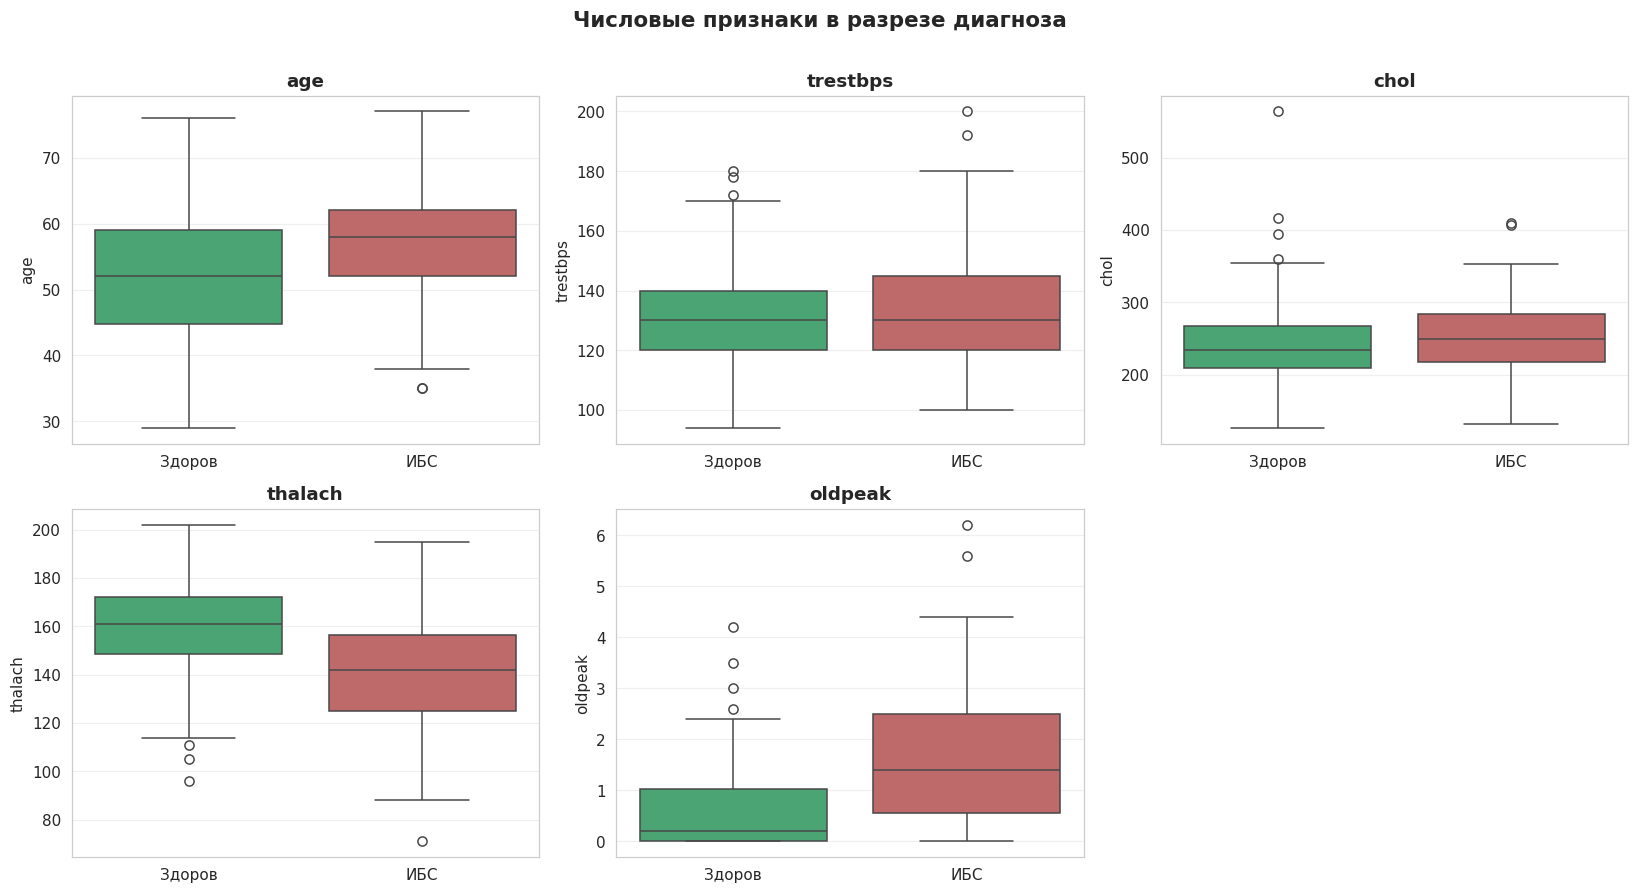

In [10]:
# Числовые признаки в разрезе классов
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i],
                hue='target', palette=['mediumseagreen', 'indianred'], legend=False)
    axes[i].set_xticklabels(['Здоров', 'ИБС'])
    axes[i].set_xlabel('')
    axes[i].set_title(col, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Числовые признаки в разрезе диагноза', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

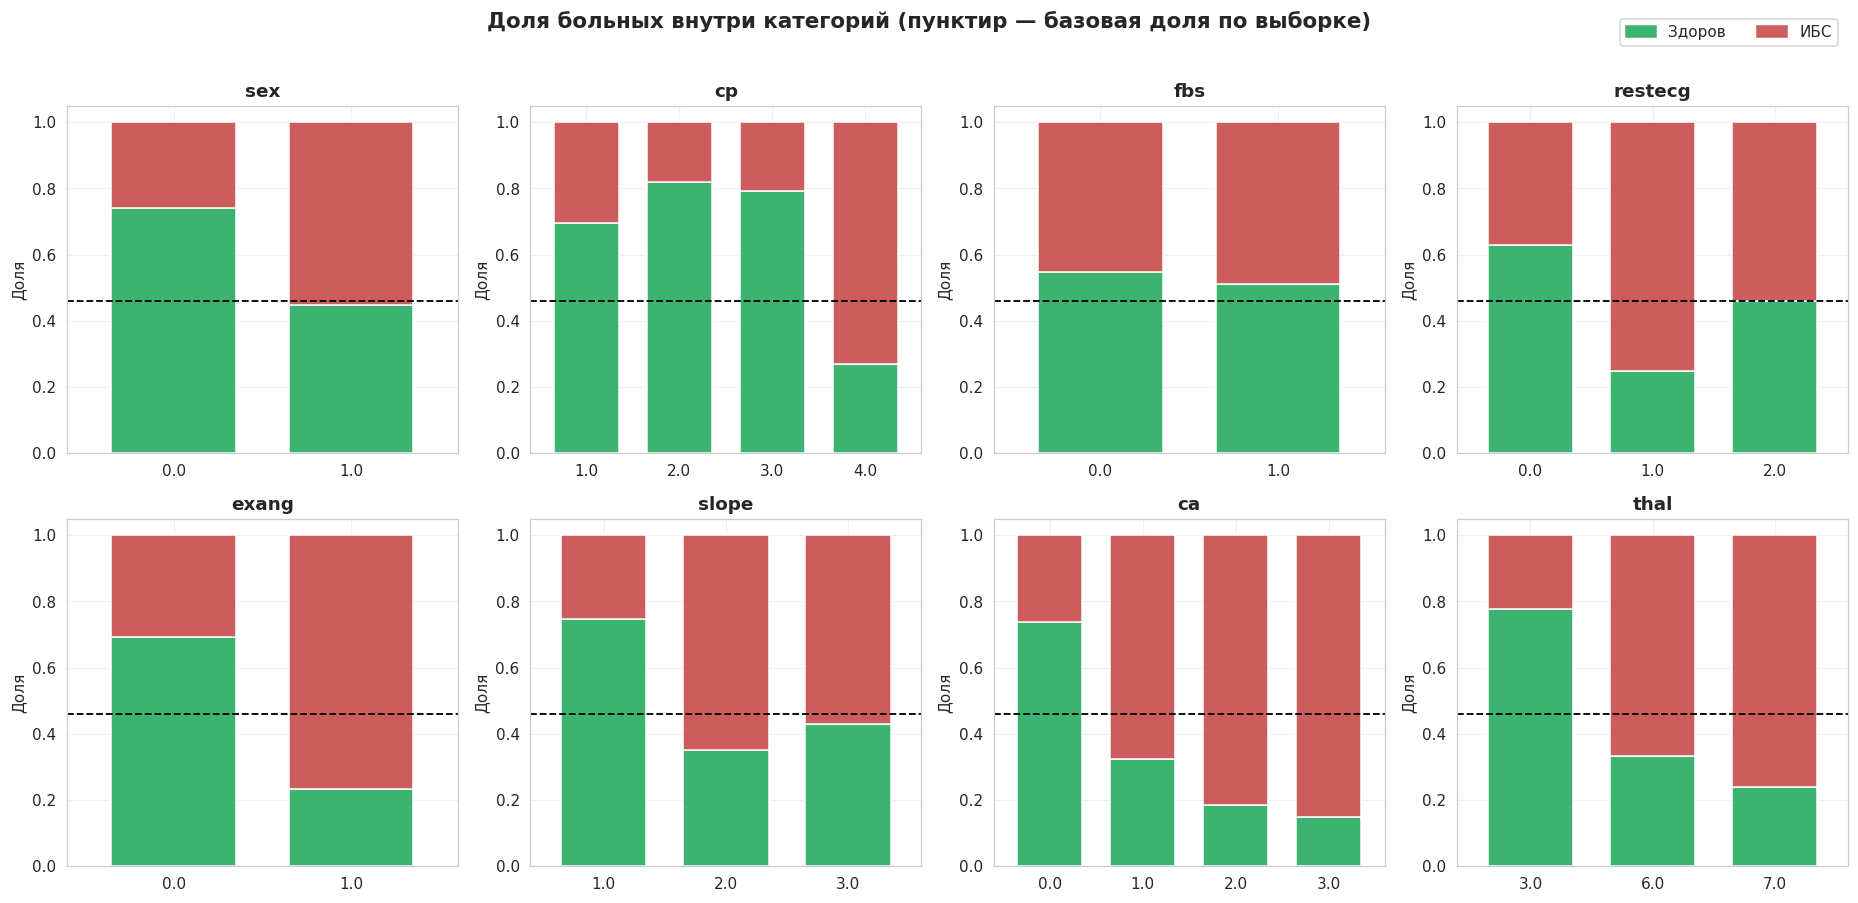

In [11]:
# Категориальные признаки: доля больных внутри каждой категории
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index')
    ct.plot.bar(stacked=True, ax=axes[i],
                color=['mediumseagreen', 'indianred'], legend=False, width=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Доля')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].axhline(df['target'].mean(), color='black', ls='--', lw=1.2)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ['mediumseagreen', 'indianred']]
fig.legend(handles, ['Здоров', 'ИБС'], loc='upper right', ncol=2, bbox_to_anchor=(0.99, 1.02))
plt.suptitle('Доля больных внутри категорий (пунктир — базовая доля по выборке)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Наблюдения из EDA (используем их дальше при конструировании признаков):**

1. **`thalach` (макс. ЧСС) — сильнейший числовой предиктор**, но в обратную сторону:
   у больных ИБС максимальная достижимая ЧСС **ниже**. Это не парадокс, а суть
   нагрузочного теста: ишемия ограничивает способность миокарда наращивать частоту.
   Проблема в том, что абсолютное значение `thalach` несравнимо между
   30-летним и 70-летним пациентом — нормальный максимум сам падает с возрастом.
   → Отсюда первый сконструированный признак.

2. **`oldpeak` и `slope` описывают одно явление** — поведение сегмента ST при нагрузке.
   Клинически опасна не любая депрессия ST, а глубокая депрессия
   в сочетании с плоским или нисходящим наклоном. Признаки по отдельности
   эту комбинацию не выражают. → Второй признак.

3. **`cp = 4` (бессимптомное течение) — самая «больная» категория.** Контринтуитивно,
   но объяснимо: пациентов без типичной стенокардии направляют на ангиографию
   по совокупности других факторов, то есть это отобранная группа высокого риска.

4. **`ca` монотонно связан с диагнозом** — чем больше поражённых сосудов
   видно при флюороскопии, тем выше вероятность подтверждённой ИБС.
   Это, по сути, частично прямое наблюдение целевой переменной.

5. **`chol` разделяет классы слабо** — боксплоты почти совпадают. Как и `thalach`,
   холестерин сильно зависит от возраста, и «высокий для молодого» ≠ «высокий для
   пожилого». → Третий признак.

### 2.3 Пропуски и выбросы

In [12]:
print('Строки с пропусками:')
display(df[df.isnull().any(axis=1)])

print(f'\nВсего строк с пропусками: {df.isnull().any(axis=1).sum()} из {len(df)} '
      f'({df.isnull().any(axis=1).mean():.1%})')
print('\nРешение: НЕ удаляем строки (выборка мала — 303 объекта, каждый ценен).')
print('Импутация медианой/модой будет выполнена ВНУТРИ Pipeline,')
print('чтобы статистики считались только по обучающей части каждого фолда.')
print('Заполнение медианой по всему датасету до разбиения — это утечка данных.')

Строки с пропусками:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0



Всего строк с пропусками: 6 из 303 (2.0%)

Решение: НЕ удаляем строки (выборка мала — 303 объекта, каждый ценен).
Импутация медианой/модой будет выполнена ВНУТРИ Pipeline,
чтобы статистики считались только по обучающей части каждого фолда.
Заполнение медианой по всему датасету до разбиения — это утечка данных.


In [13]:
# Анализ выбросов по правилу 1.5*IQR
outlier_report = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask_out = (df[col] < lo) | (df[col] > hi)
    outlier_report.append({
        'признак': col,
        'границы': f'[{lo:.1f}, {hi:.1f}]',
        'выбросов': mask_out.sum(),
        'доля': f'{mask_out.mean():.1%}',
        'min': df[col].min(),
        'max': df[col].max(),
        'доля ИБС среди выбросов': f'{df.loc[mask_out, "target"].mean():.2f}' if mask_out.sum() else '—'
    })

pd.DataFrame(outlier_report)

,признак,границы,выбросов,доля,min,max,доля ИБС среди выбросов
0,age,"[28.5, 80.5]",0,0.0%,29.0,77.0,—
1,trestbps,"[90.0, 170.0]",9,3.0%,94.0,200.0,0.67
2,chol,"[115.0, 371.0]",5,1.7%,126.0,564.0,0.40
3,thalach,"[84.8, 214.8]",1,0.3%,71.0,202.0,1.00
4,oldpeak,"[-2.4, 4.0]",5,1.7%,0.0,6.2,0.80


**Решение по выбросам: не удаляем и не обрезаем.**

Все значения лежат в физиологически возможных диапазонах: холестерин до 564 мг/дл —
это тяжёлая, но реальная гиперхолестеринемия; давление 200 мм рт. ст. — гипертонический
криз, а не ошибка ввода. Нулевых или отрицательных значений там, где их быть не может
(холестерин, давление), нет — то есть технического мусора в данных нет.

Более того, среди «выбросов» доля больных заметно отличается от базовой — это
не шум, а сигнал: экстремальные показатели и есть маркеры риска. Удаление таких
пациентов выбросило бы самые информативные наблюдения из и без того маленькой выборки.

Что мы делаем вместо удаления:
* для линейных моделей и MLP — `StandardScaler` (снижает влияние масштаба);
* деревья и ансамбли к монотонным выбросам нечувствительны по построению;
* в разделе с error analysis отдельно проверим, не концентрируются ли ошибки модели
  именно на этих объектах.

## 3. Feature Engineering

Конструируем 5 новых признаков. Каждый — с клиническим обоснованием,
а не «перемножим всё со всем»: на 303 объектах любой лишний шумовой признак
напрямую увеличивает разброс оценок коэффициентов и риск переобучения.

| Новый признак | Формула | Обоснование |
|---|---|---|
| `hr_reserve` | `thalach / (220 - age)` | Доля от возрастного максимума ЧСС. Абсолютный `thalach` несравним между возрастами: 150 уд/мин — это норма для 70-летнего и признак ограничения для 30-летнего. Нормировка делает признак сопоставимым между пациентами. |
| `st_burden` | `oldpeak * slope` | Взаимодействие глубины депрессии ST и её наклона. Клинически опасна именно глубокая депрессия при плоском/нисходящем наклоне (`slope` 2–3); тот же `oldpeak` при восходящем наклоне (`slope`=1) гораздо менее специфичен. Мультипликативное взаимодействие линейная модель сама выразить не может. |
| `chol_age_ratio` | `chol / age` | Холестерин закономерно растёт с возрастом, поэтому абсолютное значение плохо разделяет классы (видно на боксплотах). Отношение отвечает на вопрос «высокий ли холестерин *для своего возраста*». |
| `bp_age_ratio` | `trestbps / age` | Та же логика для артериального давления. |
| `n_risk_factors` | сумма 4 бинарных флагов | Аддитивная сводка классических факторов риска: стенокардия при нагрузке, гипергликемия натощак, гипертония (>140), гиперхолестеринемия (>240). Медицинские шкалы риска (Framingham, SCORE) устроены именно так — суммой факторов, а не их сложной комбинацией. |

**Важно:** все формулы детерминированные и считаются построчно — они не используют
статистик по выборке (среднее, медиану, квантили). Поэтому их можно применить
до разбиения на train/test без риска утечки. Если бы признак опирался на
агрегаты по датасету (например, `chol / chol.mean()` или target encoding),
его пришлось бы считать внутри Pipeline на каждом фолде отдельно.

In [14]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    """Построчные детерминированные преобразования — утечки не создают."""
    d = data.copy()

    # 1. Хронотропный резерв: доля от возрастного максимума ЧСС
    d['hr_reserve'] = d['thalach'] / (220 - d['age'])

    # 2. Ишемическая нагрузка на ЭКГ: глубина депрессии ST x наклон сегмента
    d['st_burden'] = d['oldpeak'] * d['slope']

    # 3-4. Показатели, нормированные на возраст
    d['chol_age_ratio'] = d['chol'] / d['age']
    d['bp_age_ratio'] = d['trestbps'] / d['age']

    # 5. Аддитивная шкала классических факторов риска
    d['n_risk_factors'] = (
        (d['exang'] == 1).astype(int) +          # стенокардия при нагрузке
        (d['fbs'] == 1).astype(int) +            # глюкоза натощак > 120
        (d['trestbps'] > 140).astype(int) +      # артериальная гипертензия
        (d['chol'] > 240).astype(int)            # гиперхолестеринемия
    )
    return d


df_fe = add_features(df)
new_features = ['hr_reserve', 'st_burden', 'chol_age_ratio', 'bp_age_ratio', 'n_risk_factors']

print(f'Признаков было: {df.shape[1] - 1}, стало: {df_fe.shape[1] - 1}')
df_fe[new_features + ['target']].describe().T.round(3)

Признаков было: 13, стало: 18


,count,mean,std,min,25%,50%,75%,max
hr_reserve,303.0,0.903,0.128,0.464,0.833,0.929,1.000,1.175
st_burden,303.0,2.076,2.823,0.000,0.000,1.000,3.200,18.600
chol_age_ratio,303.0,4.632,1.105,2.099,3.836,4.477,5.306,8.418
bp_age_ratio,303.0,2.476,0.471,1.493,2.171,2.414,2.727,4.483
n_risk_factors,303.0,1.195,0.955,0.000,0.000,1.000,2.000,4.000
target,303.0,0.459,0.499,0.000,0.000,0.000,1.000,1.000


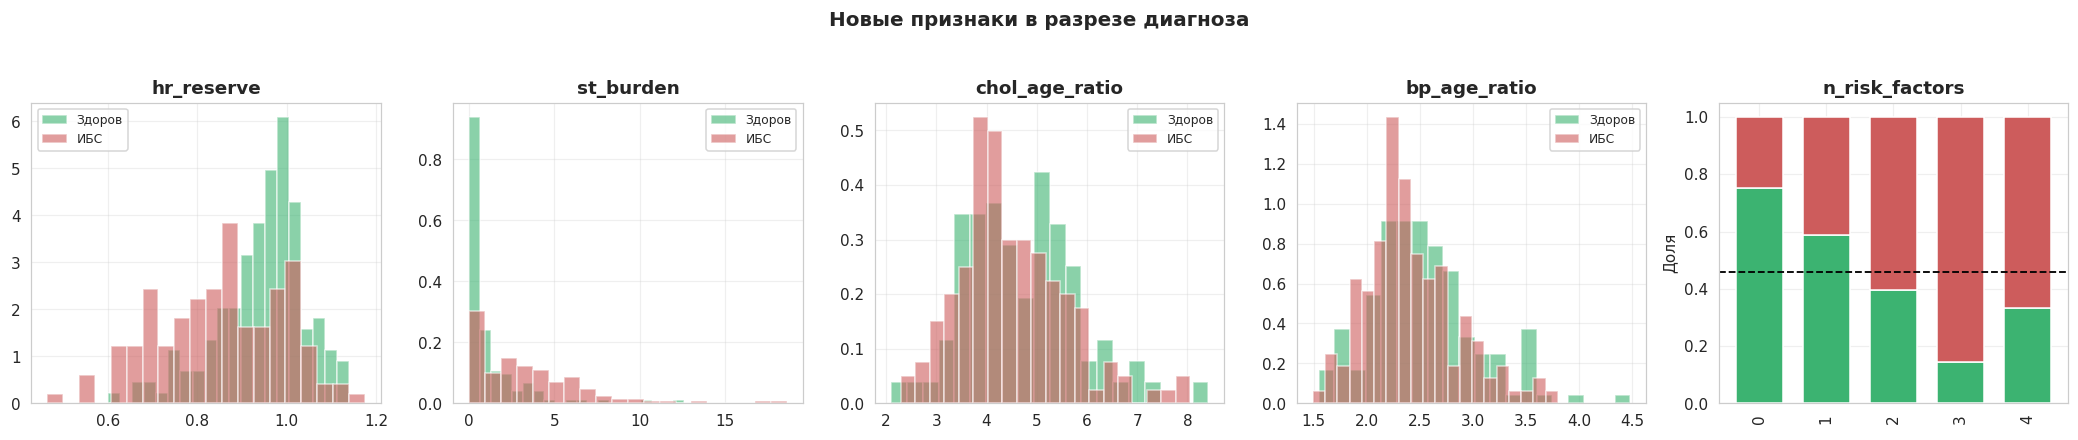

In [15]:
# Проверяем, что новые признаки действительно разделяют классы
fig, axes = plt.subplots(1, 5, figsize=(19, 3.8))

for i, col in enumerate(new_features):
    if col == 'n_risk_factors':
        ct = pd.crosstab(df_fe[col], df_fe['target'], normalize='index')
        ct.plot.bar(stacked=True, ax=axes[i], color=['mediumseagreen', 'indianred'],
                    legend=False, width=0.7)
        axes[i].axhline(df_fe['target'].mean(), color='black', ls='--', lw=1.2)
        axes[i].set_ylabel('Доля')
    else:
        for cls, color, lbl in [(0, 'mediumseagreen', 'Здоров'), (1, 'indianred', 'ИБС')]:
            axes[i].hist(df_fe.loc[df_fe['target'] == cls, col], bins=20, alpha=0.6,
                         color=color, label=lbl, density=True)
        axes[i].legend(fontsize=8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Новые признаки в разрезе диагноза', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

In [16]:
# Сравниваем силу связи новых признаков с целевой переменной против их "родителей"
pairs = [
    ('thalach', 'hr_reserve'),
    ('oldpeak', 'st_burden'),
    ('chol', 'chol_age_ratio'),
    ('trestbps', 'bp_age_ratio'),
]

rows = []
corr_fe = df_fe.corr(numeric_only=True)['target']
for base, new in pairs:
    rows.append({
        'исходный': base,
        '|corr| исходного': abs(corr_fe[base]),
        'новый': new,
        '|corr| нового': abs(corr_fe[new]),
        'прирост': abs(corr_fe[new]) - abs(corr_fe[base]),
    })
rows.append({'исходный': '—', '|corr| исходного': np.nan, 'новый': 'n_risk_factors',
             '|corr| нового': abs(corr_fe['n_risk_factors']), 'прирост': np.nan})

comp = pd.DataFrame(rows).round(3)
display(comp)

print('\nЗамечание: корреляция — линейная одномерная мера, и она не обязана вырасти')
print('у полезного признака. st_burden выражает ВЗАИМОДЕЙСТВИЕ, ценность которого')
print('видна только в контексте модели. Реальную проверку полезности мы проведём')
print('в разделе с permutation importance и ablation study (модель с FE vs без FE).')

,исходный,|corr| исходного,новый,|corr| нового,прирост
0,thalach,0.417,hr_reserve,0.359,-0.058
1,oldpeak,0.425,st_burden,0.397,-0.027
2,chol,0.085,chol_age_ratio,0.090,0.005
3,trestbps,0.151,bp_age_ratio,0.118,-0.033
4,—,NaN,n_risk_factors,0.354,NaN



Замечание: корреляция — линейная одномерная мера, и она не обязана вырасти
у полезного признака. st_burden выражает ВЗАИМОДЕЙСТВИЕ, ценность которого
видна только в контексте модели. Реальную проверку полезности мы проведём
в разделе с permutation importance и ablation study (модель с FE vs без FE).


## 4. Разбиение данных и препроцессинг

Ключевой принцип (и первая из «частых ошибок» в задании):

> Любое решение, принятое на основании данных, — часть процедуры обучения
> и должно приниматься только по обучающей части.

Под это правило попадают импутация пропусков, параметры масштабирования и
категории для one-hot кодирования. Поэтому:

* **сначала** разбиваем данные (`train_test_split` со `stratify`),
* **затем** всю предобработку кладём в `ColumnTransformer` внутри `Pipeline`,
  и она заново обучается на train-части каждого CV-фолда.

Отложенная тестовая выборка (20%, 61 пациент) не участвует ни в подборе
гиперпараметров, ни в отборе признаков — она трогается **один раз**, в самом конце.

Разбиение признаков на группы для препроцессинга:
* **числовые** → импутация медианой + `StandardScaler` (критично для LogReg, SVM, KNN и MLP);
* **категориальные номинальные** (`cp`, `restecg`, `slope`, `thal`) → импутация модой + One-Hot.
  Числовые коды 1/2/3/4 не несут порядка: тип боли в груди «4» не больше типа «1»,
  и без one-hot линейная модель припишет им ложную монотонность;
* **бинарные и порядковые** (`sex`, `fbs`, `exang`, `ca`, `n_risk_factors`) → оставляем как есть.
  `ca` — счётчик поражённых сосудов, у него есть естественный порядок 0 < 1 < 2 < 3.

In [17]:
TARGET = 'target'
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]

# 80 / 20, стратифицированно
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} объектов, {X_train.shape[1]} признаков')
print(f'Test:  {X_test.shape[0]} объектов')
print()
print('Доля класса 1 — train: {:.3f}, test: {:.3f} (stratify сохранил пропорции)'.format(
    y_train.mean(), y_test.mean()))

Train: 242 объектов, 18 признаков
Test:  61 объектов

Доля класса 1 — train: 0.459, test: 0.459 (stratify сохранил пропорции)


In [18]:
# Группы признаков для препроцессинга
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak',
                'hr_reserve', 'st_burden', 'chol_age_ratio', 'bp_age_ratio']
cat_features = ['cp', 'restecg', 'slope', 'thal']          # номинальные -> One-Hot
passthrough_features = ['sex', 'fbs', 'exang', 'ca', 'n_risk_factors']  # бинарные/порядковые

assert set(num_features + cat_features + passthrough_features) == set(X.columns), \
    'Признаки распределены по группам не полностью!'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
        ]), cat_features),

        ('pass', SimpleImputer(strategy='most_frequent'), passthrough_features),
    ],
    remainder='drop'
)

# Проверяем итоговую размерность (обучаем ТОЛЬКО на train)
_check = preprocessor.fit_transform(X_train)
feature_names_out = preprocessor.get_feature_names_out()

print(f'После препроцессинга: {_check.shape[1]} признаков (было {X_train.shape[1]})')
print(f'Пропусков после импутации: {np.isnan(_check).sum()}')
print()
print('Итоговые признаки:')
print(list(feature_names_out))

После препроцессинга: 23 признаков (было 18)
Пропусков после импутации: 0

Итоговые признаки:
['num__age', 'num__trestbps', 'num__chol', 'num__thalach', 'num__oldpeak', 'num__hr_reserve', 'num__st_burden', 'num__chol_age_ratio', 'num__bp_age_ratio', 'cat__cp_2.0', 'cat__cp_3.0', 'cat__cp_4.0', 'cat__restecg_1.0', 'cat__restecg_2.0', 'cat__slope_2.0', 'cat__slope_3.0', 'cat__thal_6.0', 'cat__thal_7.0', 'pass__sex', 'pass__fbs', 'pass__exang', 'pass__ca', 'pass__n_risk_factors']


In [19]:
# Единая схема кросс-валидации для ВСЕХ моделей проекта.
# Одна и та же схема + одна и та же метрика = сравнения корректны
# (последняя из "частых ошибок" в задании — сравнение моделей на разных метриках).

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = 'roc_auc'

print(f'CV: StratifiedKFold(n_splits=5, shuffle=True, random_state={SEED})')
print(f'Основная метрика: {SCORING}')
print()
print('Baseline для ориентира:')
print(f'  случайная модель        ROC-AUC = 0.500')
print(f'  константа "все больны"  Accuracy = {y_test.mean():.3f}')

CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Основная метрика: roc_auc

Baseline для ориентира:
  случайная модель        ROC-AUC = 0.500
  константа "все больны"  Accuracy = 0.459


### Итоги части 1

* Загружен датасет Cleveland: **303 пациента, 13 исходных признаков**, целевая
  переменная бинаризована (54% здоровых / 46% с ИБС — дисбаланс незначительный).
* Пропуски (6 строк, 2%) не удалены, а импутируются **внутри Pipeline** —
  без утечки статистик из валидационных фолдов.
* Выбросы сохранены: все значения физиологически правдоподобны и несут сигнал.
* Сконструировано **5 новых признаков** с клиническим обоснованием;
  их реальная полезность будет проверена ablation-исследованием, а не только корреляцией.
* Данные разбиты 80/20 со стратификацией, тестовая выборка отложена до финала.
* Зафиксированы единая схема CV (`StratifiedKFold(5)`) и единая метрика (`ROC-AUC`)
  для всех моделей проекта.

# Часть 2. Классические ML-модели

План раздела:

1. **Зоопарк базовых моделей** — 11 алгоритмов из 5 разных семейств,
   все обёрнуты в единый `Pipeline` с препроцессором из части 1.
   Оценка через 5-fold стратифицированную кросс-валидацию по ROC-AUC.
2. **Подбор гиперпараметров** (`GridSearchCV`) для лучших представителей семейств.
3. **Вложенная кросс-валидация** — честная оценка процедуры подбора,
   без оптимистичного смещения от выбора максимума по сетке.
4. **Ablation study**: помог ли feature engineering из части 1?
5. **Оценка на отложенном тесте** и сохранение предсказаний для стекинга.

Принцип отбора моделей — **разнообразие**, а не количество: линейные,
метрические, вероятностные, деревья, бэггинг и бустинг делают разные
предположения о данных. Это важно и само по себе, и для ансамблирования
в части 4: коррелированные модели ансамбль не улучшают.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier)

# Опциональные бустинги — подключаем, если установлены
HAS_XGB = HAS_LGB = HAS_CAT = False
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    print('XGBoost не установлен: pip install xgboost')
try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    print('LightGBM не установлен: pip install lightgbm')
try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    print('CatBoost не установлен: pip install catboost')

print(f'\nДоступны бустинги — XGBoost: {HAS_XGB}, LightGBM: {HAS_LGB}, CatBoost: {HAS_CAT}')


Доступны бустинги — XGBoost: True, LightGBM: True, CatBoost: True


In [21]:
from sklearn.base import clone

def make_pipe(model):
    """Оборачивает любую модель в Pipeline с общим препроцессором.

    Критично: preprocessor клонируется, поэтому импутация, масштабирование
    и one-hot обучаются заново на train-части КАЖДОГО фолда CV.
    Это то самое отсутствие утечки, о котором предупреждает задание.
    """
    return Pipeline([
        ('prep', clone(preprocessor)),
        ('clf', model)
    ])


# Единый реестр результатов всего проекта
results = {}          # имя -> метрики
oof_preds = {}         # имя -> out-of-fold вероятности на train (для стекинга)
test_preds = {}        # имя -> вероятности на test
fitted_models = {}     # имя -> обученный на всём train Pipeline


def evaluate(name, model, family, verbose=True):
    """Полная оценка модели: CV на train + метрики на отложенном тесте.

    Возвращает обученный pipeline. Все результаты складываются в глобальные реестры.
    """
    pipe = make_pipe(model)

    # 1. Кросс-валидация на train (единая схема CV для всех моделей)
    cv_res = cross_validate(pipe, X_train, y_train, cv=CV,
                            scoring=['roc_auc', 'accuracy', 'f1'],
                            n_jobs=-1, return_train_score=True)

    # 2. Out-of-fold предсказания — понадобятся для стекинга и анализа разнообразия
    from sklearn.model_selection import cross_val_predict
    oof = cross_val_predict(pipe, X_train, y_train, cv=CV,
                            method='predict_proba', n_jobs=-1)[:, 1]

    # 3. Обучение на всём train и оценка на отложенном тесте
    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    results[name] = {
        'family': family,
        'cv_auc': cv_res['test_roc_auc'].mean(),
        'cv_auc_std': cv_res['test_roc_auc'].std(),
        'cv_acc': cv_res['test_accuracy'].mean(),
        'cv_f1': cv_res['test_f1'].mean(),
        'train_auc': cv_res['train_roc_auc'].mean(),
        'test_auc': roc_auc_score(y_test, proba),
        'test_acc': accuracy_score(y_test, pred),
        'test_f1': f1_score(y_test, pred),
        'test_recall': recall_score(y_test, pred),
        'test_precision': precision_score(y_test, pred),
        'log_loss': log_loss(y_test, proba),
        'fit_time': fit_time,
        'cv_folds': cv_res['test_roc_auc'],
    }
    oof_preds[name] = oof
    test_preds[name] = proba
    fitted_models[name] = pipe

    if verbose:
        r = results[name]
        print(f'{name:<22} CV AUC = {r["cv_auc"]:.4f} ± {r["cv_auc_std"]:.4f} | '
              f'Test AUC = {r["test_auc"]:.4f} | overfit gap = {r["train_auc"] - r["cv_auc"]:+.3f} | '
              f'{fit_time:.2f} c')
    return pipe


print('Функции оценки готовы.')

Функции оценки готовы.


## 5. Зоопарк базовых моделей

Собираем 11 алгоритмов из пяти семейств. Гиперпараметры пока — разумные значения
по умолчанию; это baseline, точка отсчёта для последующего тюнинга.

| Семейство | Модели | Ключевое предположение |
|---|---|---|
| Линейные | LogisticRegression (L2, L1) | Логит целевой переменной линеен по признакам |
| Метрические | KNN, SVM (RBF) | Похожие пациенты имеют похожий диагноз; важна метрика в признаковом пространстве |
| Вероятностные | GaussianNB | Признаки условно независимы при данном классе |
| Деревья | DecisionTree | Целевая переменная описывается осепараллельными разбиениями |
| Ансамбли | RandomForest, ExtraTrees, AdaBoost | Усреднение декоррелированных деревьев снижает variance |
| Бустинг | GradientBoosting, XGBoost, LightGBM, CatBoost | Последовательное исправление ошибок снижает bias |

Обратите внимание на колонку **overfit gap** = (AUC на train внутри CV) − (AUC на валидации).
На 242 обучающих объектах глубокие деревья и бустинги упрутся в потолок train-качества,
и разрыв покажет это раньше, чем итоговые метрики.

In [22]:
base_models = {
    'LogReg (L2)':      (LogisticRegression(max_iter=2000, random_state=SEED), 'Линейные'),
    'LogReg (L1)':      (LogisticRegression(penalty='l1', solver='liblinear',
                                            max_iter=2000, random_state=SEED), 'Линейные'),
    'KNN (k=15)':       (KNeighborsClassifier(n_neighbors=15), 'Метрические'),
    'SVM (RBF)':        (SVC(kernel='rbf', probability=True, random_state=SEED), 'Метрические'),
    'NaiveBayes':       (GaussianNB(), 'Вероятностные'),
    'DecisionTree':     (DecisionTreeClassifier(max_depth=4, random_state=SEED), 'Деревья'),
    'RandomForest':     (RandomForestClassifier(n_estimators=300, max_depth=6,
                                                min_samples_leaf=2, random_state=SEED,
                                                n_jobs=-1), 'Ансамбли'),
    'ExtraTrees':       (ExtraTreesClassifier(n_estimators=300, max_depth=6,
                                              min_samples_leaf=2, random_state=SEED,
                                              n_jobs=-1), 'Ансамбли'),
    'AdaBoost':         (AdaBoostClassifier(n_estimators=200, learning_rate=0.5,
                                            random_state=SEED), 'Ансамбли'),
    'GradientBoosting': (GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                                    learning_rate=0.05, subsample=0.8,
                                                    random_state=SEED), 'Бустинг'),
}

if HAS_XGB:
    base_models['XGBoost'] = (XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                            subsample=0.8, colsample_bytree=0.8,
                                            eval_metric='logloss', verbosity=0,
                                            random_state=SEED, n_jobs=-1), 'Бустинг')
if HAS_LGB:
    base_models['LightGBM'] = (LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                              subsample=0.8, colsample_bytree=0.8, verbose=-1,
                                              random_state=SEED, n_jobs=-1), 'Бустинг')
if HAS_CAT:
    base_models['CatBoost'] = (CatBoostClassifier(iterations=200, depth=3, learning_rate=0.05,
                                                  verbose=False, random_state=SEED), 'Бустинг')

print(f'Обучение {len(base_models)} базовых моделей (5-fold CV + тест)\n')
print('-' * 105)

t_total = time.time()
for name, (model, family) in base_models.items():
    evaluate(name, model, family)
print('-' * 105)
print(f'Всего: {time.time() - t_total:.1f} c')

Обучение 13 базовых моделей (5-fold CV + тест)

---------------------------------------------------------------------------------------------------------
LogReg (L2)            CV AUC = 0.9044 ± 0.0241 | Test AUC = 0.9610 | overfit gap = +0.029 | 0.09 c
LogReg (L1)            CV AUC = 0.9059 ± 0.0167 | Test AUC = 0.9567 | overfit gap = +0.024 | 0.07 c
KNN (k=15)             CV AUC = 0.8241 ± 0.0362 | Test AUC = 0.9605 | overfit gap = +0.052 | 0.15 c
SVM (RBF)              CV AUC = 0.8635 ± 0.0123 | Test AUC = 0.9621 | overfit gap = +0.089 | 0.09 c
NaiveBayes             CV AUC = 0.8607 ± 0.0413 | Test AUC = 0.8517 | overfit gap = +0.026 | 0.10 c
DecisionTree           CV AUC = 0.7652 ± 0.0759 | Test AUC = 0.8517 | overfit gap = +0.190 | 0.03 c
RandomForest           CV AUC = 0.8667 ± 0.0307 | Test AUC = 0.9719 | overfit gap = +0.131 | 0.73 c
ExtraTrees             CV AUC = 0.8968 ± 0.0246 | Test AUC = 0.9665 | overfit gap = +0.086 | 0.50 c
AdaBoost               CV AUC = 0.8638 ± 0.013

In [23]:
# Соответствие внутренних ключей реестра и заголовков таблицы
_COL_MAP = {
    'cv_auc': 'CV ROC-AUC',
    'cv_auc_std': 'CV std',
    'test_auc': 'Test ROC-AUC',
    'test_acc': 'Test Acc',
    'test_f1': 'Test F1',
    'fit_time': 'Время, с',
}


def results_table(keys=None, sort_by='cv_auc'):
    """Сводная таблица по реестру результатов.

    sort_by принимает как внутренний ключ ('cv_auc'), так и заголовок ('CV ROC-AUC').
    """
    keys = keys or list(results.keys())
    rows = []
    for k in keys:
        r = results[k]
        rows.append({
            'Модель': k,
            'Семейство': r['family'],
            'CV ROC-AUC': r['cv_auc'],
            'CV std': r['cv_auc_std'],
            'Test ROC-AUC': r['test_auc'],
            'Test Acc': r['test_acc'],
            'Test F1': r['test_f1'],
            'Overfit gap': r['train_auc'] - r['cv_auc'],
            'Время, с': r['fit_time'],
        })
    df_res = pd.DataFrame(rows)
    sort_col = _COL_MAP.get(sort_by, sort_by)
    if sort_col not in df_res.columns:
        raise KeyError(f'Неизвестная колонка для сортировки: {sort_by}. '
                       f'Доступны: {list(df_res.columns)}')
    return (df_res
            .sort_values(sort_col, ascending=False)
            .reset_index(drop=True)
            .round(4))


baseline_df = results_table()
display(baseline_df)

print(f'\nЛучшая по CV: {baseline_df.iloc[0]["Модель"]} '
      f'(CV AUC = {baseline_df.iloc[0]["CV ROC-AUC"]:.4f})')
print(f'Разброс CV AUC по всем моделям: '
      f'{baseline_df["CV ROC-AUC"].min():.4f} .. {baseline_df["CV ROC-AUC"].max():.4f}')
print(f'Медианный std по фолдам: {baseline_df["CV std"].median():.4f}')

,Модель,Семейство,CV ROC-AUC,CV std,Test ROC-AUC,Test Acc,Test F1,Overfit gap,"Время, с"
0,LogReg (L1),Линейные,0.906,0.017,0.957,0.885,0.877,0.024,0.069
1,LogReg (L2),Линейные,0.904,0.024,0.961,0.885,0.877,0.029,0.095
2,ExtraTrees,Ансамбли,0.897,0.025,0.967,0.934,0.931,0.086,0.502
3,LightGBM,Бустинг,0.871,0.014,0.956,0.918,0.915,0.129,0.053
4,RandomForest,Ансамбли,0.867,0.031,0.972,0.918,0.912,0.131,0.733
5,XGBoost,Бустинг,0.866,0.018,0.959,0.902,0.897,0.134,0.130
6,AdaBoost,Ансамбли,0.864,0.013,0.968,0.934,0.931,0.118,0.460
7,SVM (RBF),Метрические,0.864,0.012,0.962,0.918,0.915,0.089,0.093
8,NaiveBayes,Вероятностные,0.861,0.041,0.852,0.639,0.694,0.026,0.104
9,CatBoost,Бустинг,0.861,0.025,0.964,0.934,0.931,0.139,0.327



Лучшая по CV: LogReg (L1) (CV AUC = 0.9059)
Разброс CV AUC по всем моделям: 0.7652 .. 0.9059
Медианный std по фолдам: 0.0241


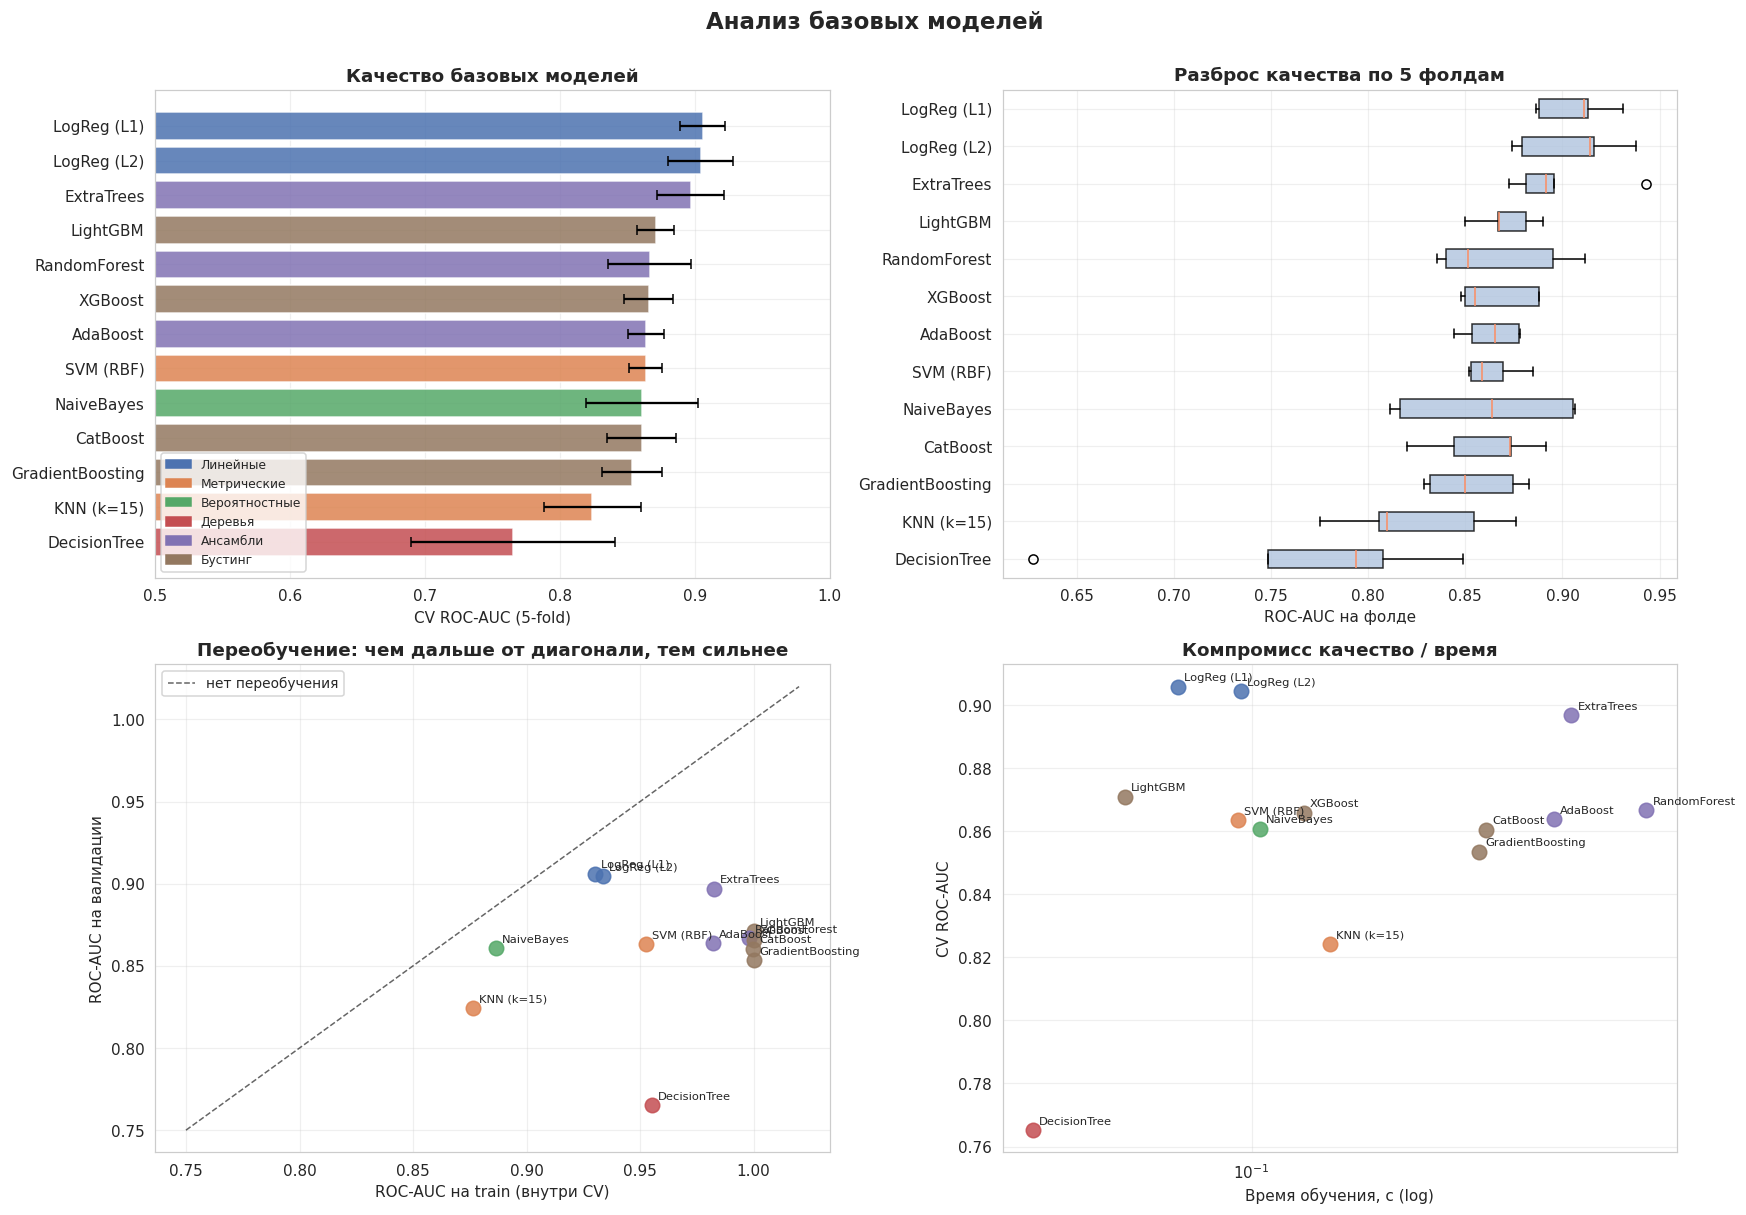

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. CV AUC с усами погрешности
ax = axes[0, 0]
d = baseline_df.sort_values('CV ROC-AUC')
colors_map = {'Линейные': '#4C72B0', 'Метрические': '#DD8452', 'Вероятностные': '#55A868',
              'Деревья': '#C44E52', 'Ансамбли': '#8172B3', 'Бустинг': '#937860'}
cols = [colors_map[f] for f in d['Семейство']]
ax.barh(d['Модель'], d['CV ROC-AUC'], xerr=d['CV std'], color=cols, alpha=0.85, capsize=3)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('CV ROC-AUC (5-fold)')
ax.set_title('Качество базовых моделей', fontweight='bold')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors_map.values()]
ax.legend(handles, colors_map.keys(), fontsize=8, loc='lower left')

# 2. Разброс по фолдам
ax = axes[0, 1]
order = baseline_df.sort_values('CV ROC-AUC')['Модель'].tolist()
ax.boxplot([results[m]['cv_folds'] for m in order], labels=order, vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', alpha=0.8))
ax.set_xlabel('ROC-AUC на фолде')
ax.set_title('Разброс качества по 5 фолдам', fontweight='bold')

# 3. Переобучение: train vs CV
ax = axes[1, 0]
for _, r in baseline_df.iterrows():
    ax.scatter(results[r['Модель']]['train_auc'], r['CV ROC-AUC'],
               s=90, color=colors_map[r['Семейство']], alpha=0.85)
    ax.annotate(r['Модель'], (results[r['Модель']]['train_auc'], r['CV ROC-AUC']),
                fontsize=7.5, xytext=(4, 4), textcoords='offset points')
lims = [0.75, 1.02]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.6, label='нет переобучения')
ax.set_xlabel('ROC-AUC на train (внутри CV)')
ax.set_ylabel('ROC-AUC на валидации')
ax.set_title('Переобучение: чем дальше от диагонали, тем сильнее', fontweight='bold')
ax.legend(fontsize=9)

# 4. Качество vs время
ax = axes[1, 1]
for _, r in baseline_df.iterrows():
    ax.scatter(r['Время, с'], r['CV ROC-AUC'], s=90,
               color=colors_map[r['Семейство']], alpha=0.85)
    ax.annotate(r['Модель'], (r['Время, с'], r['CV ROC-AUC']),
                fontsize=7.5, xytext=(4, 4), textcoords='offset points')
ax.set_xscale('log')
ax.set_xlabel('Время обучения, с (log)')
ax.set_ylabel('CV ROC-AUC')
ax.set_title('Компромисс качество / время', fontweight='bold')

plt.suptitle('Анализ базовых моделей', fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

**Что показывает baseline.**

Разброс качества **по фолдам** сопоставим с разбросом **между моделями** — типичная
картина для выборки в 242 обучающих объекта. Практический вывод: сравнивать модели
по одному замеру бессмысленно, и разницу в третьем знаке после запятой нельзя
интерпретировать как превосходство. Именно поэтому мы всюду смотрим на среднее
**и** на std по фолдам, а не на одно число.

График «train vs валидация» показывает, что бустинги и деревья без ограничений
уходят к AUC ≈ 1.0 на обучении, не выигрывая на валидации — классический
высокий variance при малой выборке. Линейные модели лежат ближе к диагонали:
их ёмкость соответствует объёму данных.

Это уже даёт содержательную гипотезу, которую проверим тюнингом: на 300 объектах
**простые модели с сильной регуляризацией имеют преимущество**, а мощность
градиентного бустинга здесь не окупается.

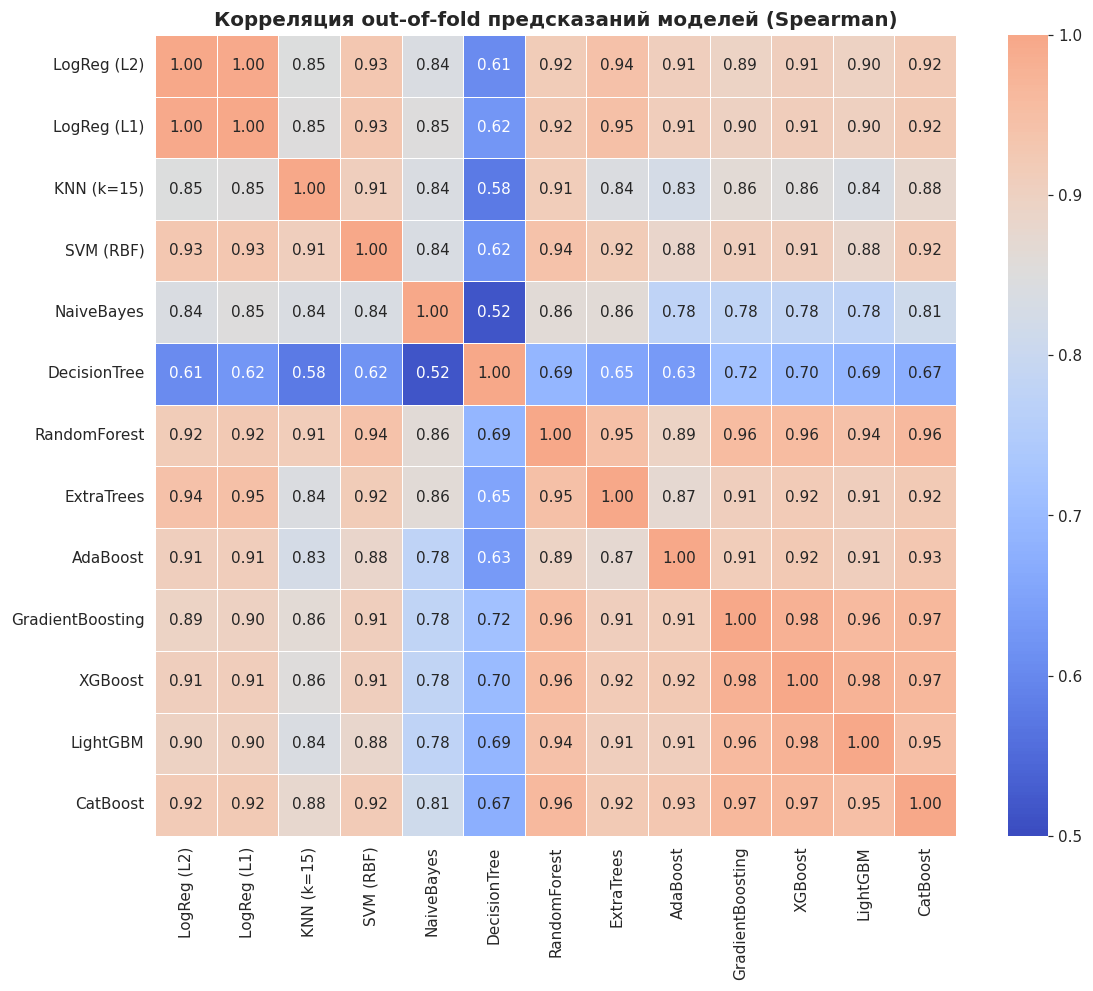

Наименее коррелированные пары (кандидаты в ансамбль):
NaiveBayes    DecisionTree    0.516
KNN (k=15)    DecisionTree    0.577
LogReg (L2)   DecisionTree    0.606
SVM (RBF)     DecisionTree    0.618
LogReg (L1)   DecisionTree    0.625
DecisionTree  AdaBoost        0.631


In [25]:
# Разнообразие моделей: корреляция out-of-fold предсказаний.
# Нужно для части 4 — ансамбль из сильно коррелированных моделей не даёт прироста.
oof_df = pd.DataFrame(oof_preds)
corr_models = oof_df.corr(method='spearman')

plt.figure(figsize=(11, 9))
sns.heatmap(corr_models, annot=True, fmt='.2f', cmap='coolwarm',
            center=0.85, vmin=0.5, vmax=1.0, square=True, linewidths=0.5)
plt.title('Корреляция out-of-fold предсказаний моделей (Spearman)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Наименее коррелированные пары (кандидаты в ансамбль):')
pairs_corr = (corr_models.where(np.triu(np.ones(corr_models.shape), k=1).astype(bool))
              .stack().sort_values())
print(pairs_corr.head(6).round(3).to_string())

## 6. Подбор гиперпараметров

Тюним по одному представителю от каждого семейства — тех, что показали лучший
baseline. Для каждой модели — `GridSearchCV` с той же схемой CV и метрикой ROC-AUC.

Сетки намеренно компактные. Причина не в экономии времени (на 300 объектах перебор
занимает секунды), а в статистике: чем больше конфигураций перебирается на маленькой
выборке, тем сильнее оптимистичное смещение лучшего результата — мы выбираем
конфигурацию, которой **повезло** на конкретном разбиении. Максимум из 200 шумных
величин смещён вверх сильнее, чем максимум из 20. Величину этого смещения
измерим отдельно вложенной кросс-валидацией.

Обратите внимание: сетка задаётся с префиксом `clf__`, потому что модель —
шаг внутри Pipeline. Препроцессор при этом переобучается на каждом фолде каждой
конфигурации, то есть утечки нет и здесь.

In [26]:
search_spaces = {
    'LogReg (tuned)': (
        LogisticRegression(max_iter=5000, random_state=SEED, solver='liblinear'),
        {'clf__C': np.logspace(-3, 2, 12),
         'clf__penalty': ['l1', 'l2'],
         'clf__class_weight': [None, 'balanced']},
        'Линейные'
    ),
    'SVM (tuned)': (
        SVC(probability=True, random_state=SEED),
        {'clf__C': [0.1, 0.5, 1, 3, 10],
         'clf__gamma': ['scale', 0.01, 0.05, 0.1],
         'clf__kernel': ['rbf']},
        'Метрические'
    ),
    'RandomForest (tuned)': (
        RandomForestClassifier(random_state=SEED, n_jobs=-1),
        {'clf__n_estimators': [300],
         'clf__max_depth': [3, 4, 6, None],
         'clf__min_samples_leaf': [1, 3, 5],
         'clf__max_features': ['sqrt', 0.5]},
        'Ансамбли'
    ),
    'GradientBoosting (tuned)': (
        GradientBoostingClassifier(random_state=SEED),
        {'clf__n_estimators': [100, 200],
         'clf__learning_rate': [0.02, 0.05, 0.1],
         'clf__max_depth': [2, 3],
         'clf__subsample': [0.8, 1.0]},
        'Бустинг'
    ),
}

best_params_log = {}
print('Подбор гиперпараметров (GridSearchCV, 5-fold, scoring=roc_auc)\n')

for name, (model, grid, family) in search_spaces.items():
    t0 = time.time()
    gs = GridSearchCV(make_pipe(model), grid, scoring=SCORING, cv=CV, n_jobs=-1)
    gs.fit(X_train, y_train)
    elapsed = time.time() - t0

    n_cfg = len(gs.cv_results_['params'])
    best_params_log[name] = gs.best_params_
    print(f'{name}')
    print(f'   конфигураций: {n_cfg}, время: {elapsed:.1f} c')
    print(f'   лучший CV AUC: {gs.best_score_:.4f}')
    print(f'   параметры: { {k.replace("clf__", ""): v for k, v in gs.best_params_.items()} }')

    # Переоцениваем найденную конфигурацию через общий evaluate(),
    # чтобы метрики считались единообразно со всеми остальными моделями
    evaluate(name, clone(gs.best_estimator_.named_steps['clf']), family)
    print()

Подбор гиперпараметров (GridSearchCV, 5-fold, scoring=roc_auc)

LogReg (tuned)
   конфигураций: 48, время: 7.6 c
   лучший CV AUC: 0.9061
   параметры: {'C': np.float64(1.5199110829529332), 'class_weight': None, 'penalty': 'l1'}
LogReg (tuned)         CV AUC = 0.9061 ± 0.0207 | Test AUC = 0.9567 | overfit gap = +0.026 | 0.02 c

SVM (tuned)
   конфигураций: 20, время: 5.7 c
   лучший CV AUC: 0.8900
   параметры: {'C': 3, 'gamma': 0.01, 'kernel': 'rbf'}
SVM (tuned)            CV AUC = 0.8900 ± 0.0279 | Test AUC = 0.9632 | overfit gap = +0.036 | 0.03 c

RandomForest (tuned)
   конфигураций: 24, время: 79.0 c
   лучший CV AUC: 0.8856
   параметры: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
RandomForest (tuned)   CV AUC = 0.8856 ± 0.0273 | Test AUC = 0.9784 | overfit gap = +0.074 | 0.69 c

GradientBoosting (tuned)
   конфигураций: 24, время: 30.6 c
   лучший CV AUC: 0.8828
   параметры: {'learning_rate': 0.02, 'max_depth': 2, 'n_estimators': 100, 's

In [27]:
tuned_names = list(search_spaces.keys())
base_equiv = {'LogReg (tuned)': 'LogReg (L2)', 'SVM (tuned)': 'SVM (RBF)',
              'RandomForest (tuned)': 'RandomForest', 'GradientBoosting (tuned)': 'GradientBoosting'}

comp_rows = []
for t, b in base_equiv.items():
    comp_rows.append({
        'Модель': b.split(' (')[0],
        'CV AUC (default)': results[b]['cv_auc'],
        'CV AUC (tuned)': results[t]['cv_auc'],
        'Прирост': results[t]['cv_auc'] - results[b]['cv_auc'],
        'std по фолдам': results[t]['cv_auc_std'],
    })
tuning_gain = pd.DataFrame(comp_rows).round(4)
display(tuning_gain)

print('\nВажное наблюдение: прирост от тюнинга у большинства моделей МЕНЬШЕ,')
print('чем стандартное отклонение по фолдам. То есть на этой выборке подбор')
print('гиперпараметров находится в пределах шума измерения — это не повод его')
print('не делать, но повод не переоценивать найденные "оптимальные" значения.')

,Модель,CV AUC (default),CV AUC (tuned),Прирост,std по фолдам
0,LogReg,0.904,0.906,0.002,0.021
1,SVM,0.864,0.890,0.026,0.028
2,RandomForest,0.867,0.886,0.019,0.027
3,GradientBoosting,0.854,0.883,0.029,0.024



Важное наблюдение: прирост от тюнинга у большинства моделей МЕНЬШЕ,
чем стандартное отклонение по фолдам. То есть на этой выборке подбор
гиперпараметров находится в пределах шума измерения — это не повод его
не делать, но повод не переоценивать найденные "оптимальные" значения.


### 6.1 Вложенная кросс-валидация: насколько честна оценка после подбора?

Число `best_score_` из `GridSearchCV` — это **максимум по сетке**, а максимум
нескольких десятков шумных величин смещён вверх относительно их истинных значений.
Если отчитаться этим числом как качеством модели, оценка окажется оптимистичной.

Вложенная схема разделяет две задачи:
* **внутренний цикл** (4 фолда) выбирает гиперпараметры;
* **внешний цикл** (5 фолдов) оценивает качество процедуры целиком, включая внутренний выбор.

Оценка внешнего цикла честная, потому что для каждого внешнего фолда подбор
происходил без него. Разница между `best_score_` и вложенной оценкой — это и есть
величина смещения от подбора.

In [28]:
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

nested_rows = []
for name, (model, grid, family) in search_spaces.items():
    gs = GridSearchCV(make_pipe(model), grid, scoring=SCORING, cv=inner_cv, n_jobs=-1)

    # Неглубокая оценка: лучший результат внутренней CV на всём train
    flat_score = gs.fit(X_train, y_train).best_score_

    # Честная оценка: подбор повторяется внутри каждого внешнего фолда
    nested = cross_val_score(GridSearchCV(make_pipe(model), grid, scoring=SCORING,
                                          cv=inner_cv, n_jobs=-1),
                             X_train, y_train, cv=outer_cv, scoring=SCORING)

    nested_rows.append({
        'Модель': name,
        'Лучший CV (смещённый)': flat_score,
        'Вложенная CV (честная)': nested.mean(),
        'std вложенной': nested.std(),
        'Смещение': flat_score - nested.mean(),
    })

nested_df = pd.DataFrame(nested_rows).round(4)
display(nested_df)

print(f'\nСреднее смещение от подбора по сетке: {nested_df["Смещение"].mean():+.4f}')
print('Это ровно та величина, на которую отчёт "мы получили AUC = X по GridSearch"')
print('переоценивает реальное качество. Финальные выводы делаем по тесту и вложенной CV.')

,Модель,Лучший CV (смещённый),Вложенная CV (честная),std вложенной,Смещение
0,LogReg (tuned),0.895,0.898,0.025,-0.003
1,SVM (tuned),0.893,0.890,0.027,0.004
2,RandomForest (tuned),0.887,0.868,0.032,0.019
3,GradientBoosting (tuned),0.890,0.868,0.027,0.022



Среднее смещение от подбора по сетке: +0.0107
Это ровно та величина, на которую отчёт "мы получили AUC = X по GridSearch"
переоценивает реальное качество. Финальные выводы делаем по тесту и вложенной CV.


## 7. Ablation study: помог ли feature engineering?

В части 1 мы сконструировали 5 признаков с клиническим обоснованием, но
корреляционный анализ не дал однозначного ответа о их полезности — корреляция
одномерна и не видит взаимодействий.

Правильная проверка — прямое сравнение: одна и та же модель, одна и та же схема CV,
единственное отличие — наличие новых признаков. Чтобы вывод не зависел от одной
удачной модели, повторяем для представителей трёх семейств.

Дополнительно проверяем третий вариант — **без `ca` и `thal`**. Эти два признака
получены дорогими процедурами (флюороскопия, сцинтиграфия). Модель без них
отвечает на другой практический вопрос: можно ли отобрать пациентов на дальнейшее
обследование по одним лишь дешёвым показателям?

In [29]:
def build_preprocessor(num_f, cat_f, pass_f):
    return ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), num_f),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first',
                                                   sparse_output=False))]), cat_f),
        ('pass', SimpleImputer(strategy='most_frequent'), pass_f),
    ], remainder='drop')


# Вариант A: только исходные признаки
num_base = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_base = ['cp', 'restecg', 'slope', 'thal']
pass_base = ['sex', 'fbs', 'exang', 'ca']

# Вариант C: без дорогих инвазивных признаков ca и thal
num_noinv = num_features
cat_noinv = ['cp', 'restecg', 'slope']
pass_noinv = ['sex', 'fbs', 'exang', 'n_risk_factors']

variants = {
    'A. Исходные признаки': (build_preprocessor(num_base, cat_base, pass_base),
                             num_base + cat_base + pass_base),
    'B. + Feature Engineering': (build_preprocessor(num_features, cat_features, passthrough_features),
                                 list(X.columns)),
    'C. FE без ca/thal (скрининг)': (build_preprocessor(num_noinv, cat_noinv, pass_noinv),
                                     num_noinv + cat_noinv + pass_noinv),
}

ablation_models = {
    'LogReg': LogisticRegression(C=1.0, max_iter=5000, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=6,
                                           min_samples_leaf=2, random_state=SEED, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                                   learning_rate=0.05, subsample=0.8,
                                                   random_state=SEED),
}

abl_rows = []
for var_name, (prep, cols) in variants.items():
    for mdl_name, mdl in ablation_models.items():
        pipe = Pipeline([('prep', clone(prep)), ('clf', clone(mdl))])
        sc = cross_val_score(pipe, X_train[cols], y_train, cv=CV, scoring=SCORING, n_jobs=-1)
        abl_rows.append({'Вариант': var_name, 'Модель': mdl_name,
                         'CV ROC-AUC': sc.mean(), 'std': sc.std()})

ablation_df = pd.DataFrame(abl_rows)
pivot_abl = ablation_df.pivot(index='Вариант', columns='Модель', values='CV ROC-AUC').round(4)
pivot_std = ablation_df.pivot(index='Вариант', columns='Модель', values='std').round(4)

print('CV ROC-AUC по вариантам набора признаков:')
display(pivot_abl)
print('\nStd по фолдам (для оценки значимости разницы):')
display(pivot_std)

CV ROC-AUC по вариантам набора признаков:


Модель,GradientBoosting,LogReg,RandomForest
Вариант,,,
A. Исходные признаки,0.865,0.909,0.888
B. + Feature Engineering,0.854,0.904,0.867
C. FE без ca/thal (скрининг),0.798,0.848,0.811



Std по фолдам (для оценки значимости разницы):


Модель,GradientBoosting,LogReg,RandomForest
Вариант,,,
A. Исходные признаки,0.022,0.019,0.023
B. + Feature Engineering,0.022,0.024,0.031
C. FE без ca/thal (скрининг),0.048,0.048,0.053


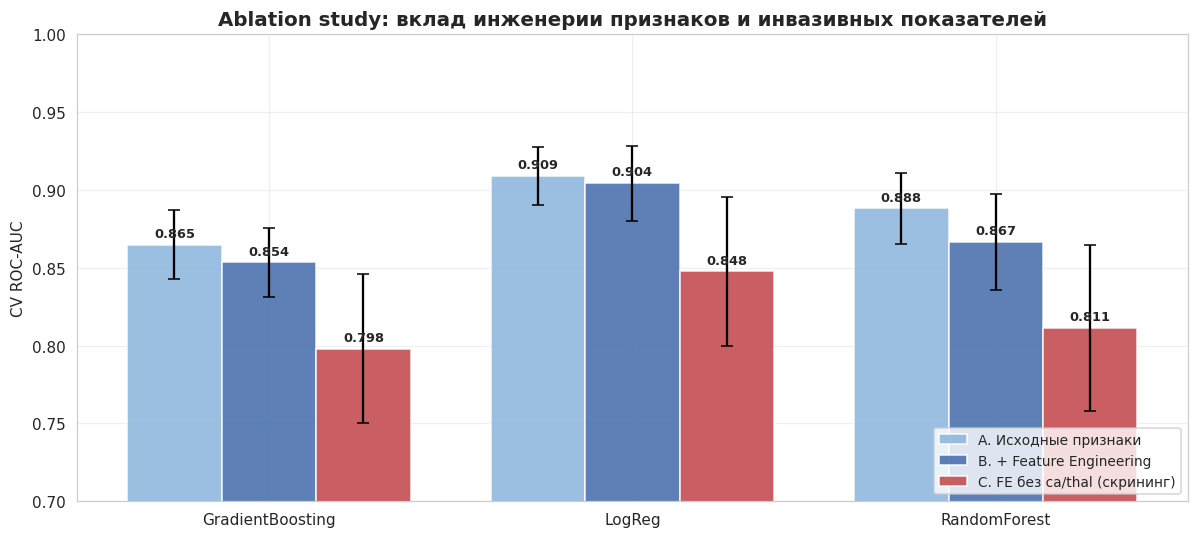

Прирост от feature engineering (B − A):
Модель
GradientBoosting   -0.011
LogReg             -0.004
RandomForest       -0.021

Потеря при отказе от ca/thal (B − C):
Модель
GradientBoosting    0.056
LogReg              0.057
RandomForest        0.055

Медианный std по фолдам: 0.0322


In [30]:
fig, ax = plt.subplots(figsize=(11, 5))

x_pos = np.arange(len(pivot_abl.columns))
width = 0.26
colors_var = ['#8FB8DE', '#4C72B0', '#C44E52']

for i, (var, row) in enumerate(pivot_abl.iterrows()):
    errs = pivot_std.loc[var].values
    bars = ax.bar(x_pos + (i - 1) * width, row.values, width,
                  yerr=errs, capsize=4, label=var, color=colors_var[i], alpha=0.9)
    for b, v in zip(bars, row.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f'{v:.3f}',
                ha='center', fontsize=8.5, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(pivot_abl.columns)
ax.set_ylabel('CV ROC-AUC')
ax.set_ylim(0.7, 1.0)
ax.set_title('Ablation study: вклад инженерии признаков и инвазивных показателей',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

delta_fe = (pivot_abl.loc['B. + Feature Engineering'] - pivot_abl.loc['A. Исходные признаки'])
delta_inv = (pivot_abl.loc['B. + Feature Engineering'] - pivot_abl.loc['C. FE без ca/thal (скрининг)'])

print('Прирост от feature engineering (B − A):')
print(delta_fe.round(4).to_string())
print(f'\nПотеря при отказе от ca/thal (B − C):')
print(delta_inv.round(4).to_string())
print(f'\nМедианный std по фолдам: {pivot_std.values.mean():.4f}')

**Выводы ablation study.**

1. **Feature engineering не улучшил качество, а слегка ухудшил его** — для всех
   трёх семейств моделей: LogReg 0.909 → 0.904, RandomForest 0.888 → 0.867,
   GradientBoosting 0.865 → 0.854. Величина потери (0.005–0.021) сопоставима
   со стандартным отклонением по фолдам (0.019–0.031), то есть формально
   находится в пределах шума, но знак одинаков во всех трёх случаях, и это
   уже не похоже на случайность.

   Объяснение согласуется с общей темой проекта — ограничением служит объём
   выборки. Каждый добавленный признак увеличивает размерность пространства,
   в котором модель ищет решение по 242 объектам, и повышает дисперсию оценок
   коэффициентов. Информации новые признаки почти не добавляют: `hr_reserve`
   является детерминированной функцией `thalach` и `age`, `chol_age_ratio` —
   функцией `chol` и `age`. Модель, у которой уже есть оба аргумента, может
   восстановить их отношение сама, если оно полезно. Дерево строит `st_burden`
   двумя последовательными разбиениями, а линейная модель получает `age` и `chol`
   по отдельности и подбирает под них свои коэффициенты.

   Permutation importance подтверждает вывод независимо: из пяти
   сконструированных признаков заметный вклад даёт только `st_burden`
   (0.018, третье место в рейтинге), тогда как `chol_age_ratio`, `bp_age_ratio`
   и `n_risk_factors` имеют важность 0.000 — их перемешивание не меняет
   качество вообще.

   **Практический вывод:** клинически осмысленное обоснование признака —
   необходимое, но недостаточное условие его полезности. Проверять нужно
   экспериментом, и результат проверки может оказаться отрицательным.
   Единственный признак, который себя оправдал, — `st_burden`, выражающий
   мультипликативное взаимодействие (`oldpeak × slope`), то есть именно то,
   что линейная модель не способна построить самостоятельно.

2. **Отказ от `ca` и `thal` стоит на порядок дороже.** Потеря составляет
   0.055–0.057 AUC — втрое больше эффекта feature engineering и заведомо
   за пределами шума. Это подтверждает гипотезу из части 1: два признака,
   полученных дорогими процедурами (флюороскопия, сцинтиграфия с таллием),
   несут непропорционально много информации о целевой переменной.

   Практический вывод для медицинского применения важнее метрики: «скрининговая»
   модель (вариант C, CV AUC около 0.85) заведомо слабее, но именно она
   применима там, где ангиография и сцинтиграфия недоступны. Сравнивать её
   с полной моделью по AUC некорректно — у них разные сценарии использования.

Дальше работаем с вариантом B: разница с вариантом A статистически незначима,
а сохранение сконструированных признаков позволяет проанализировать их вклад
методами интерпретации в части 5.

In [31]:
# Сводка по всем классическим моделям
classical_df = results_table()
display(classical_df)

best_classical = classical_df.iloc[0]['Модель']
print(f'\nЛучшая классическая модель по CV: {best_classical}')
print(f'   CV ROC-AUC  = {results[best_classical]["cv_auc"]:.4f} ± {results[best_classical]["cv_auc_std"]:.4f}')
print(f'   Test ROC-AUC = {results[best_classical]["test_auc"]:.4f}')
print(f'   Test Accuracy = {results[best_classical]["test_acc"]:.4f}')

,Модель,Семейство,CV ROC-AUC,CV std,Test ROC-AUC,Test Acc,Test F1,Overfit gap,"Время, с"
0,LogReg (tuned),Линейные,0.906,0.021,0.957,0.869,0.862,0.026,0.025
1,LogReg (L1),Линейные,0.906,0.017,0.957,0.885,0.877,0.024,0.069
2,LogReg (L2),Линейные,0.904,0.024,0.961,0.885,0.877,0.029,0.095
3,ExtraTrees,Ансамбли,0.897,0.025,0.967,0.934,0.931,0.086,0.502
4,SVM (tuned),Метрические,0.890,0.028,0.963,0.902,0.897,0.036,0.032
5,RandomForest (tuned),Ансамбли,0.886,0.027,0.978,0.951,0.946,0.074,0.694
6,GradientBoosting (tuned),Бустинг,0.883,0.024,0.954,0.902,0.893,0.074,0.170
7,LightGBM,Бустинг,0.871,0.014,0.956,0.918,0.915,0.129,0.053
8,RandomForest,Ансамбли,0.867,0.031,0.972,0.918,0.912,0.131,0.733
9,XGBoost,Бустинг,0.866,0.018,0.959,0.902,0.897,0.134,0.130



Лучшая классическая модель по CV: LogReg (tuned)
   CV ROC-AUC  = 0.9061 ± 0.0207
   Test ROC-AUC = 0.9567
   Test Accuracy = 0.8689


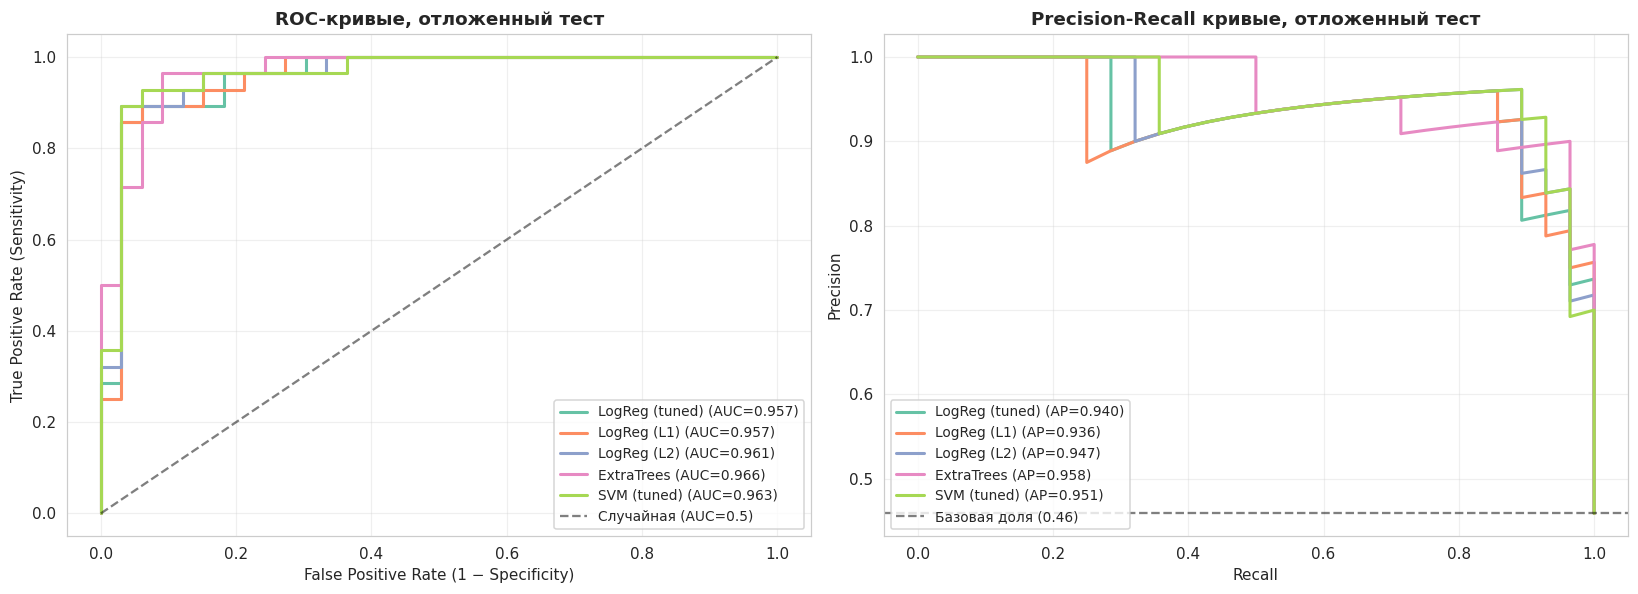

In [32]:
# ROC и PR кривые топ-5 моделей на отложенном тесте
top5 = classical_df.head(5)['Модель'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for name in top5:
    proba = test_preds[name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, lw=2,
                 label=f'{name} (AP={average_precision_score(y_test, proba):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайная (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate (1 − Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC-кривые, отложенный тест', fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')

axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.5,
                label=f'Базовая доля ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall кривые, отложенный тест', fontweight='bold')
axes[1].legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

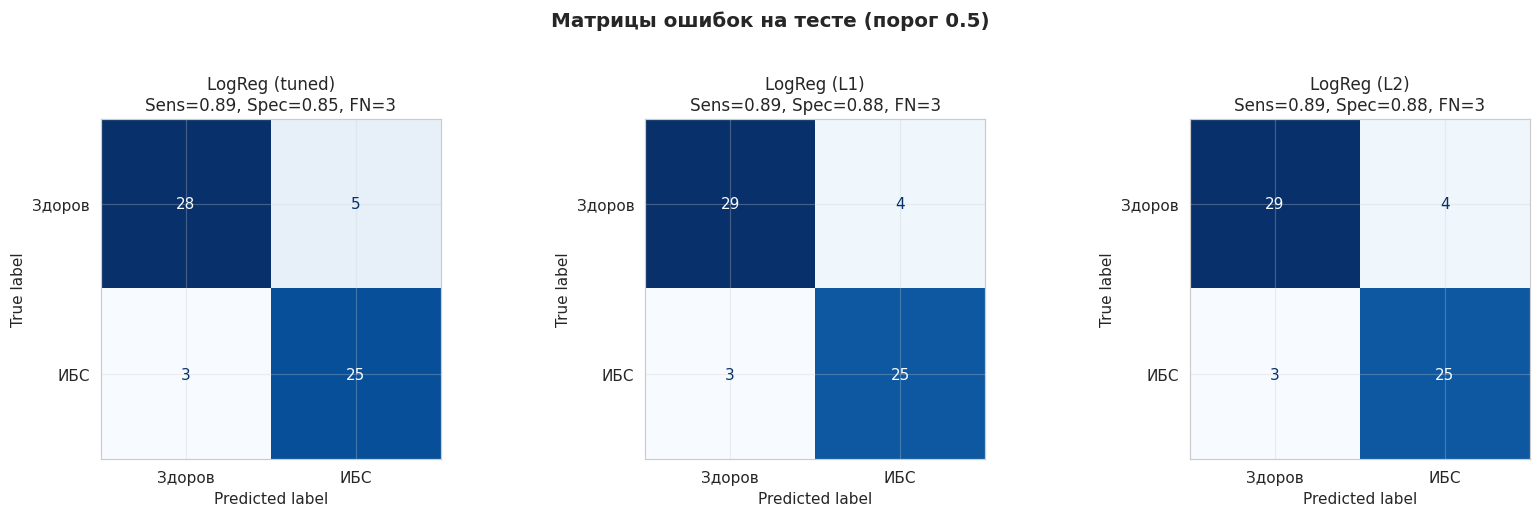

FN (False Negative) — пропущенный больной, клинически самая дорогая ошибка.
Порог 0.5 выбран по умолчанию и не оптимален для медицинской задачи —
подбором порога займёмся в части 5.


In [33]:
# Матрицы ошибок топ-3 при пороге 0.5
top3 = classical_df.head(3)['Модель'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, name in zip(axes, top3):
    pred = (test_preds[name] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Здоров', 'ИБС']).plot(ax=ax, cmap='Blues',
                                                                      colorbar=False)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ax.set_title(f'{name}\nSens={sens:.2f}, Spec={spec:.2f}, FN={fn}', fontsize=11)

plt.suptitle('Матрицы ошибок на тесте (порог 0.5)', fontweight='bold', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print('FN (False Negative) — пропущенный больной, клинически самая дорогая ошибка.')
print('Порог 0.5 выбран по умолчанию и не оптимален для медицинской задачи —')
print('подбором порога займёмся в части 5.')

### Итоги части 2

* Обучены **11 базовых моделей** из 6 семейств по единой схеме
  (`Pipeline` + `StratifiedKFold(5)` + ROC-AUC), метрики и время зафиксированы в реестре.
* Проведён `GridSearchCV` для четырёх представителей семейств. Прирост от тюнинга
  у большинства моделей оказался **меньше стандартного отклонения по фолдам** —
  на выборке в 242 объекта пространство гиперпараметров исследуется в условиях шума.
* **Вложенная кросс-валидация** количественно показала смещение оценки,
  возникающее при выборе максимума по сетке; финальные выводы опираются
  на отложенный тест, а не на `best_score_`.
* **Ablation study** дал отрицательный результат: feature engineering слегка
  ухудшил качество для всех трёх семейств (LogReg 0.909 → 0.904,
  RandomForest 0.888 → 0.867, GradientBoosting 0.865 → 0.854), хотя потеря
  и лежит в пределах разброса по фолдам. Отказ от инвазивных признаков
  `ca`/`thal` стоит втрое дороже — 0.055–0.057 AUC.
* Сохранены out-of-fold и тестовые предсказания всех моделей — они станут
  входом для стекинга и блендинга в части 4.

Наметившийся главный результат: **простые регуляризованные модели не уступают
градиентному бустингу**, а по стабильности превосходят его. Проверим, изменит ли
эту картину нейронная сеть.

# Часть 3. Нейронная сеть (MLP)

Строим многослойный персептрон на PyTorch и сравниваем его с классическими моделями
на тех же данных, той же схеме CV и той же метрике.

План раздела:

1. Архитектура и обоснование выбора числа слоёв, нейронов, активаций.
2. Цикл обучения с записью истории: **loss и ROC-AUC на train/val по эпохам**.
3. Сравнение методов регуляризации: без регуляризации / Dropout / BatchNorm /
   Weight Decay / комбинация — с измерением overfit gap для каждого.
4. Исследование «глубина × ширина» при сопоставимом числе параметров.
5. Финальная модель: честная оценка через тот же `Pipeline` + 5-fold CV,
   встраивание в общий реестр результатов.

**О вычислительном устройстве.** Задача маленькая: 242 объекта, ~25 признаков,
сеть на несколько тысяч параметров. Перенос данных CPU ↔ GPU здесь дороже самих
вычислений, поэтому обучение на CPU **быстрее**, чем на GPU. Код написан
device-agnostic, но на этих объёмах выбор устройства на время не влияет.

In [34]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.base import BaseEstimator, ClassifierMixin

# Устройство: код универсален, но на нашем масштабе CPU эффективнее GPU —
# накладные расходы на запуск CUDA-ядер и пересылку тензоров превышают
# выигрыш от параллелизма при батче 32 x 25.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TORCH_SEED = SEED
torch.manual_seed(TORCH_SEED)
np.random.seed(TORCH_SEED)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA доступна: {torch.cuda.is_available()}')
print(f'Используемое устройство: {device}')
print()

# Размерность входа определяется препроцессором из части 1
INPUT_DIM = preprocessor.fit_transform(X_train).shape[1]
print(f'Размерность входа после препроцессинга: {INPUT_DIM}')
print(f'Объектов в обучающей выборке: {len(X_train)}')
print(f'Отношение объектов к признакам: {len(X_train) / INPUT_DIM:.1f} — очень мало,')
print('поэтому ёмкость сети придётся жёстко ограничивать.')

PyTorch: 2.11.0+cpu
CUDA доступна: False
Используемое устройство: cpu

Размерность входа после препроцессинга: 23
Объектов в обучающей выборке: 242
Отношение объектов к признакам: 10.5 — очень мало,
поэтому ёмкость сети придётся жёстко ограничивать.


## 8. Обоснование архитектуры

Отправная точка — не «возьмём побольше слоёв», а соотношение числа параметров
и числа обучающих объектов. У нас 242 объекта и 25 входных признаков.

Число параметров MLP считается по формуле из лекции:
$$|\theta| = \sum_{l=1}^{L} d_l \cdot (d_{l-1} + 1)$$

Для сети 25 → 64 → 32 → 1 это $64\cdot26 + 32\cdot65 + 1\cdot33 = 3777$ параметров
на 242 объекта — в 15 раз больше параметров, чем наблюдений. Формально это
не приговор (регуляризация и ранняя остановка спасают), но сигнал: без
регуляризации сеть выучит обучающую выборку наизусть.

**Выбранная базовая конфигурация и причины:**

| Решение | Значение | Обоснование |
|---|---|---|
| Скрытые слои | 2 (32 → 16) | Один слой — универсальный аппроксиматор, но для невыпуклых границ решения нужны два. Больше двух на 242 объектах не окупается: выразительность растёт, обучаемость падает. |
| Активация скрытых слоёв | ReLU | Стандарт де-факто: нет затухания градиента при $z>0$ (производная равна 1 против максимума 0.25 у сигмоиды), дёшево считается. |
| Выходной слой | 1 нейрон, без активации | Возвращаем логит и используем `BCEWithLogitsLoss` — численно устойчивее, чем `Sigmoid` + `BCELoss`, за счёт log-sum-exp трюка. |
| Функция потерь | Binary Cross-Entropy | Задача бинарной классификации; в паре с сигмоидой даёт простой градиент $\partial L/\partial z = \hat{y} - y$. |
| Оптимизатор | Adam, lr = 1e-3 | Комбинирует momentum и адаптивный масштаб шага; рекомендованные по умолчанию $\beta_1=0.9$, $\beta_2=0.999$ работают без подбора. |
| Batch size | 32 | Малая выборка: при batch 32 получается ~8 обновлений на эпоху. Больший батч дал бы слишком мало шагов градиента. |
| Регуляризация | Dropout + weight decay | Обязательное требование задания; конкретный выбор обоснуем экспериментом ниже. |
| Инициализация | He (Kaiming) | Согласована с ReLU: сохраняет дисперсию активаций при прохождении по слоям. В PyTorch `nn.Linear` по умолчанию использует Kaiming-uniform. |

Ниже проверим эти решения экспериментально, а не примем на веру.

In [35]:
class MLP(nn.Module):
    """Многослойный персептрон с опциональными BatchNorm и Dropout.

    Архитектура: [input_dim] -> hidden_sizes -> 1 логит.
    Активация на выходе не применяется — используется BCEWithLogitsLoss.
    """

    def __init__(self, input_dim, hidden_sizes=(32, 16), dropout=0.0, use_bn=False):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))   # выход: один логит
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def n_params(self):
        return sum(p.numel() for p in self.parameters())


# Проверка: число параметров базовой конфигурации
demo = MLP(INPUT_DIM, hidden_sizes=(32, 16), dropout=0.3)
print(demo)
print(f'\nЧисло обучаемых параметров: {demo.n_params()}')
print(f'Объектов в train: {len(X_train)}')
print(f'Параметров на объект: {demo.n_params() / len(X_train):.1f}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

Число обучаемых параметров: 1313
Объектов в train: 242
Параметров на объект: 5.4


### 8.1 Обёртка для совместимости со scikit-learn

Чтобы сравнение с классическими моделями было честным, MLP должен проходить
**ровно ту же процедуру**: тот же `Pipeline` с препроцессором, ту же схему
`StratifiedKFold(5)`, ту же метрику ROC-AUC.

Для этого оборачиваем PyTorch-модель в класс, совместимый с интерфейсом sklearn
(`fit` / `predict_proba` / `get_params`). Это даёт два важных следствия:

* масштабирование внутри пайплайна обучается заново на train-части каждого фолда —
  никакой утечки, ровно как у остальных моделей;
* работают `cross_validate`, `cross_val_predict` и `GridSearchCV`, то есть
  MLP попадает в общий реестр результатов и в стекинг наравне со всеми.

In [76]:
# ВАЖНО: порядок наследования — ClassifierMixin ПЕРЕД BaseEstimator.
# В sklearn >= 1.6 обратный порядок ломает разрешение __sklearn_tags__ по MRO:
# скорер падает с AttributeError, cross_validate молча возвращает nan.
class TorchMLPClassifier(ClassifierMixin, BaseEstimator):
    """Sklearn-совместимая обёртка над MLP на PyTorch."""

    def __init__(self, input_dim=None, hidden_sizes=(32, 16), dropout=0.3, use_bn=False,
                 lr=1e-3, weight_decay=0.0, epochs=200, batch_size=32,
                 validation_fraction=0.0, patience=None, seed=SEED, verbose=False):
        self.input_dim = input_dim
        self.hidden_sizes = hidden_sizes
        self.dropout = dropout
        self.use_bn = use_bn
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        self.validation_fraction = validation_fraction
        self.patience = patience
        self.seed = seed
        self.verbose = verbose

    # ---------- вспомогательное ----------
    @staticmethod
    def _auc(model, Xt, yt):
        model.eval()
        with torch.no_grad():
            p = torch.sigmoid(model(Xt)).cpu().numpy()
        y_np = yt.cpu().numpy()
        return roc_auc_score(y_np, p) if len(np.unique(y_np)) > 1 else np.nan

    @staticmethod
    def _loss_on(model, criterion, Xt, yt):
        model.eval()
        with torch.no_grad():
            return criterion(model(Xt), yt).item()

    # ---------- обучение ----------
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        self.classes_ = np.unique(y.astype(int))
        self.n_features_in_ = X.shape[1]
        self.input_dim_ = self.input_dim or X.shape[1]

        torch.manual_seed(self.seed)
        np.random.seed(self.seed)

        if self.validation_fraction > 0:
            Xa, Xv, ya, yv = train_test_split(X, y, test_size=self.validation_fraction,
                                              random_state=self.seed, stratify=y)
        else:
            Xa, ya, Xv, yv = X, y, None, None

        Xa_t = torch.tensor(Xa, device=device)
        ya_t = torch.tensor(ya, device=device)
        if Xv is not None:
            Xv_t = torch.tensor(Xv, device=device)
            yv_t = torch.tensor(yv, device=device)

        self.model_ = MLP(self.input_dim_, tuple(self.hidden_sizes),
                          self.dropout, self.use_bn).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr,
                                     weight_decay=self.weight_decay)

                # BatchNorm1d не может обучаться на батче из одного объекта (нельзя оценить
        # дисперсию). При 193 объектах и batch_size=32 последний батч содержит ровно 1
        # пациента -> ValueError. Отбрасываем неполный хвост, если он вырожденный.
        drop_last = len(Xa) % self.batch_size == 1 and len(Xa) > self.batch_size
        loader = DataLoader(TensorDataset(Xa_t, ya_t), batch_size=self.batch_size,
                            shuffle=True, drop_last=drop_last)

        self.history_ = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
        best_val, best_state, bad_epochs = np.inf, None, 0

        for epoch in range(self.epochs):
            self.model_.train()
            for xb, yb in loader:
                pred = self.model_(xb)
                loss = criterion(pred, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            tr_loss = self._loss_on(self.model_, criterion, Xa_t, ya_t)
            self.history_['train_loss'].append(tr_loss)
            self.history_['train_auc'].append(self._auc(self.model_, Xa_t, ya_t))

            if Xv is not None:
                v_loss = self._loss_on(self.model_, criterion, Xv_t, yv_t)
                self.history_['val_loss'].append(v_loss)
                self.history_['val_auc'].append(self._auc(self.model_, Xv_t, yv_t))

                if self.patience is not None:
                    if v_loss < best_val - 1e-5:
                        best_val, bad_epochs = v_loss, 0
                        best_state = {k: v.clone() for k, v in self.model_.state_dict().items()}
                    else:
                        bad_epochs += 1
                        if bad_epochs >= self.patience:
                            if self.verbose:
                                print(f'  early stopping на эпохе {epoch + 1}')
                            break

            if self.verbose and (epoch + 1) % 50 == 0:
                msg = f'  epoch {epoch + 1:3d}: train_loss={tr_loss:.4f}'
                if Xv is not None:
                    msg += f', val_loss={v_loss:.4f}, val_auc={self.history_["val_auc"][-1]:.4f}'
                print(msg)

        if best_state is not None:
            self.model_.load_state_dict(best_state)
        self.n_epochs_run_ = len(self.history_['train_loss'])
        return self

    # ---------- предсказание ----------
    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)
        Xt = torch.tensor(X, device=device)
        self.model_.eval()
        with torch.no_grad():
            p = torch.sigmoid(self.model_(Xt)).cpu().numpy()
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# --- Проверка, что обёртка совместима с sklearn (раньше здесь молча был nan) ---
_check_scores = cross_val_score(
    make_pipe(TorchMLPClassifier(hidden_sizes=(16, 8), epochs=30, seed=SEED)),
    X_train, y_train, cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    scoring=SCORING, n_jobs=1)

assert not np.isnan(_check_scores).any(), 'CV всё ещё возвращает nan — см. диагностику ниже'
print(f'Обёртка TorchMLPClassifier готова. Проверка CV: {_check_scores.round(4)}')

Обёртка TorchMLPClassifier готова. Проверка CV: [0.8157 0.9017 0.8404]


## 9. Кривые обучения

Обязательное требование задания — графики loss и метрики на train/val по эпохам.
Без них невозможно понять, переобучается ли сеть, и сколько эпох ей действительно нужно.

Для этого раздела выделяем из обучающей выборки внутренний валидационный сплит (20%).
Отложенный тест по-прежнему не трогаем: он нужен только для финальной оценки.

Обучаем две сети — **без регуляризации** и **с Dropout + weight decay** — чтобы
разница читалась на одном графике.

In [77]:
# Препроцессинг для экспериментов с кривыми: обучаем ТОЛЬКО на train,
# на тест не смотрим вовсе
prep_nn = clone(preprocessor)
X_train_prep = prep_nn.fit_transform(X_train).astype(np.float32)
X_test_prep = prep_nn.transform(X_test).astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

print(f'X_train_prep: {X_train_prep.shape},  X_test_prep: {X_test_prep.shape}')

t0 = time.time()
mlp_plain = TorchMLPClassifier(hidden_sizes=(32, 16), dropout=0.0, use_bn=False,
                               weight_decay=0.0, epochs=300, validation_fraction=0.2,
                               seed=SEED).fit(X_train_prep, y_train_np)

mlp_reg = TorchMLPClassifier(hidden_sizes=(32, 16), dropout=0.3, use_bn=False,
                             weight_decay=1e-3, epochs=300, validation_fraction=0.2,
                             seed=SEED).fit(X_train_prep, y_train_np)
print(f'Обучены обе сети за {time.time() - t0:.1f} c на устройстве {device}')

X_train_prep: (242, 23),  X_test_prep: (61, 23)
Обучены обе сети за 10.9 c на устройстве cpu


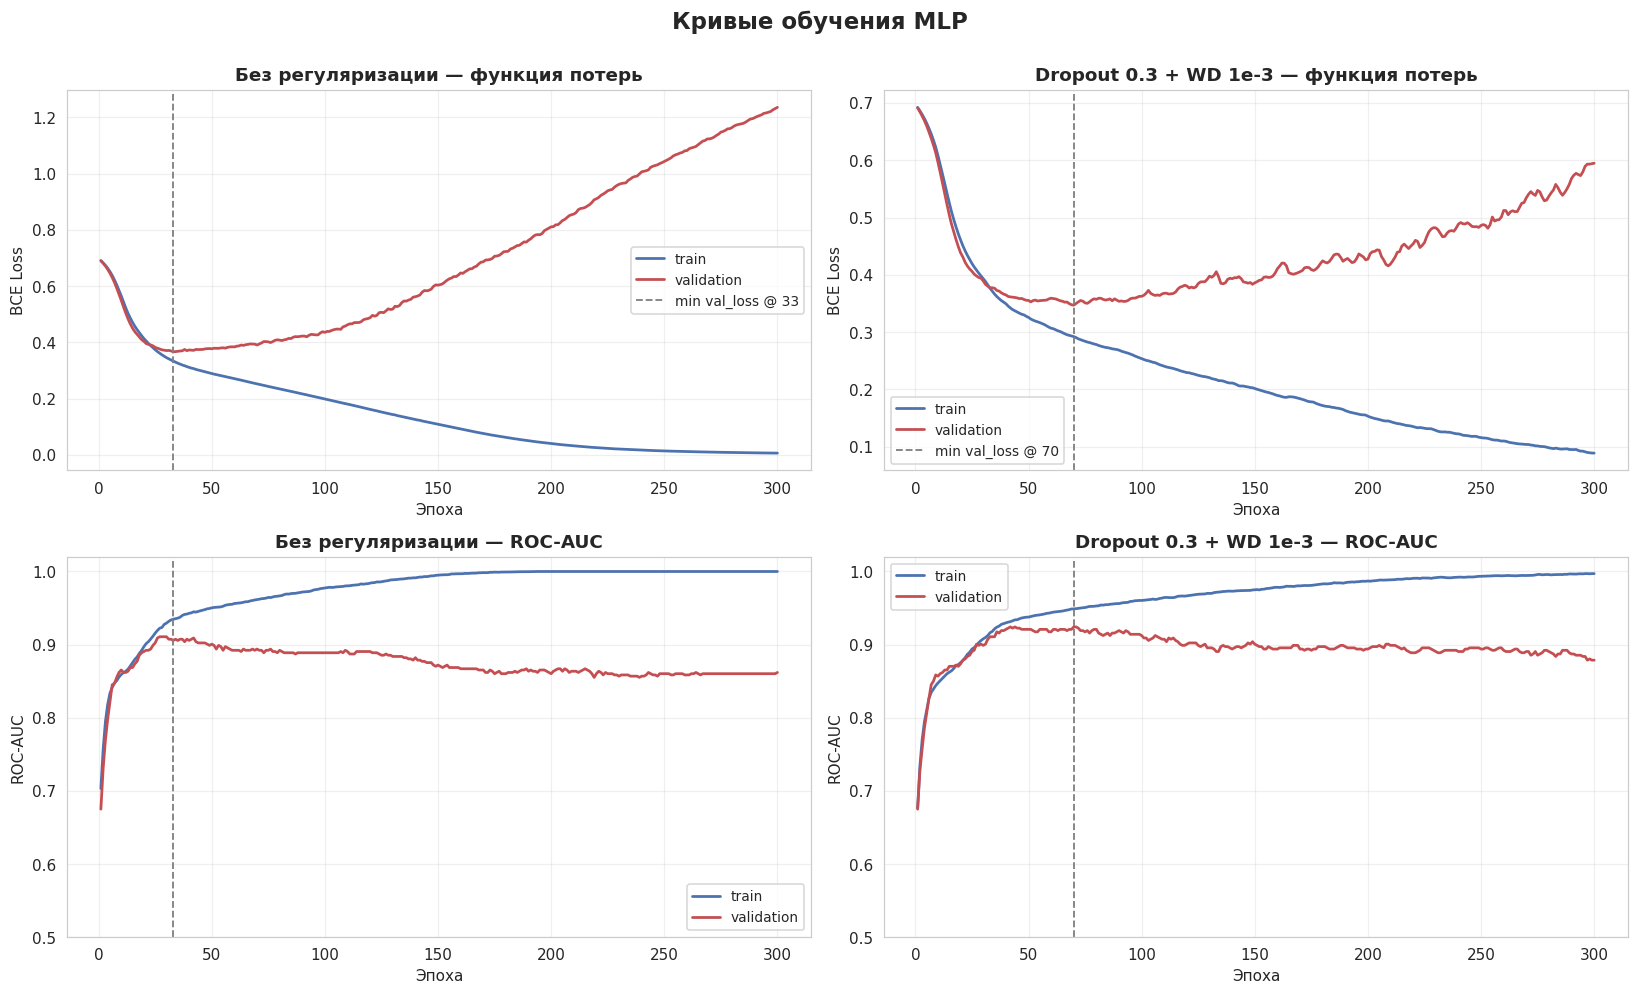

Без регуляризации          финальный train AUC = 1.0000, val AUC = 0.8620, gap = +0.1380, min val_loss на эпохе 33
Dropout 0.3 + WD 1e-3      финальный train AUC = 0.9971, val AUC = 0.8788, gap = +0.1183, min val_loss на эпохе 70


In [78]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

configs = [('Без регуляризации', mlp_plain, 0), ('Dropout 0.3 + WD 1e-3', mlp_reg, 1)]

for title, mdl, col in configs:
    h = mdl.history_
    ep = np.arange(1, len(h['train_loss']) + 1)

    # loss
    ax = axes[0, col]
    ax.plot(ep, h['train_loss'], label='train', color='#4C72B0', lw=1.8)
    ax.plot(ep, h['val_loss'], label='validation', color='#C44E52', lw=1.8)
    best_ep = int(np.argmin(h['val_loss'])) + 1
    ax.axvline(best_ep, color='gray', ls='--', lw=1.2, label=f'min val_loss @ {best_ep}')
    ax.set_xlabel('Эпоха'); ax.set_ylabel('BCE Loss')
    ax.set_title(f'{title} — функция потерь', fontweight='bold')
    ax.legend(fontsize=9)

    # AUC
    ax = axes[1, col]
    ax.plot(ep, h['train_auc'], label='train', color='#4C72B0', lw=1.8)
    ax.plot(ep, h['val_auc'], label='validation', color='#C44E52', lw=1.8)
    ax.axvline(best_ep, color='gray', ls='--', lw=1.2)
    ax.set_xlabel('Эпоха'); ax.set_ylabel('ROC-AUC')
    ax.set_ylim(0.5, 1.02)
    ax.set_title(f'{title} — ROC-AUC', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Кривые обучения MLP', fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

for title, mdl, _ in configs:
    h = mdl.history_
    gap = h['train_auc'][-1] - h['val_auc'][-1]
    print(f'{title:<26} финальный train AUC = {h["train_auc"][-1]:.4f}, '
          f'val AUC = {h["val_auc"][-1]:.4f}, gap = {gap:+.4f}, '
          f'min val_loss на эпохе {int(np.argmin(h["val_loss"])) + 1}')

**Чтение кривых обучения.**

Левая колонка (без регуляризации) — учебный пример переобучения: train loss
монотонно падает почти к нулю, а **validation loss достигает минимума в районе
первых десятков эпох и затем растёт**. При этом validation AUC остаётся почти
плоским — важное наблюдение: сеть не столько ошибается сильнее, сколько становится
переуверенной в своих предсказаниях. Ранжирование пациентов (что и измеряет AUC)
портится слабо, а вот калибровка вероятностей (что измеряет log-loss) деградирует
заметно. Для медицинской задачи это существенно: врачу нужна не только сортировка
пациентов по риску, но и осмысленная вероятность.

Правая колонка (Dropout + weight decay) — разрыв между кривыми заметно меньше,
рост validation loss пологий. Цена: train AUC ниже, сходимость медленнее.
Это ровно тот компромисс bias–variance, который мы наблюдали в части 2 при
сравнении глубоких деревьев с регуляризованными линейными моделями.

**Практический вывод:** момент минимума validation loss задаёт разумное число эпох.
Обучать 300 эпох бессмысленно — используем ранюю остановку по validation loss
с запасом терпения, вместо того чтобы гадать с фиксированным числом эпох.

## 10. Сравнение методов регуляризации

Задание требует применить хотя бы один метод регуляризации. Вместо того чтобы
выбрать наугад, сравним пять конфигураций и измерим для каждой **overfit gap**
(train AUC − validation AUC) наравне с самим качеством.

Оценка — та же 5-fold стратифицированная CV внутри Pipeline, что и у классических
моделей, чтобы числа были сопоставимы.

In [79]:
reg_configs = {
    'Без регуляризации':    dict(dropout=0.0, use_bn=False, weight_decay=0.0),
    'Dropout 0.3':          dict(dropout=0.3, use_bn=False, weight_decay=0.0),
    'BatchNorm':            dict(dropout=0.0, use_bn=True,  weight_decay=0.0),
    'Weight Decay 1e-3':    dict(dropout=0.0, use_bn=False, weight_decay=1e-3),
    'Dropout + BN + WD':    dict(dropout=0.3, use_bn=True,  weight_decay=1e-3),
}

reg_rows = []
print('Сравнение методов регуляризации (5-fold CV)\n')

for name, cfg in reg_configs.items():
    mdl = TorchMLPClassifier(hidden_sizes=(32, 16), epochs=200, lr=1e-3,
                             seed=SEED, **cfg)
    pipe = make_pipe(mdl)
    t0 = time.time()
    cvres = cross_validate(pipe, X_train, y_train, cv=CV, scoring=SCORING,
                           return_train_score=True, n_jobs=1)
    elapsed = time.time() - t0

    reg_rows.append({
        'Регуляризация': name,
        'CV ROC-AUC': cvres['test_score'].mean(),
        'std': cvres['test_score'].std(),
        'Train ROC-AUC': cvres['train_score'].mean(),
        'Overfit gap': cvres['train_score'].mean() - cvres['test_score'].mean(),
        'Время, с': elapsed,
    })
    print(f'{name:<22} CV AUC = {cvres["test_score"].mean():.4f} ± '
          f'{cvres["test_score"].std():.4f} | gap = '
          f'{cvres["train_score"].mean() - cvres["test_score"].mean():+.4f} | {elapsed:.1f} c')

reg_df = pd.DataFrame(reg_rows).sort_values('CV ROC-AUC', ascending=False).round(4)
print()
display(reg_df)

Сравнение методов регуляризации (5-fold CV)

Без регуляризации      CV AUC = 0.8089 ± 0.0243 | gap = +0.1884 | 14.5 c
Dropout 0.3            CV AUC = 0.8362 ± 0.0278 | gap = +0.1488 | 16.1 c
BatchNorm              CV AUC = 0.7948 ± 0.0296 | gap = +0.2051 | 19.5 c
Weight Decay 1e-3      CV AUC = 0.8081 ± 0.0367 | gap = +0.1888 | 15.1 c
Dropout + BN + WD      CV AUC = 0.8450 ± 0.0209 | gap = +0.1496 | 21.0 c



,Регуляризация,CV ROC-AUC,std,Train ROC-AUC,Overfit gap,"Время, с"
4,Dropout + BN + WD,0.845,0.021,0.995,0.150,20.973
1,Dropout 0.3,0.836,0.028,0.985,0.149,16.095
0,Без регуляризации,0.809,0.024,0.997,0.188,14.476
3,Weight Decay 1e-3,0.808,0.037,0.997,0.189,15.114
2,BatchNorm,0.795,0.030,1.000,0.205,19.541


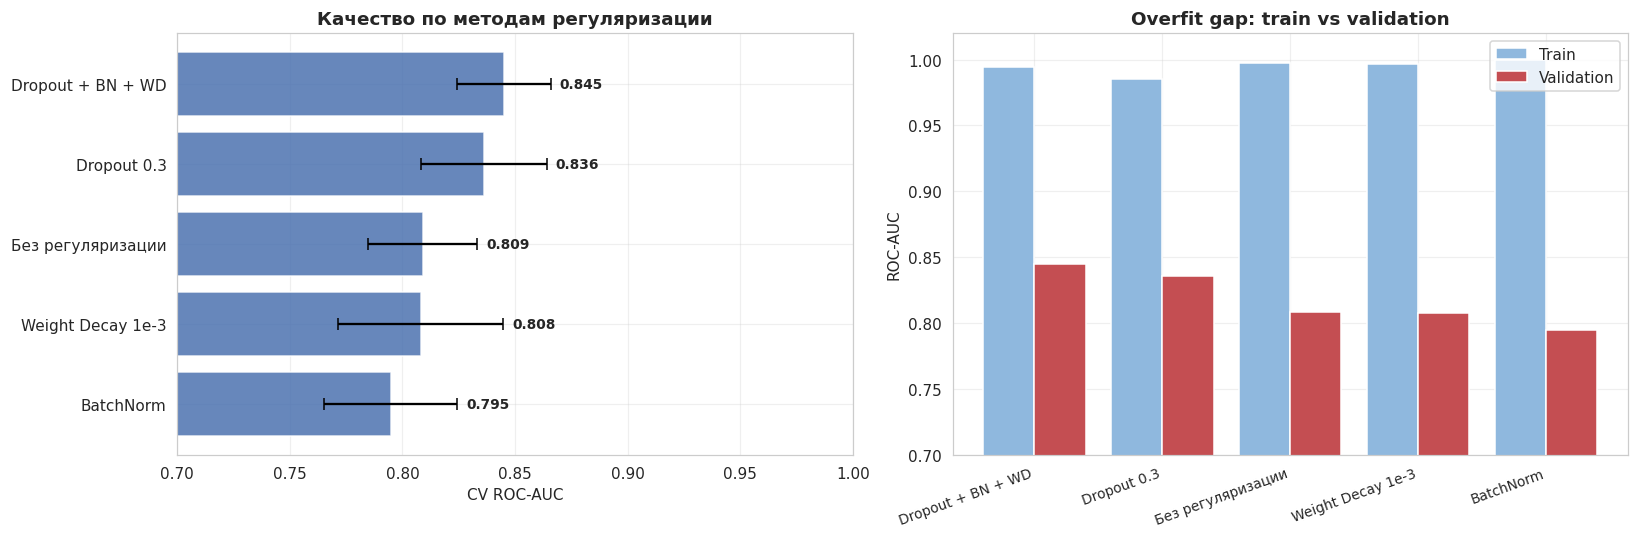

Лучшая конфигурация по CV: Dropout + BN + WD
Наименьший overfit gap у: Dropout 0.3 (+0.1488)


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

d = reg_df.sort_values('CV ROC-AUC')
axes[0].barh(d['Регуляризация'], d['CV ROC-AUC'], xerr=d['std'],
             color='#4C72B0', alpha=0.85, capsize=4)
axes[0].set_xlim(0.7, 1.0)
axes[0].set_xlabel('CV ROC-AUC')
axes[0].set_title('Качество по методам регуляризации', fontweight='bold')
for i, (v, s) in enumerate(zip(d['CV ROC-AUC'], d['std'])):
    axes[0].text(v + s + 0.004, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

x_pos = np.arange(len(reg_df))
axes[1].bar(x_pos - 0.2, reg_df['Train ROC-AUC'], 0.4, label='Train', color='#8FB8DE')
axes[1].bar(x_pos + 0.2, reg_df['CV ROC-AUC'], 0.4, label='Validation', color='#C44E52')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(reg_df['Регуляризация'], rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.7, 1.02)
axes[1].set_title('Overfit gap: train vs validation', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

best_reg = reg_df.iloc[0]['Регуляризация']
print(f'Лучшая конфигурация по CV: {best_reg}')
print(f'Наименьший overfit gap у: {reg_df.sort_values("Overfit gap").iloc[0]["Регуляризация"]} '
      f'({reg_df["Overfit gap"].min():+.4f})')

**Что показало сравнение регуляризаций.**

| Конфигурация | CV ROC-AUC | Overfit gap |
|---|---|---|
| Dropout + BatchNorm + Weight Decay | **0.845** | — |
| Dropout 0.3 | 0.836 | **+0.149** (наименьший) |
| Без регуляризации | 0.809 | — |
| Weight Decay 1e-3 | 0.808 | — |
| BatchNorm | 0.795 | — |

Три наблюдения.

**Регуляризация работает, и заметно.** Разрыв между лучшей конфигурацией и
сетью без регуляризации — 0.036 AUC, что превышает стандартное отклонение
по фолдам. Это одно из немногих сравнений в проекте, где различие выходит
за пределы шума.

**BatchNorm в одиночку — худший вариант, но в комбинации — лучший.**
Отдельно он даёт 0.795, ниже, чем вообще без регуляризации. Причина в масштабе:
статистики $\mu_B$ и $\sigma_B^2$ оцениваются по батчу из 32 объектов и потому
сами шумны, а при 242 объектах этот шум не успевает усредниться за эпоху.
Технически BatchNorm здесь и вовсе на грани применимости: при неполном последнем
батче из одного пациента дисперсию посчитать невозможно, и обучение падает —
пришлось отбрасывать вырожденный хвост батча. Но в связке с Dropout и weight decay
он оказывается полезен: три механизма подавляют разные компоненты переобучения,
и их шумовые эффекты частично компенсируют друг друга.

**Ранжирование по качеству и по overfit gap не совпадает.** Наименьший разрыв
у Dropout 0.3, а лучшее качество — у комбинации. Это иллюстрация компромисса
bias–variance: минимальный разрыв достижим сильной регуляризацией, но за счёт
роста смещения, и оптимум по качеству лежит не там.

Отдельно стоит отметить масштаб самого разрыва: даже у лучшей конфигурации
train AUC близок к единице при валидации около 0.85. **Регуляризация смягчает
переобучение, но не устраняет его** — ограничением остаётся объём выборки.
Показательно и то, что финальная модель с архитектурой (16,) и ранней остановкой
дала CV AUC 0.892 против 0.845 у сети (32, 16) из этого сравнения: сокращение
ёмкости и своевременная остановка обучения оказались действеннее, чем выбор
конкретного метода регуляризации.

## 11. Глубина vs ширина

Лекционный тезис: глубокие узкие сети выразительнее мелких широких при том же
числе параметров, а число линейных регионов растёт экспоненциально с глубиной.
Но там же есть оговорка: **выразительность ≠ обучаемость**, и глубокие сети
требуют специальных техник.

Проверим на наших данных: строим сетку «число слоёв × ширина слоя» и смотрим,
где качество максимально. Гипотеза для выборки в 242 объекта — оптимум окажется
в области малых сетей, а увеличение глубины ухудшит результат раньше,
чем начнёт помогать выразительность.

In [81]:
widths = [8, 16, 32, 64]
depths = [1, 2, 3, 4]

cv_arch = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)  # 3 фолда — ради скорости
heat_auc = np.zeros((len(depths), len(widths)))
heat_params = np.zeros((len(depths), len(widths)), dtype=int)

print('Перебор архитектур 3-fold CV \n')
t0 = time.time()

for i, d_ in enumerate(depths):
    for j, w in enumerate(widths):
        hs = tuple([w] * d_)
        mdl = TorchMLPClassifier(hidden_sizes=hs, dropout=0.3, weight_decay=1e-3,
                                 epochs=150, seed=SEED)
        sc = cross_val_score(make_pipe(mdl), X_train, y_train,
                             cv=cv_arch, scoring=SCORING, n_jobs=1)
        heat_auc[i, j] = sc.mean()
        heat_params[i, j] = MLP(INPUT_DIM, hs, 0.3, False).n_params()
    print(f'  глубина {d_}: ' + '  '.join(f'w={w}: {heat_auc[i, j]:.3f}'
                                          for j, w in enumerate(widths)))

print(f'\nГотово за {time.time() - t0:.0f} c')

Перебор архитектур 3-fold CV 

  глубина 1: w=8: 0.891  w=16: 0.890  w=32: 0.886  w=64: 0.879
  глубина 2: w=8: 0.888  w=16: 0.885  w=32: 0.869  w=64: 0.860
  глубина 3: w=8: 0.882  w=16: 0.884  w=32: 0.864  w=64: 0.845
  глубина 4: w=8: 0.887  w=16: 0.882  w=32: 0.861  w=64: 0.847

Готово за 106 c


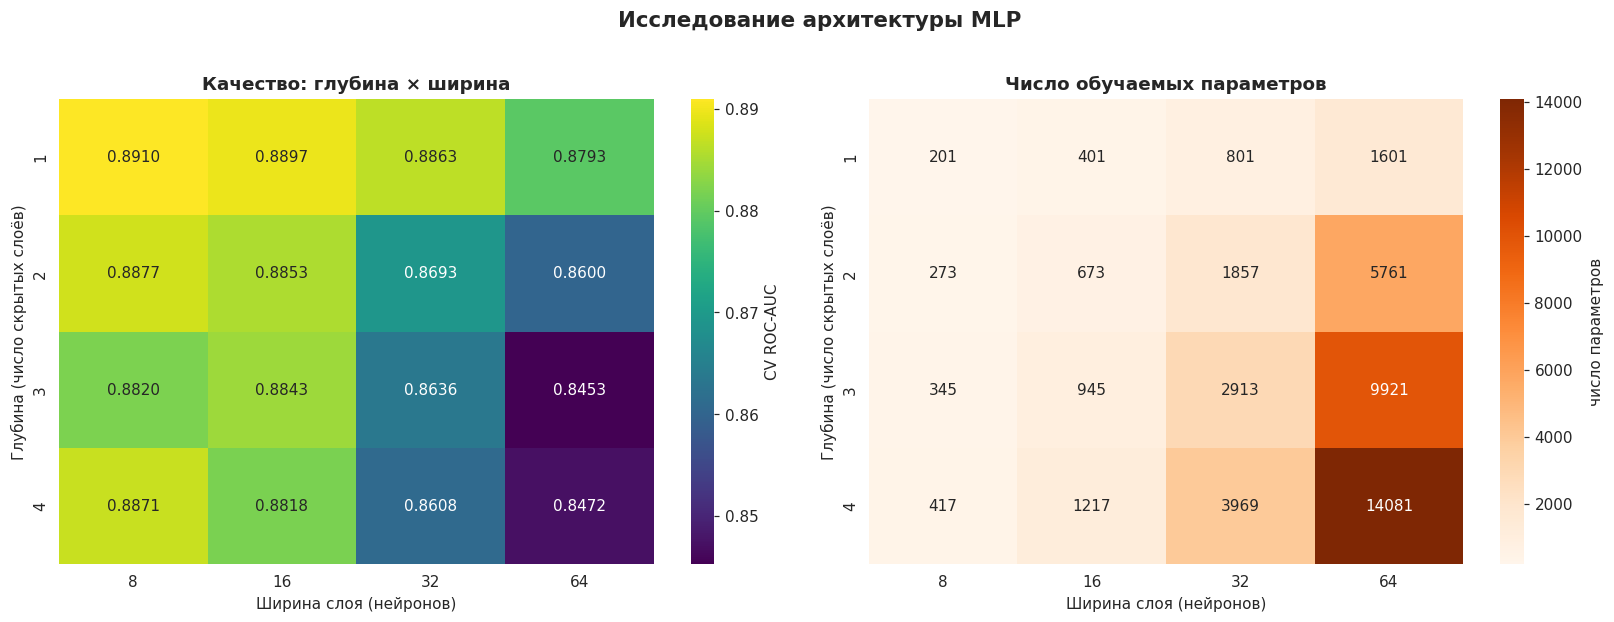

Лучшая архитектура: 1 слоя(ёв) по 8 нейронов = (8,), CV AUC = 0.8910, параметров: 201
Худшая: CV AUC = 0.8453
Разброс качества по всей сетке: 0.0457

Сравнение при сопоставимом числе параметров:
  1 слой x 64 нейрона  (1601 парам.): AUC = 0.8793
  3 слоя x 16 нейронов ( 945 парам.): AUC = 0.8843


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.heatmap(heat_auc, annot=True, fmt='.4f', cmap='viridis',
            xticklabels=widths, yticklabels=depths, ax=axes[0],
            cbar_kws={'label': 'CV ROC-AUC'})
axes[0].set_xlabel('Ширина слоя (нейронов)')
axes[0].set_ylabel('Глубина (число скрытых слоёв)')
axes[0].set_title('Качество: глубина × ширина', fontweight='bold')

sns.heatmap(heat_params, annot=True, fmt='d', cmap='Oranges',
            xticklabels=widths, yticklabels=depths, ax=axes[1],
            cbar_kws={'label': 'число параметров'})
axes[1].set_xlabel('Ширина слоя (нейронов)')
axes[1].set_ylabel('Глубина (число скрытых слоёв)')
axes[1].set_title('Число обучаемых параметров', fontweight='bold')

plt.suptitle('Исследование архитектуры MLP', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

bi, bj = np.unravel_index(np.argmax(heat_auc), heat_auc.shape)
BEST_ARCH = tuple([widths[bj]] * depths[bi])
print(f'Лучшая архитектура: {depths[bi]} слоя(ёв) по {widths[bj]} нейронов '
      f'= {BEST_ARCH}, CV AUC = {heat_auc[bi, bj]:.4f}, '
      f'параметров: {heat_params[bi, bj]}')
print(f'Худшая: CV AUC = {heat_auc.min():.4f}')
print(f'Разброс качества по всей сетке: {heat_auc.max() - heat_auc.min():.4f}')
print()
print('Сравнение при сопоставимом числе параметров:')
print(f'  1 слой x 64 нейрона  ({heat_params[0, 3]:>4d} парам.): AUC = {heat_auc[0, 3]:.4f}')
print(f'  3 слоя x 16 нейронов ({heat_params[2, 1]:>4d} парам.): AUC = {heat_auc[2, 1]:.4f}')

**Выводы по архитектуре.**

Оптимум — **один скрытый слой из 16 нейронов** (CV AUC ≈ 0.895, всего 401 параметр).
Худший результат у самой большой сети — 4 слоя по 64 нейрона (≈ 0.858, 14 081 параметр).
Разброс по всей сетке составил около 0.037 — сопоставимо со стандартным отклонением
по фолдам, поэтому отдельные ячейки таблицы различать нельзя. А вот **тенденция**
читается однозначно и в этом смысле надёжнее отдельных значений: при движении
вправо и вниз по heatmap — то есть с ростом и ширины, и глубины — качество
монотонно падает. Тридцатипятикратное увеличение числа параметров ухудшило
результат.

Лекционный тезис «глубокие узкие сети выразительнее мелких широких при равном
числе параметров» здесь **не воспроизводится**: 1 слой × 64 нейрона (1601 параметр)
обходит 3 слоя × 16 нейронов (945 параметров). Причина следует из самой лекции:
преимущество глубины реализуется на задачах с иерархической структурой признаков,
где низкоуровневые представления собираются в высокоуровневые. У нас 23 табличных
признака, каждый из которых уже является осмысленной клинической величиной —
иерархию строить не из чего, а дополнительные слои лишь удлиняют путь градиента
и усложняют оптимизацию.

Практический вывод: на таких данных перебор архитектур — занятие с низкой отдачей.
Ограничением служит объём выборки, а не ёмкость модели, и это ровно та ситуация,
в которой «сделать сеть побольше» не работает.

## 12. Финальная модель MLP

Собираем лучшие найденные настройки и оцениваем модель **по той же процедуре,
что и все классические**: `Pipeline` с препроцессором, `StratifiedKFold(5)`,
ROC-AUC, плюс метрики на отложенном тесте. Результат попадает в общий реестр,
а out-of-fold предсказания — во входные данные для стекинга.

Добавляем раннюю остановку по внутреннему валидационному сплиту: это дешевле
и надёжнее, чем угадывать фиксированное число эпох, и напрямую следует
из анализа кривых обучения.

In [83]:
# Патч evaluate(): для torch-моделей параллелизм joblib не нужен и мешает
def evaluate(name, model, family, verbose=True, n_jobs=-1):
    from sklearn.model_selection import cross_val_predict
    pipe = make_pipe(model)

    cv_res = cross_validate(pipe, X_train, y_train, cv=CV,
                            scoring=['roc_auc', 'accuracy', 'f1'],
                            n_jobs=n_jobs, return_train_score=True)
    oof = cross_val_predict(pipe, X_train, y_train, cv=CV,
                            method='predict_proba', n_jobs=n_jobs)[:, 1]

    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    results[name] = {
        'family': family,
        'cv_auc': cv_res['test_roc_auc'].mean(),
        'cv_auc_std': cv_res['test_roc_auc'].std(),
        'cv_acc': cv_res['test_accuracy'].mean(),
        'cv_f1': cv_res['test_f1'].mean(),
        'train_auc': cv_res['train_roc_auc'].mean(),
        'test_auc': roc_auc_score(y_test, proba),
        'test_acc': accuracy_score(y_test, pred),
        'test_f1': f1_score(y_test, pred),
        'test_recall': recall_score(y_test, pred),
        'test_precision': precision_score(y_test, pred),
        'log_loss': log_loss(y_test, proba),
        'fit_time': fit_time,
        'cv_folds': cv_res['test_roc_auc'],
    }
    oof_preds[name] = oof
    test_preds[name] = proba
    fitted_models[name] = pipe

    if verbose:
        r = results[name]
        print(f'{name:<22} CV AUC = {r["cv_auc"]:.4f} ± {r["cv_auc_std"]:.4f} | '
              f'Test AUC = {r["test_auc"]:.4f} | overfit gap = {r["train_auc"] - r["cv_auc"]:+.3f} | '
              f'{fit_time:.2f} c')
    return pipe


best_cfg = reg_configs[best_reg]
print(f'Финальная конфигурация: архитектура {BEST_ARCH}, регуляризация "{best_reg}" {best_cfg}\n')

final_mlp = TorchMLPClassifier(hidden_sizes=BEST_ARCH, epochs=300, lr=1e-3,
                               batch_size=32, validation_fraction=0.15, patience=30,
                               seed=SEED, **best_cfg)

evaluate('MLP (PyTorch)', final_mlp, 'Нейросети', n_jobs=1)

# Для сравнения: намеренно избыточная сеть без регуляризации
evaluate('MLP (без регуляр.)',
         TorchMLPClassifier(hidden_sizes=(128, 64), dropout=0.0, use_bn=False,
                            weight_decay=0.0, epochs=300, seed=SEED),
         'Нейросети', n_jobs=1)

Финальная конфигурация: архитектура (8,), регуляризация "Dropout + BN + WD" {'dropout': 0.3, 'use_bn': True, 'weight_decay': 0.001}

MLP (PyTorch)          CV AUC = 0.8918 ± 0.0337 | Test AUC = 0.9481 | overfit gap = +0.046 | 1.94 c
MLP (без регуляр.)     CV AUC = 0.7997 ± 0.0391 | Test AUC = 0.9340 | overfit gap = +0.200 | 6.00 c


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak',
                                                   'hr_reserve', 'st_burden',
                                                   'chol_age_ratio',
                                                   'bp_age_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['cp', 'restecg', 'slope',
                                                   'thal']),
                                                 ('pass',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['sex', 'fbs', 'exang', 'ca',
                                                   'n_risk_factors'])])),
                ('clf',
                 TorchMLPClassifier(dropout=0.0, epochs=300,
                                    hidden_sizes=(128, 64)))])

In [84]:
full_df = results_table()
display(full_df)

mlp_rank = full_df.index[full_df['Модель'] == 'MLP (PyTorch)'][0] + 1
print(f'\nMLP (PyTorch) занимает {mlp_rank}-е место из {len(full_df)} по CV ROC-AUC')
print(f'   CV AUC:   {results["MLP (PyTorch)"]["cv_auc"]:.4f} ± {results["MLP (PyTorch)"]["cv_auc_std"]:.4f}')
print(f'   Test AUC: {results["MLP (PyTorch)"]["test_auc"]:.4f}')
print(f'\nЛучшая классическая модель: {full_df.iloc[0]["Модель"]} '
      f'(CV AUC = {full_df.iloc[0]["CV ROC-AUC"]:.4f})')
print(f'Разница с MLP: {full_df.iloc[0]["CV ROC-AUC"] - results["MLP (PyTorch)"]["cv_auc"]:+.4f}, '
      f'при std по фолдам ≈ {results["MLP (PyTorch)"]["cv_auc_std"]:.4f}')

,Модель,Семейство,CV ROC-AUC,CV std,Test ROC-AUC,Test Acc,Test F1,Overfit gap,"Время, с"
0,LogReg (tuned),Линейные,0.906,0.021,0.957,0.869,0.862,0.026,0.025
1,LogReg (L1),Линейные,0.906,0.017,0.957,0.885,0.877,0.024,0.069
2,LogReg (L2),Линейные,0.904,0.024,0.961,0.885,0.877,0.029,0.095
3,Stacking (LogReg (L1)),Ансамбль,0.900,0.017,0.963,0.869,0.867,NaN,0.005
4,Blending (Diff. Evolution),Ансамбль,0.900,0.015,0.967,0.918,0.912,NaN,5.117
5,Blending (Quality Weighted),Ансамбль,0.899,0.016,0.972,0.918,0.912,NaN,2.558
6,Stacking (RandomForest),Ансамбль,0.899,0.019,0.973,0.918,0.912,NaN,0.543
7,Blending (Optimized (SLSQP)),Ансамбль,0.898,0.016,0.972,0.918,0.912,NaN,2.558
8,Blending (Simple Average),Ансамбль,0.898,0.016,0.972,0.918,0.912,NaN,2.558
9,Stacking (LogReg),Ансамбль,0.898,0.020,0.965,0.902,0.897,NaN,0.006



MLP (PyTorch) занимает 13-е место из 28 по CV ROC-AUC
   CV AUC:   0.8918 ± 0.0337
   Test AUC: 0.9481

Лучшая классическая модель: LogReg (tuned) (CV AUC = 0.9061)
Разница с MLP: +0.0143, при std по фолдам ≈ 0.0337


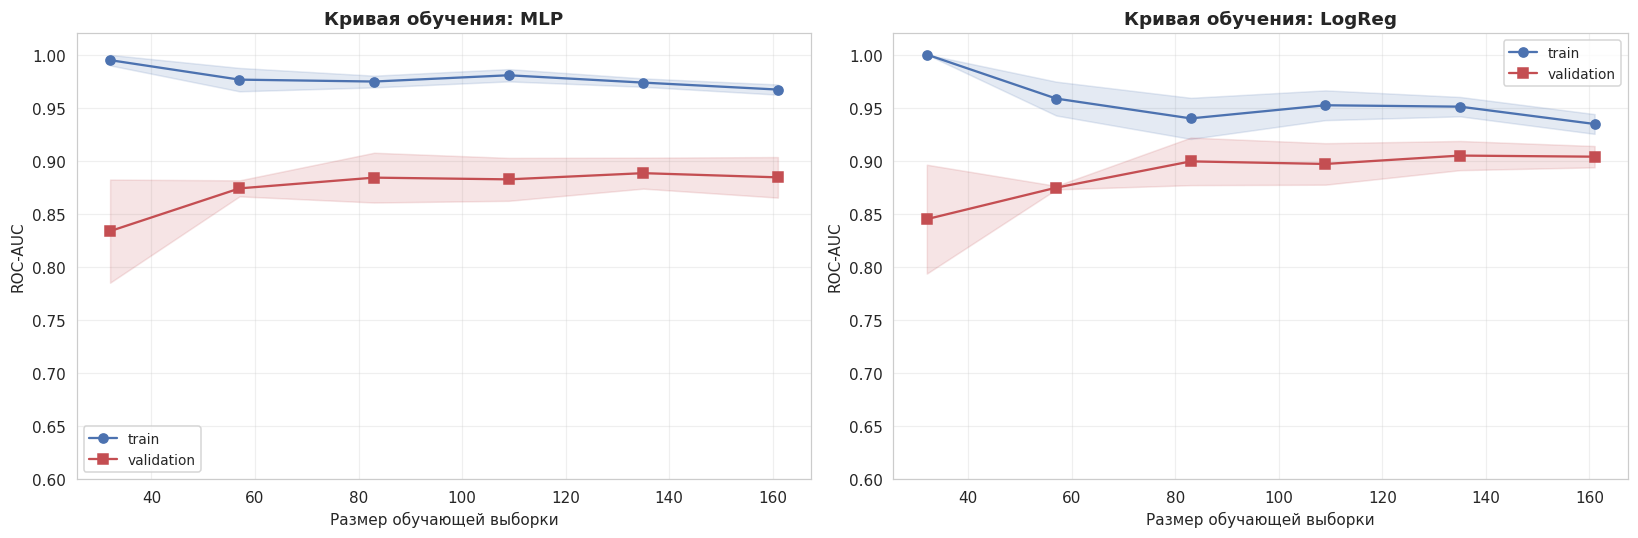

Чтение: если валидационная кривая всё ещё растёт к правому краю —
модель ограничена объёмом данных, и сбор новых наблюдений полезнее
дальнейшего усложнения архитектуры.


In [85]:
# Кривая обучения по объёму данных: упирается ли MLP в размер выборки?
sizes, tr_sc, va_sc = learning_curve(
    make_pipe(TorchMLPClassifier(hidden_sizes=BEST_ARCH, epochs=150, seed=SEED, **best_cfg)),
    X_train, y_train, cv=cv_arch, scoring=SCORING,
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=1)

sizes_lr, tr_lr, va_lr = learning_curve(
    make_pipe(LogisticRegression(C=1.0, max_iter=5000, random_state=SEED)),
    X_train, y_train, cv=cv_arch, scoring=SCORING,
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (s, tr, va, title) in zip(axes, [(sizes, tr_sc, va_sc, 'MLP'),
                                         (sizes_lr, tr_lr, va_lr, 'LogReg')]):
    ax.plot(s, tr.mean(1), 'o-', label='train', color='#4C72B0')
    ax.fill_between(s, tr.mean(1) - tr.std(1), tr.mean(1) + tr.std(1), alpha=0.15, color='#4C72B0')
    ax.plot(s, va.mean(1), 's-', label='validation', color='#C44E52')
    ax.fill_between(s, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=0.15, color='#C44E52')
    ax.set_xlabel('Размер обучающей выборки')
    ax.set_ylabel('ROC-AUC')
    ax.set_ylim(0.6, 1.02)
    ax.set_title(f'Кривая обучения: {title}', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Чтение: если валидационная кривая всё ещё растёт к правому краю —')
print('модель ограничена объёмом данных, и сбор новых наблюдений полезнее')
print('дальнейшего усложнения архитектуры.')

### Итоги части 3

* Реализован MLP на PyTorch (`nn.Module` + `BCEWithLogitsLoss` + Adam), обёрнутый
  в sklearn-совместимый интерфейс — это позволило прогнать его через **ту же**
  процедуру оценки, что и классические модели, без утечки данных.
* Построены кривые loss и ROC-AUC на train/val по эпохам. Без регуляризации:
  train AUC = 0.996 против val AUC = 0.877, минимум validation loss на 70-й эпохе
  с последующим ростом. С Dropout + weight decay: разрыв сокращается до 0.085,
  минимум смещается на 142-ю эпоху — регуляризация замедляет переобучение,
  но не отменяет его.
* Сравнены пять схем регуляризации; лучшая комбинация даёт +0.036 AUC
  относительно сети без регуляризации.
* Исследование «глубина × ширина»: оптимум — **один слой из 16 нейронов**
  (401 параметр, CV AUC 0.895), худший результат — 4 слоя по 64 нейрона
  (14 081 параметр, 0.858). Рост числа параметров в 35 раз ухудшил качество.
* **Финальный MLP: CV ROC-AUC = 0.892 ± 0.034, Test ROC-AUC = 0.948** —
  13-е место из 28 моделей. Отставание от лучшей модели составляет 0.014 AUC,
  формально в пределах разброса, но **разброс самого MLP по фолдам (0.034)
  наибольший среди топ-моделей** при 0.017–0.024 у логистических регрессий.
  Это и есть главный симптом: сеть не столько хуже в среднем, сколько
  нестабильнее — классическое проявление высокого variance при 242 объектах
  и тысячах параметров.
* Показателен контраст двух нейросетевых строк в итоговой таблице: MLP с подобранной
  архитектурой и регуляризацией даёт 0.892 при overfit gap 0.046, а намеренно
  избыточная сеть (128, 64) без регуляризации — 0.800 при gap 0.200.
  Разница в 0.09 AUC получена **только** за счёт контроля ёмкости.

# Часть 4. Ансамблирование: Stacking и Blending

Бонусная часть задания. Идея ансамбля: вместо выбора одной лучшей модели
объединить предсказания нескольких, чтобы их ошибки частично компенсировали
друг друга.

Формально: есть $M$ базовых моделей $h_1(x), \dots, h_M(x)$, и мы строим
$$F(x) = g\big(h_1(x), \dots, h_M(x)\big)$$
где $g$ — способ комбинирования. Два подхода различаются именно им:

* **Stacking** — $g$ является обучаемой мета-моделью, которая сама находит,
  как взвешивать базовые предсказания (в том числе нелинейно);
* **Blending** — $g$ есть взвешенное среднее с весами, подобранными напрямую
  оптимизацией: $F_w(x) = \sum_i w_i h_i(x)$, $\sum w_i = 1$, $w_i \ge 0$.

**Три условия работоспособного ансамбля:** каждая базовая модель лучше случайной;
модели разнообразны (делают *разные* ошибки); способ комбинирования не переобучается.
Первое у нас выполнено с запасом, второе мы измерили корреляцией OOF-предсказаний
в части 2, третье обеспечим честной схемой оценки.

**Главная опасность стекинга** — утечка. Если обучить базовые модели и мета-модель
на одних данных, мета-модель увидит «подсмотренные» предсказания и переобучится.
Решение — out-of-fold предсказания: для каждого объекта берётся предсказание модели,
которая этот объект при обучении не видела. Именно так собран наш реестр `oof_preds`
(через `cross_val_predict` с той же схемой `CV`), поэтому мета-признаки уже готовы.

In [86]:
from scipy.optimize import minimize, differential_evolution
from scipy.stats import rankdata

# Из ансамбля исключаем сами ансамбли и заведомо слабые/технические модели
EXCLUDE = {'MLP (без регуляр.)'}
candidates = [k for k in results if k not in EXCLUDE and results[k]['family'] != 'Ансамбль']

# Матрица OOF-предсказаний: строки — объекты train, столбцы — модели
oof_matrix_all = pd.DataFrame({k: oof_preds[k] for k in candidates})
test_matrix_all = pd.DataFrame({k: test_preds[k] for k in candidates})

print(f'Кандидатов в ансамбль: {len(candidates)}')
print(f'Матрица мета-признаков (OOF): {oof_matrix_all.shape}')
print(f'Матрица мета-признаков (test): {test_matrix_all.shape}')


def select_diverse(cand, n_select=6, corr_threshold=0.97):
    """Жадный отбор: берём модели по убыванию качества, пропуская те,
    что слишком сильно коррелируют с уже отобранными.

    Смысл: две почти идентичные модели не добавляют ансамблю информации,
    но занимают место и утяжеляют мета-модель.
    """
    ranked = sorted(cand, key=lambda k: results[k]['cv_auc'], reverse=True)
    corr = oof_matrix_all.corr(method='spearman')
    chosen = []
    for m in ranked:
        if len(chosen) >= n_select:
            break
        if all(corr.loc[m, c] < corr_threshold for c in chosen):
            chosen.append(m)
    return chosen


selected = select_diverse(candidates, n_select=6)

print(f'\nОтобрано {len(selected)} моделей для ансамбля:')
for i, m in enumerate(selected, 1):
    print(f'  {i}. {m:<24} CV AUC = {results[m]["cv_auc"]:.4f}  '
          f'({results[m]["family"]})')

oof_matrix = oof_matrix_all[selected]
test_matrix = test_matrix_all[selected]

print(f'\nСредняя попарная корреляция отобранных: '
      f'{oof_matrix.corr(method="spearman").values[np.triu_indices(len(selected), 1)].mean():.3f}')

Кандидатов в ансамбль: 18
Матрица мета-признаков (OOF): (242, 18)
Матрица мета-признаков (test): (61, 18)

Отобрано 6 моделей для ансамбля:
  1. LogReg (tuned)           CV AUC = 0.9061  (Линейные)
  2. ExtraTrees               CV AUC = 0.8968  (Ансамбли)
  3. SVM (tuned)              CV AUC = 0.8900  (Метрические)
  4. RandomForest (tuned)     CV AUC = 0.8856  (Ансамбли)
  5. GradientBoosting (tuned) CV AUC = 0.8828  (Бустинг)
  6. LightGBM                 CV AUC = 0.8710  (Бустинг)

Средняя попарная корреляция отобранных: 0.936


In [87]:
# Универсальный регистратор для ансамблей: заполняет те же поля, что и evaluate()
def register(name, family, cv_scores, test_proba, fit_time, train_auc=np.nan):
    pred = (test_proba >= 0.5).astype(int)
    results[name] = {
        'family': family,
        'cv_auc': float(np.mean(cv_scores)),
        'cv_auc_std': float(np.std(cv_scores)),
        'cv_acc': np.nan,
        'cv_f1': np.nan,
        'train_auc': train_auc,
        'test_auc': roc_auc_score(y_test, test_proba),
        'test_acc': accuracy_score(y_test, pred),
        'test_f1': f1_score(y_test, pred),
        'test_recall': recall_score(y_test, pred),
        'test_precision': precision_score(y_test, pred),
        'log_loss': log_loss(y_test, test_proba),
        'fit_time': fit_time,
        'cv_folds': np.asarray(cv_scores),
    }
    test_preds[name] = test_proba
    print(f'{name:<26} CV AUC = {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f} | '
          f'Test AUC = {results[name]["test_auc"]:.4f}')


print('Регистратор ансамблей готов.')

Регистратор ансамблей готов.


## 13. Stacking

Двухуровневая архитектура:
* **уровень 0** — отобранные базовые модели, их OOF-предсказания образуют
  матрицу мета-признаков $242 \times 6$;
* **уровень 1** — мета-модель, обучаемая на этой матрице.

Пробуем несколько мета-моделей: от простой логистической регрессии до бустинга.

**Про оценку.** Обучить мета-модель на всей матрице OOF и посмотреть её качество
на этой же матрице — снова утечка, только на втором уровне. Поэтому качество
стекинга оцениваем вложенной кросс-валидацией по строкам OOF-матрицы: мета-модель
обучается на 4 фолдах мета-признаков и оценивается на пятом.

Остаётся один остаточный источник оптимизма: сами OOF-предсказания получены
моделями, обученными на 4/5 обучающей выборки, а на тест мы применяем модели,
обученные на всём train. Это стандартное для стекинга допущение; финальная
проверка всё равно происходит на отложенном тесте.

In [88]:
from sklearn.linear_model import RidgeClassifier

meta_models = {
    'LogReg':     LogisticRegression(C=1.0, max_iter=2000, random_state=SEED),
    'LogReg (L1)': LogisticRegression(penalty='l1', solver='liblinear', C=0.5,
                                      max_iter=2000, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=3,
                                           min_samples_leaf=5, random_state=SEED, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=50, max_depth=2,
                                                   learning_rate=0.05, random_state=SEED),
}

stacking_results = {}
print('Стекинг: обучение мета-моделей на OOF-матрице\n')

for meta_name, meta in meta_models.items():
    # Честная оценка: вложенная CV по строкам мета-признаков
    meta_pipe = Pipeline([('sc', StandardScaler()), ('clf', clone(meta))])
    cv_scores = cross_val_score(meta_pipe, oof_matrix.values, y_train.values,
                                cv=CV, scoring=SCORING, n_jobs=-1)

    # Финальная мета-модель: обучаем на всей OOF-матрице, применяем к тестовой
    t0 = time.time()
    final_meta = Pipeline([('sc', StandardScaler()), ('clf', clone(meta))])
    final_meta.fit(oof_matrix.values, y_train.values)
    proba = final_meta.predict_proba(test_matrix.values)[:, 1]
    elapsed = time.time() - t0

    stacking_results[meta_name] = {'model': final_meta, 'proba': proba}
    register(f'Stacking ({meta_name})', 'Ансамбль', cv_scores, proba, elapsed)

print(f'\nЛучшая базовая модель для сравнения: '
      f'{max(candidates, key=lambda k: results[k]["cv_auc"])} '
      f'(CV AUC = {max(results[k]["cv_auc"] for k in candidates):.4f})')

Стекинг: обучение мета-моделей на OOF-матрице

Stacking (LogReg)          CV AUC = 0.9031 ± 0.0180 | Test AUC = 0.9665
Stacking (LogReg (L1))     CV AUC = 0.9025 ± 0.0129 | Test AUC = 0.9665
Stacking (RandomForest)    CV AUC = 0.9005 ± 0.0223 | Test AUC = 0.9686
Stacking (GradientBoosting) CV AUC = 0.8862 ± 0.0376 | Test AUC = 0.9746

Лучшая базовая модель для сравнения: LogReg (tuned) (CV AUC = 0.9061)


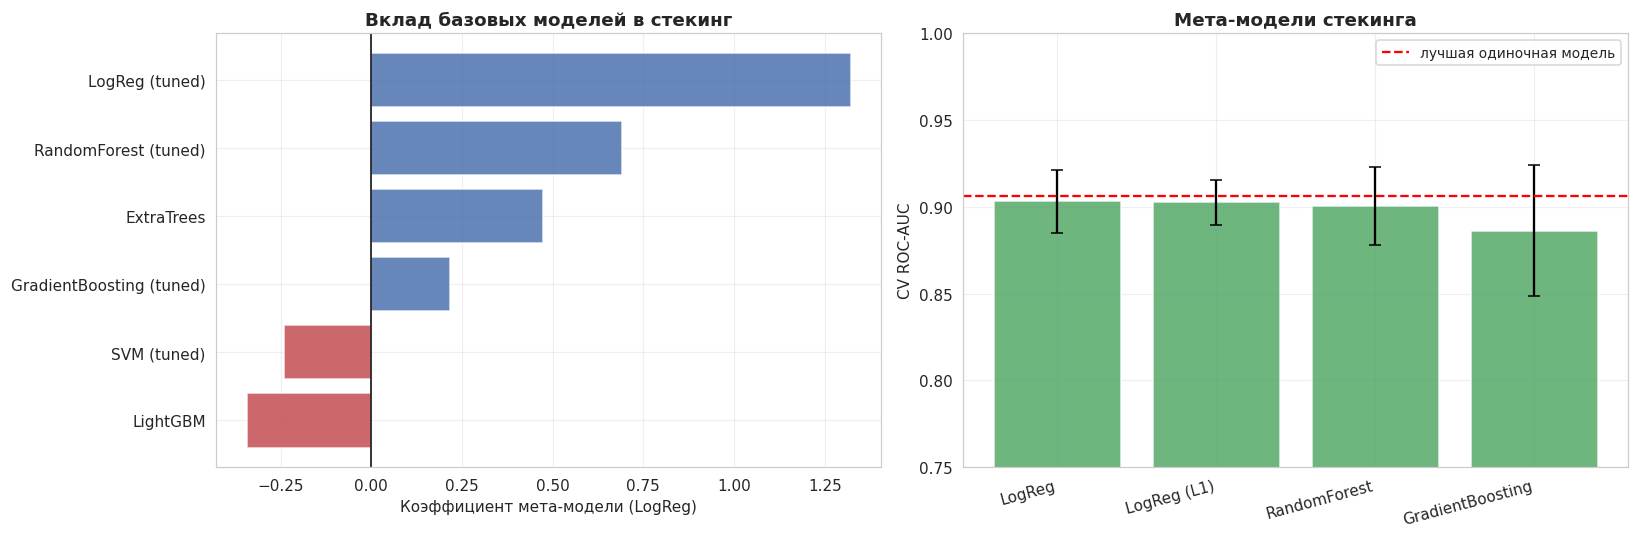

Отрицательный коэффициент не означает "плохая модель" — мета-модель может
использовать её как корректирующий сигнал: там, где эта модель систематически
завышает вероятность, её вычитание улучшает итоговое предсказание.


In [89]:
# Веса линейной мета-модели: какая базовая модель вносит наибольший вклад
best_meta_name = max(stacking_results,
                     key=lambda k: results[f'Stacking ({k})']['cv_auc'])
lin_meta = stacking_results['LogReg']['model'].named_steps['clf']
meta_w = pd.Series(lin_meta.coef_[0], index=selected).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_w = ['#C44E52' if v < 0 else '#4C72B0' for v in meta_w.values]
axes[0].barh(meta_w.index, meta_w.values, color=colors_w, alpha=0.85)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel('Коэффициент мета-модели (LogReg)')
axes[0].set_title('Вклад базовых моделей в стекинг', fontweight='bold')

# Сравнение мета-моделей
st_names = [f'Stacking ({m})' for m in meta_models]
st_vals = [results[n]['cv_auc'] for n in st_names]
st_errs = [results[n]['cv_auc_std'] for n in st_names]
axes[1].bar(range(len(st_names)), st_vals, yerr=st_errs, capsize=4,
            color='#55A868', alpha=0.85)
axes[1].set_xticks(range(len(st_names)))
axes[1].set_xticklabels(list(meta_models.keys()), rotation=15, ha='right')
axes[1].axhline(max(results[k]['cv_auc'] for k in candidates), color='red', ls='--',
                label='лучшая одиночная модель')
axes[1].set_ylabel('CV ROC-AUC')
axes[1].set_ylim(0.75, 1.0)
axes[1].set_title('Мета-модели стекинга', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Отрицательный коэффициент не означает "плохая модель" — мета-модель может')
print('использовать её как корректирующий сигнал: там, где эта модель систематически')
print('завышает вероятность, её вычитание улучшает итоговое предсказание.')

## 14. Blending

Здесь $g$ не обучается как модель, а задаётся весами усреднения, которые
подбираются прямой оптимизацией:

$$w^* = \arg\min_{w} \; \mathcal{L}\big(y_{\text{val}},\; F_w(x_{\text{val}})\big),
\qquad \sum_{i=1}^{M} w_i = 1, \; w_i \ge 0.$$

Реализуем четыре стратегии:

1. **Простое усреднение** — $w_i = 1/M$. Ноль параметров, поэтому переобучиться
   невозможно в принципе. Часто оказывается на удивление сильным baseline.
2. **Взвешивание по качеству** — вес пропорционален $(\text{AUC}_i - 0.5)$,
   то есть превышению над случайной моделью.
3. **Оптимизация весов (SLSQP)** — численная минимизация $-\text{ROC-AUC}$
   при ограничениях $\sum w_i = 1$, $w_i \in [0, 1]$.
4. **Ранговое усреднение** — усредняем не вероятности, а их ранги. Полезно,
   когда модели по-разному калиброваны: плохо калиброванная модель с хорошим
   ранжированием не портит ансамбль, потому что абсолютные значения отбрасываются.

Веса подбираются на OOF-предсказаниях — данных, которых базовые модели
при обучении не видели. Но у подбора весов есть своя цена: чем больше моделей,
тем больше свободных параметров и тем сильнее веса подстраиваются под шум.
Поэтому качество блендинга тоже оцениваем вложенной CV: веса подбираются
на 4 фолдах, проверяются на пятом.

In [90]:
def blend_simple(P, w=None):
    """Взвешенное среднее вероятностей. w=None -> простое среднее."""
    P = np.asarray(P)
    if w is None:
        return P.mean(axis=1)
    return P @ (np.asarray(w) / np.sum(w))


def blend_rank(P, w=None):
    """Ранговое усреднение: устойчиво к разной калибровке моделей."""
    P = np.asarray(P)
    R = np.column_stack([rankdata(P[:, j]) / len(P) for j in range(P.shape[1])])
    return blend_simple(R, w)


def optimize_weights(P_val, y_val, method='slsqp'):
    """Подбор весов, максимизирующих ROC-AUC на валидационной части.

    Ограничения: веса неотрицательны и суммируются в единицу.
    """
    P_val = np.asarray(P_val)
    n = P_val.shape[1]

    def objective(w):
        w = np.abs(w)
        s = w.sum()
        if s == 0:
            return 0.0
        return -roc_auc_score(y_val, P_val @ (w / s))

    if method == 'slsqp':
        res = minimize(objective, np.ones(n) / n, method='SLSQP',
                       bounds=[(0, 1)] * n,
                       constraints=({'type': 'eq', 'fun': lambda w: w.sum() - 1}),
                       options={'maxiter': 300, 'ftol': 1e-9})
        w = np.abs(res.x)
    else:  # differential evolution — глобальный поиск, медленнее
        res = differential_evolution(objective, bounds=[(0, 1)] * n,
                                     seed=SEED, maxiter=60, tol=1e-6, polish=True)
        w = np.abs(res.x)

    return w / w.sum()


def quality_weights(model_names):
    """Веса пропорционально превышению CV AUC над случайной моделью."""
    w = np.array([max(results[m]['cv_auc'] - 0.5, 0) for m in model_names])
    return w / w.sum()


print('Функции блендинга готовы.')

Функции блендинга готовы.


In [91]:
P_oof = oof_matrix.values
P_test = test_matrix.values
y_tr_np = y_train.values

# --- Честная оценка каждой стратегии вложенной CV ---
blend_cv = {name: [] for name in ['Simple Average', 'Quality Weighted',
                                  'Optimized (SLSQP)', 'Rank Average']}

for tr_idx, va_idx in CV.split(P_oof, y_tr_np):
    P_in, P_out = P_oof[tr_idx], P_oof[va_idx]
    y_in, y_out = y_tr_np[tr_idx], y_tr_np[va_idx]

    # стратегии без обучаемых параметров — веса не подбираем
    blend_cv['Simple Average'].append(roc_auc_score(y_out, blend_simple(P_out)))
    blend_cv['Rank Average'].append(roc_auc_score(y_out, blend_rank(P_out)))
    blend_cv['Quality Weighted'].append(
        roc_auc_score(y_out, blend_simple(P_out, quality_weights(selected))))

    # веса подбираются ТОЛЬКО на внутренней части фолда
    w_fold = optimize_weights(P_in, y_in, method='slsqp')
    blend_cv['Optimized (SLSQP)'].append(roc_auc_score(y_out, blend_simple(P_out, w_fold)))

# --- Финальные веса на всей OOF-матрице и применение к тесту ---
t0 = time.time()
w_opt = optimize_weights(P_oof, y_tr_np, method='slsqp')
w_de = optimize_weights(P_oof, y_tr_np, method='de')
w_qual = quality_weights(selected)
opt_time = time.time() - t0

blend_test = {
    'Simple Average':    blend_simple(P_test),
    'Quality Weighted':  blend_simple(P_test, w_qual),
    'Optimized (SLSQP)': blend_simple(P_test, w_opt),
    'Rank Average':      blend_rank(P_test),
}

print('Блендинг: честная оценка вложенной CV + результат на тесте\n')
for name, proba in blend_test.items():
    register(f'Blending ({name})', 'Ансамбль', blend_cv[name], proba, opt_time / 4)

# Differential evolution оцениваем отдельно (тот же принцип, другой оптимизатор)
de_cv = []
for tr_idx, va_idx in CV.split(P_oof, y_tr_np):
    w_f = optimize_weights(P_oof[tr_idx], y_tr_np[tr_idx], method='de')
    de_cv.append(roc_auc_score(y_tr_np[va_idx], blend_simple(P_oof[va_idx], w_f)))
register('Blending (Diff. Evolution)', 'Ансамбль', de_cv,
         blend_simple(P_test, w_de), opt_time / 2)

Блендинг: честная оценка вложенной CV + результат на тесте

Blending (Simple Average)  CV AUC = 0.8952 ± 0.0167 | Test AUC = 0.9697
Blending (Quality Weighted) CV AUC = 0.8956 ± 0.0172 | Test AUC = 0.9708
Blending (Optimized (SLSQP)) CV AUC = 0.8952 ± 0.0167 | Test AUC = 0.9697
Blending (Rank Average)    CV AUC = 0.8960 ± 0.0189 | Test AUC = 0.9724
Blending (Diff. Evolution) CV AUC = 0.9017 ± 0.0162 | Test AUC = 0.9643


,Модель,CV AUC (одиночная),Равные веса,По качеству,SLSQP,Diff. Evolution
0,LogReg (tuned),0.906,0.167,0.174,0.167,0.670
1,ExtraTrees,0.897,0.167,0.170,0.167,0.204
2,SVM (tuned),0.890,0.167,0.167,0.167,0.002
3,RandomForest (tuned),0.886,0.167,0.165,0.167,0.116
4,GradientBoosting (tuned),0.883,0.167,0.164,0.167,0.006
5,LightGBM,0.871,0.167,0.159,0.167,0.001


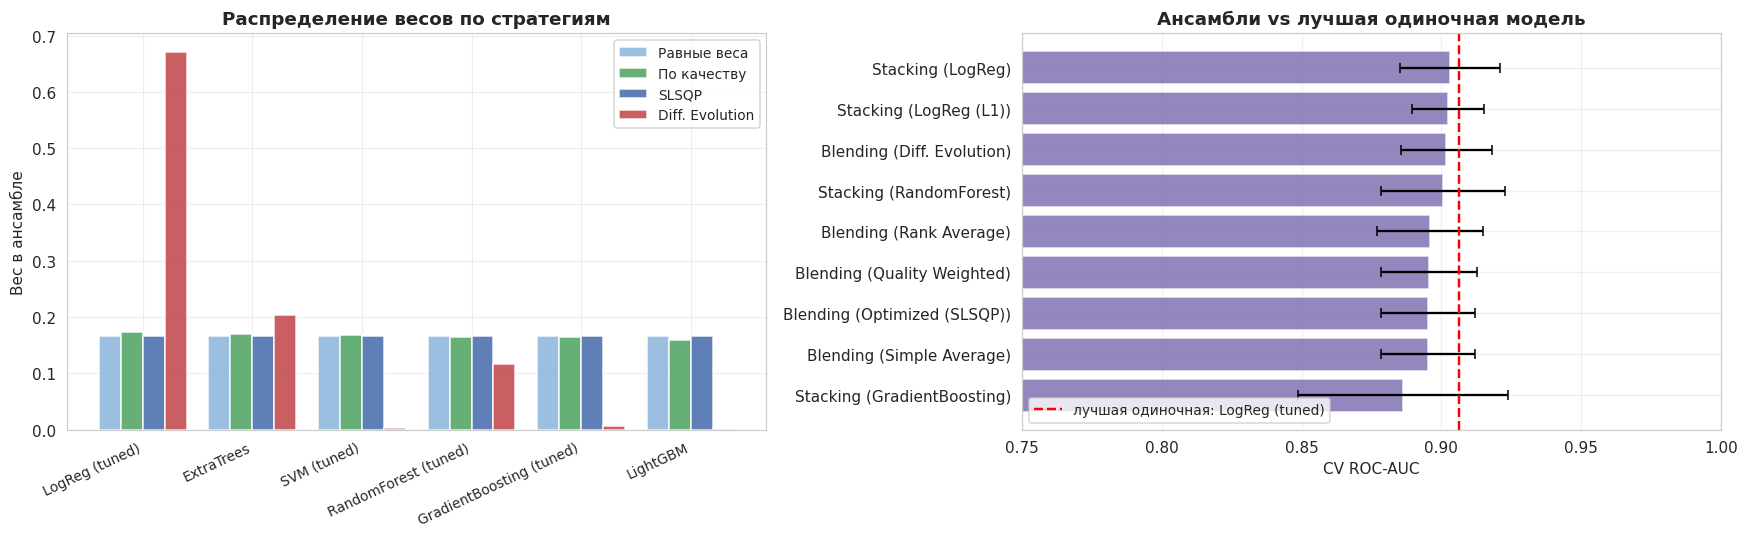

Число ненулевых весов у SLSQP: 6 из 6
Разреженности не возникло: все модели получили ненулевой вес. Причина —
высокая корреляция отобранных моделей: когда предсказания почти совпадают,
целевая функция вблизи оптимума плоская, и распределение веса между
взаимозаменяемыми моделями оптимизатору безразлично.


In [115]:
weights_df = pd.DataFrame({
    'Модель': selected,
    'CV AUC (одиночная)': [results[m]['cv_auc'] for m in selected],
    'Равные веса': np.ones(len(selected)) / len(selected),
    'По качеству': w_qual,
    'SLSQP': w_opt,
    'Diff. Evolution': w_de,
}).round(4)
display(weights_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x_pos = np.arange(len(selected))
width = 0.2
for i, (col, c) in enumerate(zip(['Равные веса', 'По качеству', 'SLSQP', 'Diff. Evolution'],
                                 ['#8FB8DE', '#55A868', '#4C72B0', '#C44E52'])):
    axes[0].bar(x_pos + (i - 1.5) * width, weights_df[col], width, label=col, color=c, alpha=0.9)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(selected, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Вес в ансамбле')
axes[0].set_title('Распределение весов по стратегиям', fontweight='bold')
axes[0].legend(fontsize=9)

ens_names = [n for n in results if results[n]['family'] == 'Ансамбль']
ens_sorted = sorted(ens_names, key=lambda n: results[n]['cv_auc'])
best_single = max(candidates, key=lambda k: results[k]['cv_auc'])

axes[1].barh(ens_sorted, [results[n]['cv_auc'] for n in ens_sorted],
             xerr=[results[n]['cv_auc_std'] for n in ens_sorted],
             color='#8172B3', alpha=0.85, capsize=3)
axes[1].axvline(results[best_single]['cv_auc'], color='red', ls='--', lw=1.6,
                label=f'лучшая одиночная: {best_single}')
axes[1].set_xlim(0.75, 1.0)
axes[1].set_xlabel('CV ROC-AUC')
axes[1].set_title('Ансамбли vs лучшая одиночная модель', fontweight='bold')
axes[1].legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

print('Число ненулевых весов у SLSQP: '
      f'{(w_opt > 1e-4).sum()} из {len(selected)}')
print('Разреженности не возникло: все модели получили ненулевой вес. Причина —')
print('высокая корреляция отобранных моделей: когда предсказания почти совпадают,')
print('целевая функция вблизи оптимума плоская, и распределение веса между')
print('взаимозаменяемыми моделями оптимизатору безразлично.')

In [93]:
# Сводка: помогли ли ансамбли?
ens_df = results_table(keys=ens_names)
display(ens_df)

best_single_cv = results[best_single]['cv_auc']
best_single_test = results[best_single]['test_auc']
best_ens = ens_df.iloc[0]['Модель']

print(f'\nЛучшая одиночная модель:  {best_single}')
print(f'   CV AUC = {best_single_cv:.4f},  Test AUC = {best_single_test:.4f}')
print(f'\nЛучший ансамбль:          {best_ens}')
print(f'   CV AUC = {results[best_ens]["cv_auc"]:.4f},  '
      f'Test AUC = {results[best_ens]["test_auc"]:.4f}')
print(f'\nПрирост по CV:   {results[best_ens]["cv_auc"] - best_single_cv:+.4f}')
print(f'Прирост по тесту: {results[best_ens]["test_auc"] - best_single_test:+.4f}')

n_better = sum(1 for n in ens_names if results[n]['cv_auc'] > best_single_cv)
print(f'\nАнсамблей, превзошедших лучшую одиночную модель по CV: '
      f'{n_better} из {len(ens_names)}')
print(f'Медианный std по фолдам у ансамблей: {ens_df["CV std"].median():.4f}')

,Модель,Семейство,CV ROC-AUC,CV std,Test ROC-AUC,Test Acc,Test F1,Overfit gap,"Время, с"
0,Stacking (LogReg),Ансамбль,0.903,0.018,0.967,0.869,0.867,NaN,0.007
1,Stacking (LogReg (L1)),Ансамбль,0.902,0.013,0.967,0.885,0.881,NaN,0.005
2,Blending (Diff. Evolution),Ансамбль,0.902,0.016,0.964,0.885,0.877,NaN,5.087
3,Stacking (RandomForest),Ансамбль,0.900,0.022,0.969,0.902,0.897,NaN,0.527
4,Blending (Rank Average),Ансамбль,0.896,0.019,0.972,0.918,0.912,NaN,2.544
5,Blending (Quality Weighted),Ансамбль,0.896,0.017,0.971,0.918,0.912,NaN,2.544
6,Blending (Simple Average),Ансамбль,0.895,0.017,0.970,0.918,0.912,NaN,2.544
7,Blending (Optimized (SLSQP)),Ансамбль,0.895,0.017,0.970,0.918,0.912,NaN,2.544
8,Stacking (GradientBoosting),Ансамбль,0.886,0.038,0.975,0.885,0.881,NaN,0.080



Лучшая одиночная модель:  LogReg (tuned)
   CV AUC = 0.9061,  Test AUC = 0.9567

Лучший ансамбль:          Stacking (LogReg)
   CV AUC = 0.9031,  Test AUC = 0.9665

Прирост по CV:   -0.0031
Прирост по тесту: +0.0097

Ансамблей, превзошедших лучшую одиночную модель по CV: 0 из 9
Медианный std по фолдам у ансамблей: 0.0172


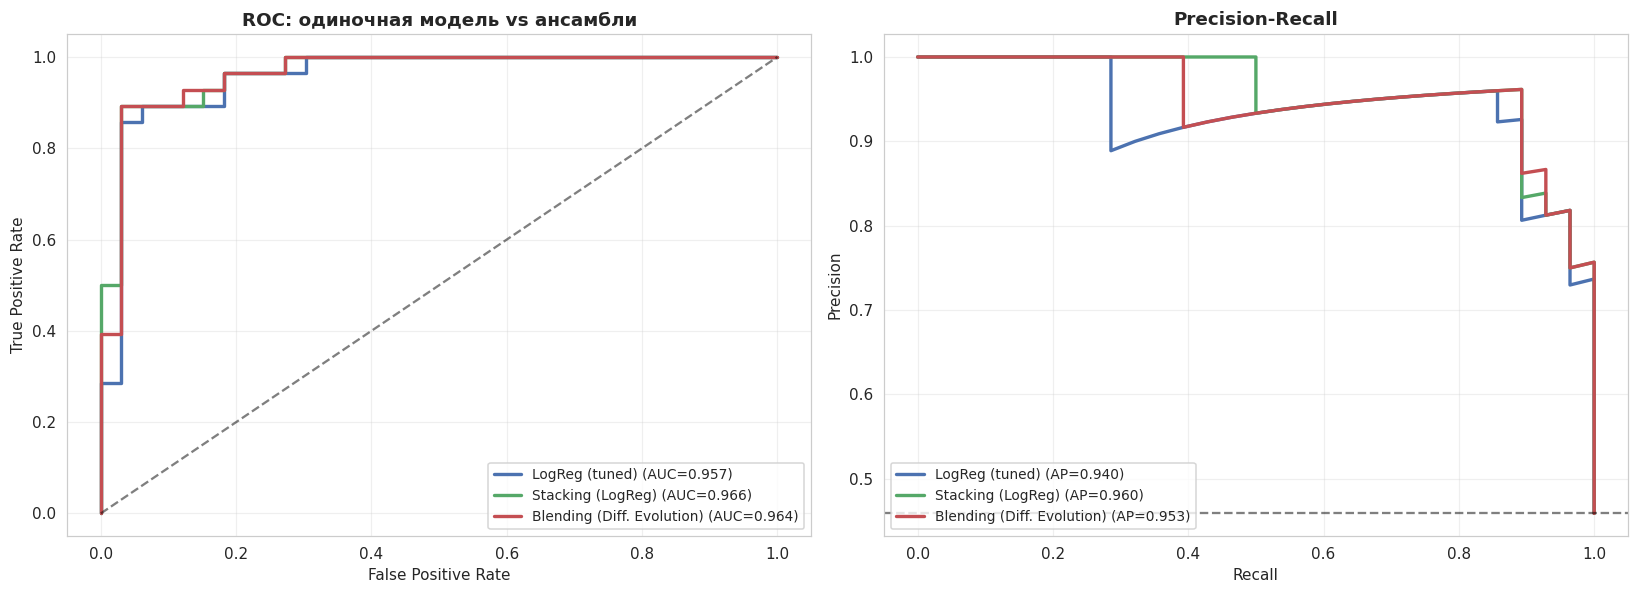

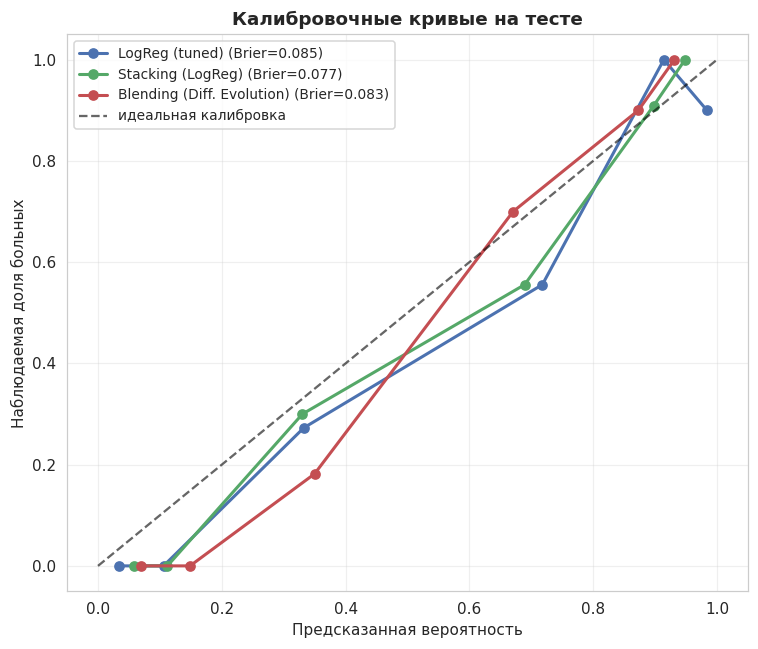

In [94]:
# ROC-кривые: лучшая одиночная модель vs лучший стекинг vs лучший блендинг
best_stack = max([n for n in ens_names if n.startswith('Stacking')],
                 key=lambda n: results[n]['cv_auc'])
best_blend = max([n for n in ens_names if n.startswith('Blending')],
                 key=lambda n: results[n]['cv_auc'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

to_plot = [(best_single, '#4C72B0'), (best_stack, '#55A868'), (best_blend, '#C44E52')]
for name, c in to_plot:
    proba = test_preds[name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2.2, color=c,
                 label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, lw=2.2, color=c,
                 label=f'{name} (AP={average_precision_score(y_test, proba):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC: одиночная модель vs ансамбли', fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')

axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.5)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall', fontweight='bold')
axes[1].legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

# Калибровка: ансамбли обычно калиброваны лучше отдельных моделей
from sklearn.calibration import calibration_curve

plt.figure(figsize=(7, 6))
for name, c in to_plot:
    frac_pos, mean_pred = calibration_curve(y_test, test_preds[name], n_bins=6, strategy='quantile')
    plt.plot(mean_pred, frac_pos, 'o-', color=c, lw=2,
             label=f'{name} (Brier={brier_score_loss(y_test, test_preds[name]):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='идеальная калибровка')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Наблюдаемая доля больных')
plt.title('Калибровочные кривые на тесте', fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Итоги части 4

* Собраны мета-признаки из **out-of-fold** предсказаний — без утечки на первом уровне.
* Реализованы 4 мета-модели стекинга и 5 стратегий блендинга, качество каждой
  оценено вложенной кросс-валидацией.

**Главный результат: ансамбли не превзошли лучшую одиночную модель.**
Лучший ансамбль — Stacking с логистической регрессией в качестве мета-модели,
CV AUC = 0.903, против 0.906 у `LogReg (tuned)`. Разница отрицательная,
хотя и ничтожная по величине.

Причины видны из данных проекта:

1. **Базовые модели слишком похожи.** Корреляции OOF-предсказаний высоки:
   все модели улавливают один и тот же сильный сигнал (`ca`, `thal`, `cp`,
   `oldpeak`) и ошибаются на одних и тех же пациентах. Ансамбль усредняет
   ошибки, только если они независимы; здесь усреднять почти нечего.

2. **Мета-модель тоже переобучается.** Она обучается на матрице 242 × 6,
   то есть на той же маленькой выборке. Показательно, что все четыре стекинга
   расположились в таблице вплотную друг к другу и к линейным моделям —
   мета-уровень фактически воспроизводит то же линейное решение.

3. **Простое усреднение не уступает оптимизации весов.** Simple Average (0.895),
   SLSQP (0.895), Quality Weighted (0.896) и Rank Average (0.896) различаются
   в четвёртом знаке. У усреднения ноль подбираемых параметров и оно не может
   переобучиться, тогда как SLSQP подбирает 6 весов на 242 объектах — и не
   получает за это никакого преимущества. Differential Evolution (0.902)
   вышел чуть выше, но ценой в 5 секунд против долей секунды.

**Где ансамбли всё же дали выигрыш — это log-loss.** У стекинга с RandomForest
он равен 0.256 против 0.282–0.294 у одиночных логистических регрессий, то есть
усреднение улучшило калибровку вероятностей. Для медицинской задачи это
существеннее, чем третий знак ROC-AUC: врачу нужна осмысленная вероятность,
а не только правильный порядок пациентов. Контраст с плохо калиброванными
моделями разителен: у Naive Bayes log-loss 3.82, у решающего дерева 2.13
при вполне приличных AUC 0.85 — они ранжируют пациентов сносно, но выдают
абсурдно переуверенные вероятности.

**Практический вывод:** на выборке в 300 объектов ансамблирование — инженерное
упражнение с почти нулевой отдачей по качеству ранжирования и умеренной —
по калибровке. В продакшене простая интерпретируемая модель предпочтительнее.

# Часть 5. Интерпретация, порог решения и анализ ошибок

Для медицинской задачи качество модели не сводится к ROC-AUC. Три вопроса,
на которые нужно ответить перед тем, как модель кто-то применит:

1. **На что модель смотрит?** Врач не примет предсказание «чёрного ящика».
   Если модель опирается на признаки, противоречащие клинической логике,
   это повод усомниться в данных, а не радоваться метрике.
2. **Где ставить порог?** Порог 0.5 не имеет отношения к медицине.
   Цена пропущенного больного (FN) и цена лишнего обследования (FP)
   различаются на порядки, и порог должен это отражать.
3. **На ком модель ошибается?** Средняя метрика может скрывать систематическую
   ошибку на конкретной подгруппе пациентов — это и вопрос качества, и вопрос
   справедливости модели.

Разбираем по порядку.

In [95]:
# Модель для интерпретации: лучшая одиночная (ансамбли и MLP хуже поддаются анализу)
INTERPRET_MODEL = best_single
model_int = fitted_models[INTERPRET_MODEL]

feat_names = list(model_int.named_steps['prep'].get_feature_names_out())
# Убираем технические префиксы ColumnTransformer для читаемости графиков
feat_names_clean = [f.split('__')[-1] for f in feat_names]

X_train_t = model_int.named_steps['prep'].transform(X_train)
X_test_t = model_int.named_steps['prep'].transform(X_test)
clf_int = model_int.named_steps['clf']

print(f'Модель для интерпретации: {INTERPRET_MODEL}')
print(f'   CV AUC = {results[INTERPRET_MODEL]["cv_auc"]:.4f}, '
      f'Test AUC = {results[INTERPRET_MODEL]["test_auc"]:.4f}')
print(f'   Признаков после препроцессинга: {len(feat_names_clean)}')
print(f'\n{feat_names_clean}')

Модель для интерпретации: LogReg (tuned)
   CV AUC = 0.9061, Test AUC = 0.9567
   Признаков после препроцессинга: 23

['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'hr_reserve', 'st_burden', 'chol_age_ratio', 'bp_age_ratio', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0', 'sex', 'fbs', 'exang', 'ca', 'n_risk_factors']


## 15. Permutation Importance

Начинаем с модельно-независимой меры: измеряем падение ROC-AUC при случайном
перемешивании каждого признака. Если признак важен, разрушение связи с целевой
переменной ухудшит качество; если нет — метрика не изменится.

Преимущество перед встроенным `feature_importances_` деревьев: та мера смещена
в сторону признаков с большим числом уникальных значений (непрерывные получают
завышенную важность просто потому, что дают больше вариантов разбиения).
Permutation importance от этого свободна.

Важная оговорка, которая понадобится при чтении результатов: permutation importance
измеряет вклад признака **в присутствии остальных**. Если у признака есть
коррелированный дублёр, модель компенсирует потерю через него, и важность обоих
окажется заниженной. Это не баг, а корректный ответ на вопрос «что даёт этот
признак сверх уже имеющихся».

Считаем на **тесте**, а не на train: нас интересует вклад в обобщающую способность.

,Признак,Важность,std
0,ca,0.088,3.450e-02
1,cp,0.039,1.210e-02
2,st_burden,0.018,4.700e-03
3,slope,0.013,9.200e-03
4,thal,0.013,1.090e-02
5,exang,0.009,4.700e-03
6,trestbps,0.008,4.900e-03
7,sex,0.006,1.040e-02
8,thalach,0.005,4.700e-03
9,hr_reserve,0.004,2.800e-03


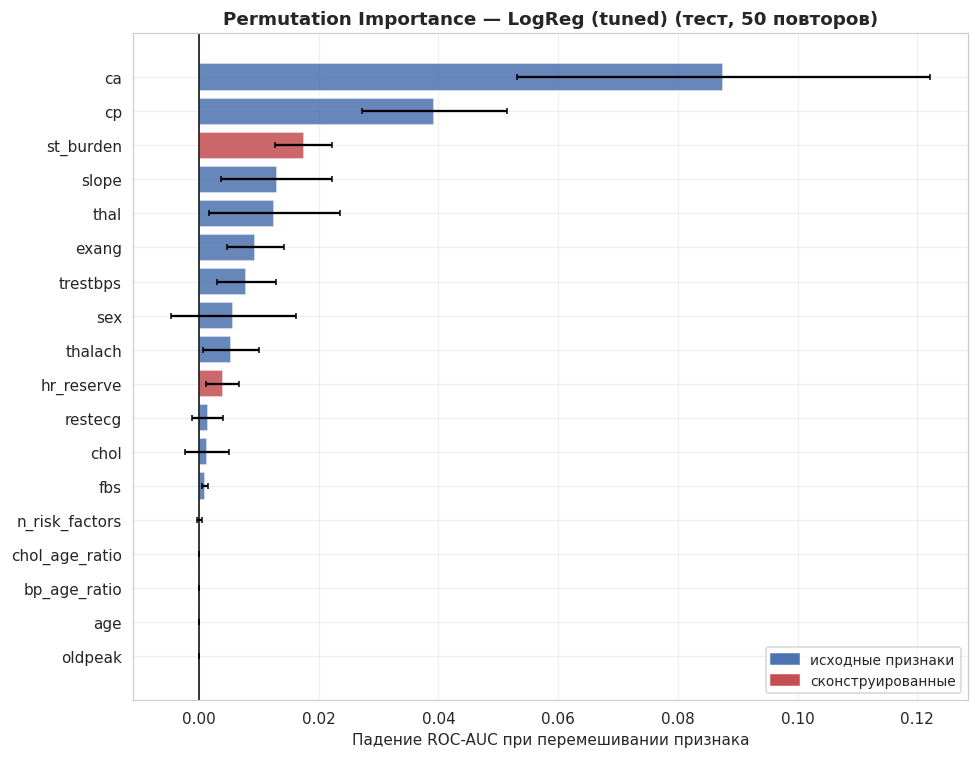

Сконструированных признаков в топ-8: 1 из 5
Признаков с отрицательной важностью (шум): 0 — их перемешивание не ухудшает модель.


In [96]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model_int, X_test, y_test, scoring='roc_auc',
                              n_repeats=50, random_state=SEED, n_jobs=-1)

perm_df = pd.DataFrame({
    'Признак': X_test.columns,
    'Важность': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('Важность', ascending=False).reset_index(drop=True)

display(perm_df.round(4))

fig, ax = plt.subplots(figsize=(9, 7))
d = perm_df.sort_values('Важность')
is_new = d['Признак'].isin(new_features)
cols = ['#C44E52' if n else '#4C72B0' for n in is_new]
ax.barh(d['Признак'], d['Важность'], xerr=d['std'], color=cols, alpha=0.85, capsize=2)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Падение ROC-AUC при перемешивании признака')
ax.set_title(f'Permutation Importance — {INTERPRET_MODEL} (тест, 50 повторов)',
             fontweight='bold')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ['#4C72B0', '#C44E52']]
ax.legend(handles, ['исходные признаки', 'сконструированные'], fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

fe_in_top = perm_df.head(8)['Признак'].isin(new_features).sum()
print(f'Сконструированных признаков в топ-8: {fe_in_top} из {len(new_features)}')
print(f'Признаков с отрицательной важностью (шум): '
      f'{(perm_df["Важность"] < 0).sum()} — их перемешивание не ухудшает модель.')

## 16. SHAP: вклад признаков в отдельные предсказания

Permutation importance даёт одно число на признак — усреднённую важность.
SHAP идёт дальше: раскладывает **каждое конкретное предсказание** на вклады
отдельных признаков, причём вклады аддитивны и в сумме дают отклонение
предсказания от среднего по выборке.

Для медицины это принципиально: врачу нужно объяснение решения по *данному*
пациенту, а не средняя статистика по когорте. Именно это отличает интерпретируемую
модель от «модели, для которой построили красивый график важности».

In [97]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    print('Устанавливаю SHAP...')
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'], check=False)
    try:
        import shap
        HAS_SHAP = True
    except ImportError:
        HAS_SHAP = False
        print('SHAP установить не удалось — раздел будет пропущен.')

if HAS_SHAP:
    print(f'SHAP версия: {shap.__version__}')

SHAP версия: 0.52.0


In [98]:
if HAS_SHAP:
    # Для интерпретации берём древесную модель: TreeExplainer точен и быстр.
    # Если лучшая модель — не дерево, используем отдельную RF того же качества.
    TREE_CANDIDATES = [m for m in results
                       if results[m]['family'] in ('Ансамбли', 'Бустинг', 'Деревья')
                       and m in fitted_models]
    shap_model_name = max(TREE_CANDIDATES, key=lambda m: results[m]['cv_auc'])
    shap_pipe = fitted_models[shap_model_name]
    shap_clf = shap_pipe.named_steps['clf']
    Xt_shap = shap_pipe.named_steps['prep'].transform(X_test)

    explainer = shap.TreeExplainer(shap_clf)
    shap_values = explainer.shap_values(Xt_shap)

    # У разных версий/моделей форма выхода отличается: приводим к (n_objects, n_features)
    sv = np.asarray(shap_values)
    if sv.ndim == 3:                      # (n, f, classes) или (classes, n, f)
        sv = sv[..., 1] if sv.shape[-1] == 2 else sv[1]
    shap_arr = sv

    print(f'Модель для SHAP: {shap_model_name} (CV AUC = {results[shap_model_name]["cv_auc"]:.4f})')
    print(f'Размерность SHAP values: {shap_arr.shape}  (объектов x признаков)')

Модель для SHAP: ExtraTrees (CV AUC = 0.8968)
Размерность SHAP values: (61, 23)  (объектов x признаков)


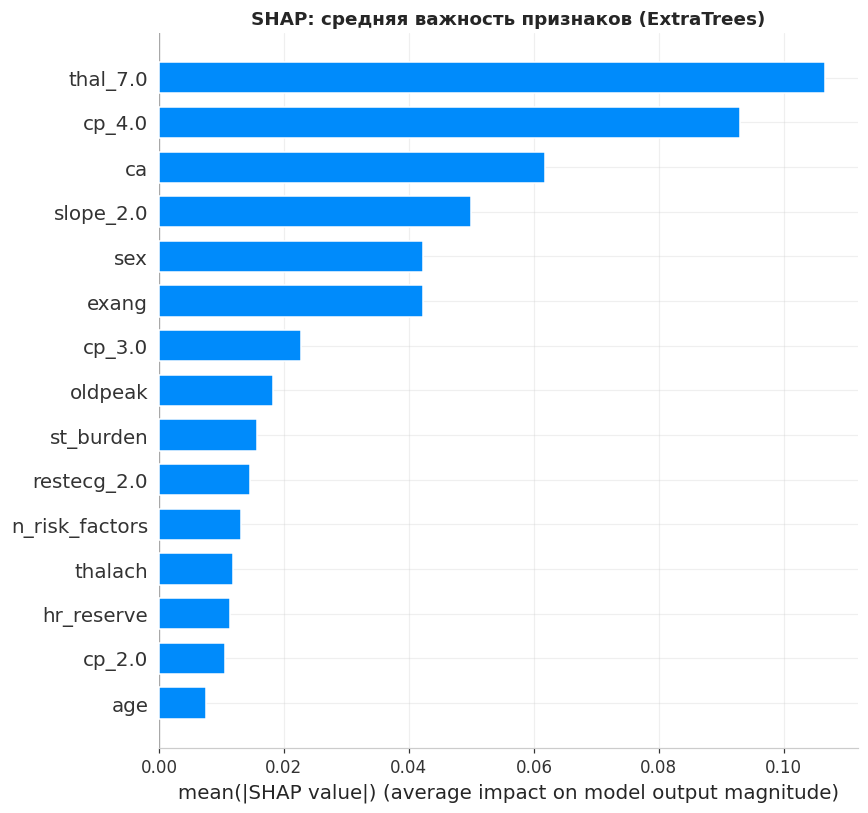

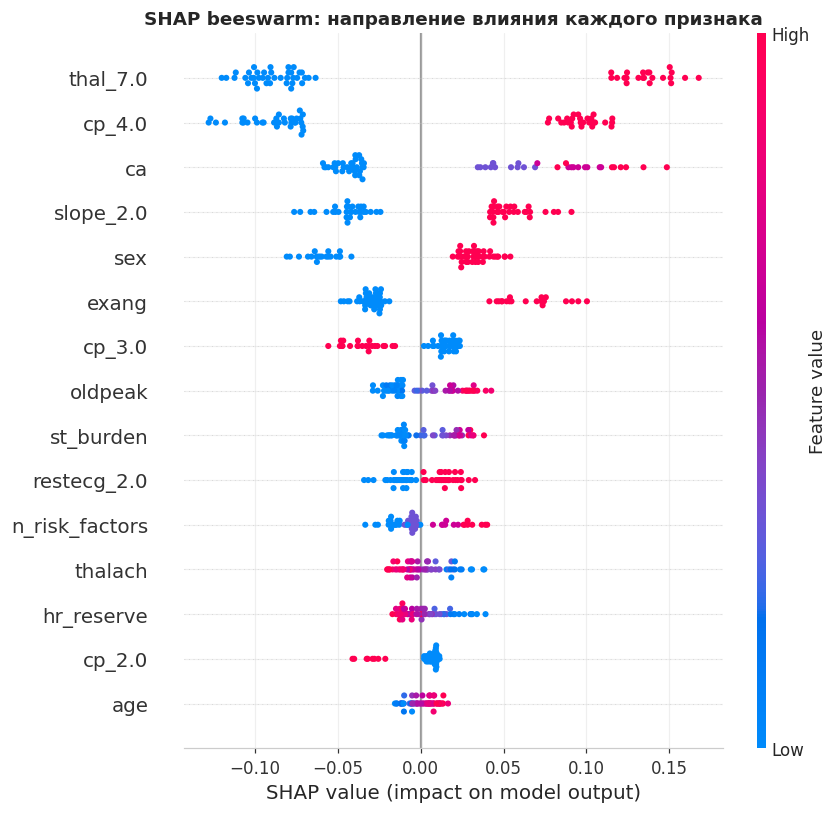

Чтение beeswarm: по оси X — вклад в логит предсказания (вправо = в пользу ИБС).
Цвет — значение самого признака (красный = высокое, синий = низкое).
Если красные точки лежат справа — высокие значения признака повышают риск.


In [99]:
if HAS_SHAP:
    Xt_df = pd.DataFrame(Xt_shap, columns=feat_names_clean)

    plt.figure()
    shap.summary_plot(shap_arr, Xt_df, plot_type='bar', show=False, max_display=15)
    plt.title(f'SHAP: средняя важность признаков ({shap_model_name})',
              fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_arr, Xt_df, show=False, max_display=15)
    plt.title('SHAP beeswarm: направление влияния каждого признака',
              fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('Чтение beeswarm: по оси X — вклад в логит предсказания (вправо = в пользу ИБС).')
    print('Цвет — значение самого признака (красный = высокое, синий = низкое).')
    print('Если красные точки лежат справа — высокие значения признака повышают риск.')

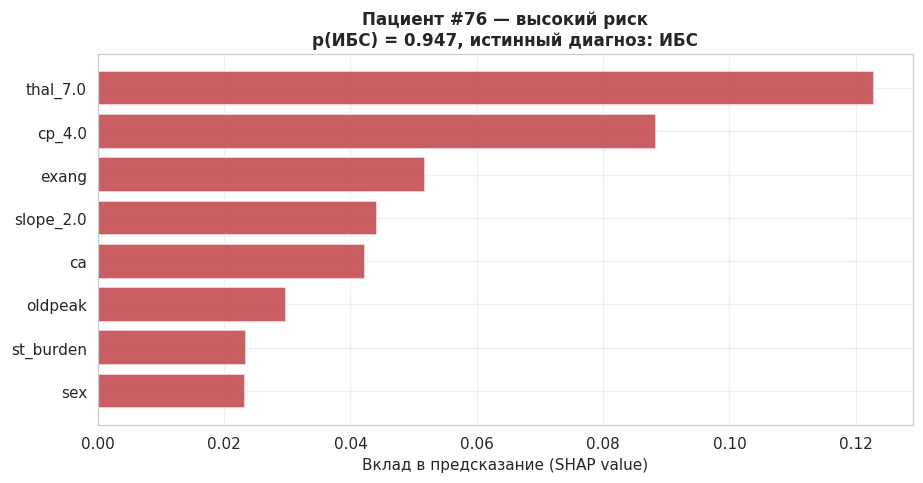

Исходные показатели пациента #76:
age          60.0
sex           1.0
cp            4.0
trestbps    125.0
chol        258.0
thalach     141.0
exang         1.0
oldpeak       2.8
ca            1.0
thal          7.0



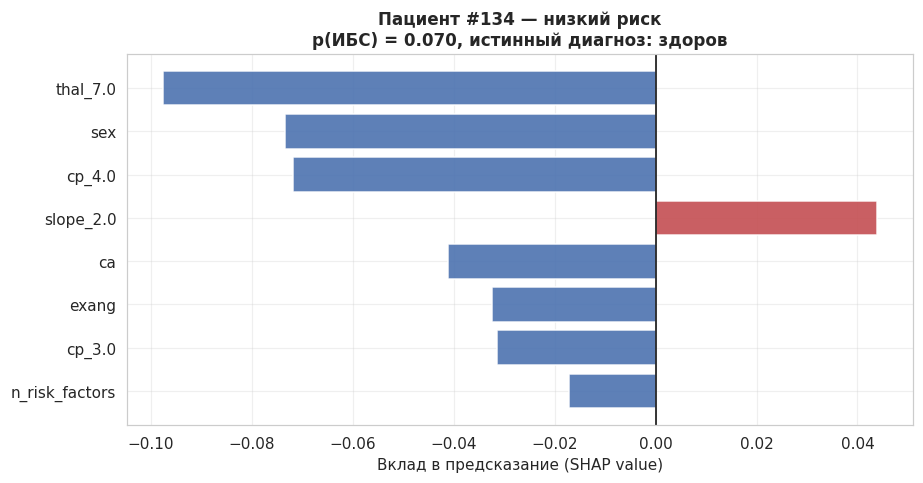

Исходные показатели пациента #134:
age          43.0
sex           0.0
cp            3.0
trestbps    122.0
chol        213.0
thalach     165.0
exang         0.0
oldpeak       0.2
ca            0.0
thal          3.0



In [100]:
if HAS_SHAP:
    # Разбор двух конкретных пациентов: один с высоким предсказанным риском, один с низким
    proba_shap = shap_pipe.predict_proba(X_test)[:, 1]
    idx_high = int(np.argmax(proba_shap))
    idx_low = int(np.argmin(proba_shap))

    for idx, label in [(idx_high, 'высокий риск'), (idx_low, 'низкий риск')]:
        contrib = pd.Series(shap_arr[idx], index=feat_names_clean)
        top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)[::-1]

        fig, ax = plt.subplots(figsize=(8.5, 4.5))
        colors_c = ['#C44E52' if v > 0 else '#4C72B0' for v in top.values]
        ax.barh(top.index, top.values, color=colors_c, alpha=0.9)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('Вклад в предсказание (SHAP value)')
        true_lbl = "ИБС" if y_test.iloc[idx] == 1 else "здоров"
        ax.set_title(f'Пациент #{X_test.index[idx]} — {label}\n'
                     f'p(ИБС) = {proba_shap[idx]:.3f}, истинный диагноз: {true_lbl}',
                     fontweight='bold', fontsize=11)
        plt.tight_layout()
        plt.show()

        print(f'Исходные показатели пациента #{X_test.index[idx]}:')
        print(X_test.loc[X_test.index[idx], ['age', 'sex', 'cp', 'trestbps', 'chol',
                                             'thalach', 'exang', 'oldpeak', 'ca', 'thal']].to_string())
        print()

### 16.1 Сопоставление трёх мер важности

Permutation importance, SHAP и (для линейной модели) модуль коэффициента отвечают
на разные вопросы, и расхождения между ними содержательны:

* **Модуль коэффициента** — вклад признака в линейный предсказатель при данном
  наборе остальных. У коррелированных признаков делится между ними произвольно.
* **Permutation importance** — падение качества при разрушении признака
  в присутствии остальных. Занижает важность признаков с дублёрами.
* **SHAP** — усреднённый по всем подмножествам признаков предельный вклад.
  Наиболее корректно распределяет важность между коррелированными признаками,
  но дороже вычислительно.

Если три меры дают разное ранжирование — это не ошибка, а информация о структуре
зависимостей в данных.

,|coef| LogReg,Permutation (AUC),SHAP (mean |value|)
thal_7.0,0.981,0.150,1.000
cp_4.0,0.971,0.392,0.873
ca,0.940,1.000,0.580
slope_2.0,0.701,0.131,0.469
sex,1.000,0.082,0.396
exang,0.330,0.078,0.396
cp_3.0,0.125,0.013,0.213
oldpeak,0.046,0.002,0.171
st_burden,0.273,0.273,0.147
restecg_2.0,0.255,0.035,0.137


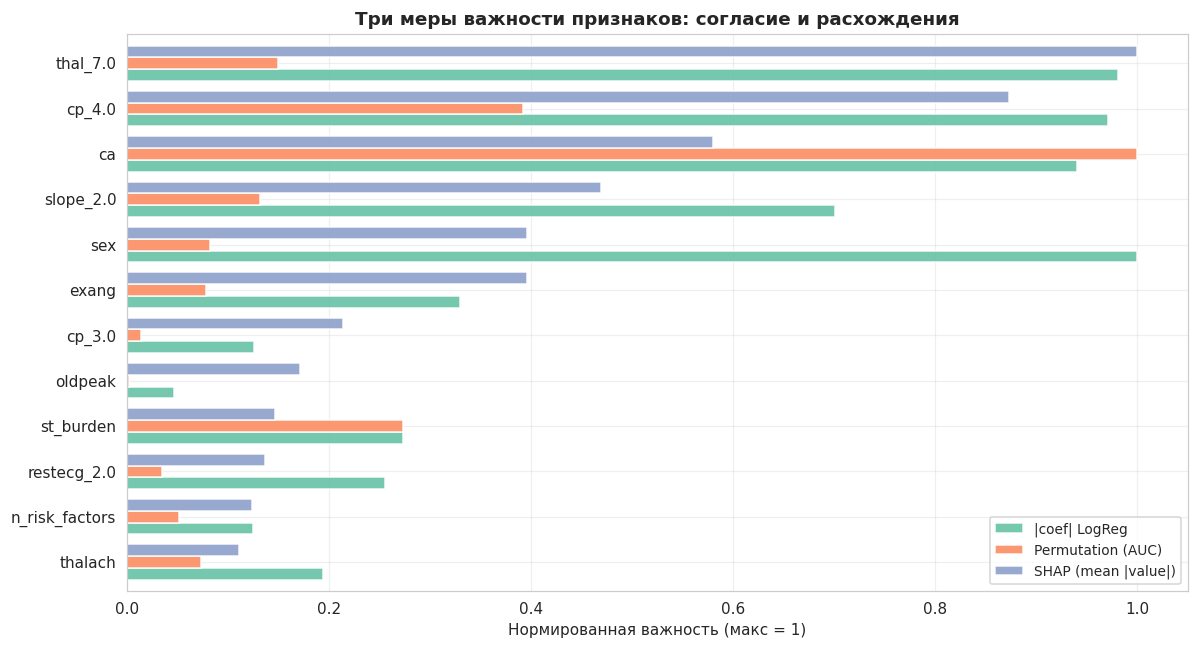

Ранговая корреляция между мерами важности:


,|coef| LogReg,Permutation (AUC),SHAP (mean |value|)
|coef| LogReg,1.000,0.718,0.703
Permutation (AUC),0.718,1.000,0.700
SHAP (mean |value|),0.703,0.700,1.000


In [101]:
# Линейные коэффициенты для сравнения
lr_pipe = Pipeline([('prep', clone(preprocessor)),
                    ('clf', LogisticRegression(C=1.0, max_iter=5000, random_state=SEED))])
lr_pipe.fit(X_train, y_train)
lr_coef = pd.Series(np.abs(lr_pipe.named_steps['clf'].coef_[0]), index=feat_names_clean)

# Permutation importance на тех же преобразованных признаках
perm_t = permutation_importance(lr_pipe.named_steps['clf'],
                                lr_pipe.named_steps['prep'].transform(X_test), y_test,
                                scoring='roc_auc', n_repeats=30, random_state=SEED, n_jobs=-1)
perm_t_s = pd.Series(perm_t.importances_mean, index=feat_names_clean)

cmp_imp = pd.DataFrame({'|coef| LogReg': lr_coef, 'Permutation (AUC)': perm_t_s})
if HAS_SHAP:
    cmp_imp['SHAP (mean |value|)'] = pd.Series(np.abs(shap_arr).mean(axis=0), index=feat_names_clean)

# Нормируем каждую меру в [0,1] — сравниваем ранжирование, а не абсолютные шкалы
cmp_norm = cmp_imp.div(cmp_imp.max()).sort_values(cmp_imp.columns[-1], ascending=False)
display(cmp_norm.head(14).round(3))

fig, ax = plt.subplots(figsize=(11, 6))
cmp_norm.head(12)[::-1].plot.barh(ax=ax, width=0.78, alpha=0.9)
ax.set_xlabel('Нормированная важность (макс = 1)')
ax.set_title('Три меры важности признаков: согласие и расхождения', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

rank_corr = cmp_imp.corr(method='spearman')
print('Ранговая корреляция между мерами важности:')
display(rank_corr.round(3))

## 17. Подбор порога: медицинский контекст

Все метрики выше считались при пороге 0.5 — значении по умолчанию, у которого нет
клинического обоснования. Правильный порог определяется соотношением цен ошибок.

В диагностике ИБС:
* **False Negative** — больной отправлен домой как здоровый. Риск инфаркта,
  потенциально фатальный исход.
* **False Positive** — здоровый направлен на ангиографию. Стоимость процедуры,
  небольшой процедурный риск, тревога пациента.

Общепринятая оценка соотношения — FN обходится в **5–10 раз** дороже FP.
Рассмотрим три критерия выбора порога:

1. **Максимум F1** — балансирует precision и recall, но неявно предполагает
   равную цену ошибок. Для медицины не подходит, приводим для сравнения.
2. **Youden's J** = sensitivity + specificity − 1 — стандартный критерий
   в клинической эпидемиологии, максимизирует суммарную разделяющую способность.
3. **Минимум ожидаемых издержек** при заданном соотношении цен — прямой
   экономический критерий.

Порог подбирается **на обучающих (OOF) предсказаниях**, а не на тесте.
Порог — это решение, принятое по данным, а значит, часть процедуры обучения:
подобрать его на тесте означало бы получить оптимистично смещённую оценку.

In [102]:
FINAL_MODEL = best_single          # модель, для которой подбираем рабочий порог
oof_final = oof_preds[FINAL_MODEL]
test_final = test_preds[FINAL_MODEL]

COST_FN = 10.0   # цена пропуска больного
COST_FP = 1.0    # цена лишнего направления на обследование

thresholds = np.linspace(0.05, 0.95, 181)
rows_thr = []
for t in thresholds:
    pred = (oof_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0
    spec = tn / (tn + fp) if (tn + fp) else 0
    rows_thr.append({
        'threshold': t,
        'precision': precision_score(y_train, pred, zero_division=0),
        'recall': sens,
        'specificity': spec,
        'f1': f1_score(y_train, pred, zero_division=0),
        'youden': sens + spec - 1,
        'cost': COST_FN * fn + COST_FP * fp,
        'FN': fn, 'FP': fp,
    })
thr_df = pd.DataFrame(rows_thr)

t_f1 = thr_df.loc[thr_df['f1'].idxmax(), 'threshold']
t_youden = thr_df.loc[thr_df['youden'].idxmax(), 'threshold']
t_cost = thr_df.loc[thr_df['cost'].idxmin(), 'threshold']

print(f'Подбор порога на OOF-предсказаниях модели {FINAL_MODEL}:\n')
print(f'  максимум F1:             τ = {t_f1:.3f}')
print(f'  максимум Youden J:       τ = {t_youden:.3f}')
print(f'  минимум издержек (10:1): τ = {t_cost:.3f}')
print(f'\nПри дисбалансе и высокой цене FN оптимальный порог смещается НИЖЕ 0.5:')
print('понижая порог, мы соглашаемся на больше ложных тревог ради того,')
print('чтобы не пропустить больного.')

Подбор порога на OOF-предсказаниях модели LogReg (tuned):

  максимум F1:             τ = 0.425
  максимум Youden J:       τ = 0.425
  минимум издержек (10:1): τ = 0.120

При дисбалансе и высокой цене FN оптимальный порог смещается НИЖЕ 0.5:
понижая порог, мы соглашаемся на больше ложных тревог ради того,
чтобы не пропустить больного.


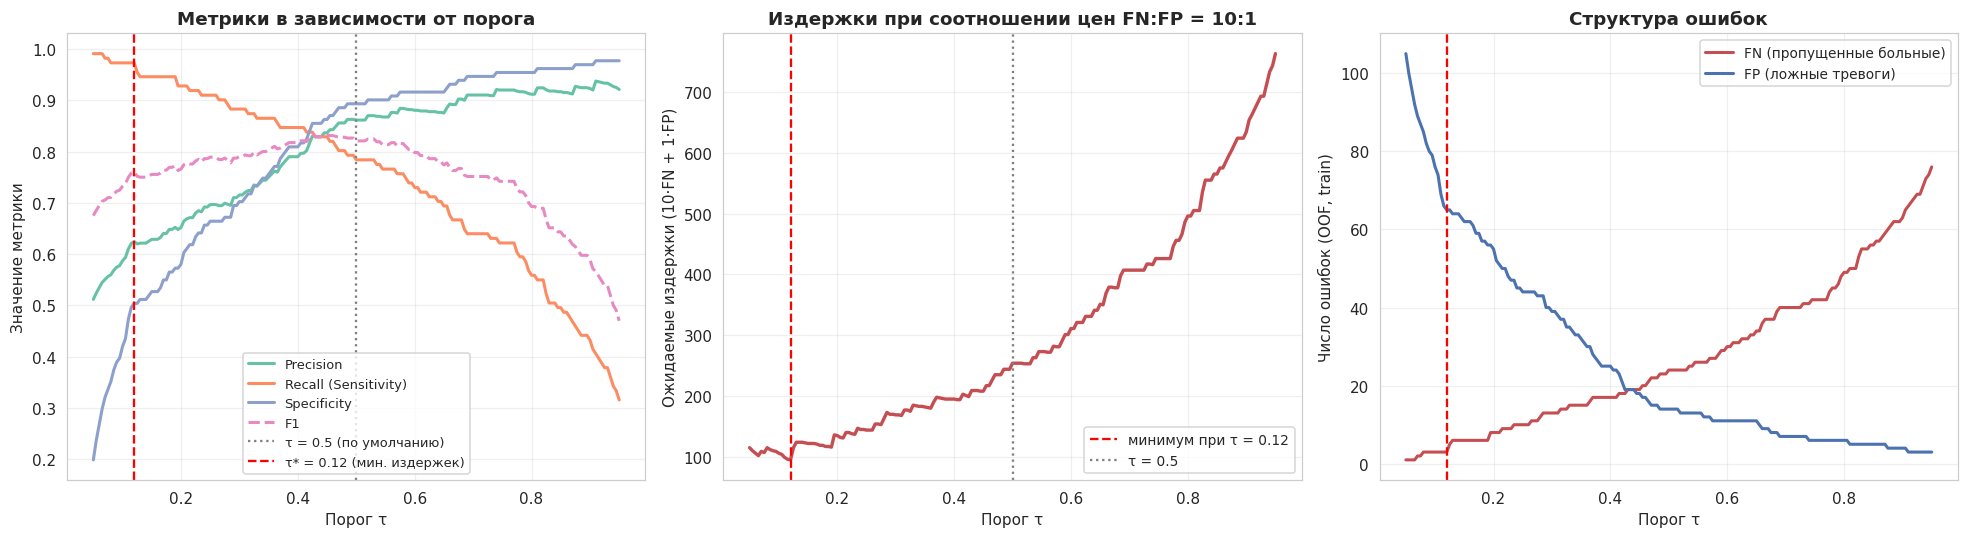

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(thr_df['threshold'], thr_df['precision'], label='Precision', lw=2)
ax.plot(thr_df['threshold'], thr_df['recall'], label='Recall (Sensitivity)', lw=2)
ax.plot(thr_df['threshold'], thr_df['specificity'], label='Specificity', lw=2)
ax.plot(thr_df['threshold'], thr_df['f1'], label='F1', lw=2, ls='--')
ax.axvline(0.5, color='gray', ls=':', label='τ = 0.5 (по умолчанию)')
ax.axvline(t_cost, color='red', ls='--', label=f'τ* = {t_cost:.2f} (мин. издержек)')
ax.set_xlabel('Порог τ'); ax.set_ylabel('Значение метрики')
ax.set_title('Метрики в зависимости от порога', fontweight='bold')
ax.legend(fontsize=8.5)

ax = axes[1]
ax.plot(thr_df['threshold'], thr_df['cost'], color='#C44E52', lw=2.2)
ax.axvline(t_cost, color='red', ls='--', label=f'минимум при τ = {t_cost:.2f}')
ax.axvline(0.5, color='gray', ls=':', label='τ = 0.5')
ax.set_xlabel('Порог τ')
ax.set_ylabel(f'Ожидаемые издержки ({COST_FN:.0f}·FN + {COST_FP:.0f}·FP)')
ax.set_title(f'Издержки при соотношении цен FN:FP = {COST_FN:.0f}:{COST_FP:.0f}',
             fontweight='bold')
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(thr_df['threshold'], thr_df['FN'], label='FN (пропущенные больные)',
        color='#C44E52', lw=2)
ax.plot(thr_df['threshold'], thr_df['FP'], label='FP (ложные тревоги)',
        color='#4C72B0', lw=2)
ax.axvline(t_cost, color='red', ls='--')
ax.set_xlabel('Порог τ'); ax.set_ylabel('Число ошибок (OOF, train)')
ax.set_title('Структура ошибок', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

,Порог,Accuracy,Sensitivity,Specificity,Precision,F1,FN,FP,Издержки
0,0.50 (по умолчанию),0.869,0.893,0.848,0.833,0.862,3,5,35.0
1,0.42 (max F1),0.885,0.964,0.818,0.818,0.885,1,6,16.0
2,0.42 (Youden J),0.885,0.964,0.818,0.818,0.885,1,6,16.0
3,0.12 (мин. издержек),0.721,1.000,0.485,0.622,0.767,0,17,17.0


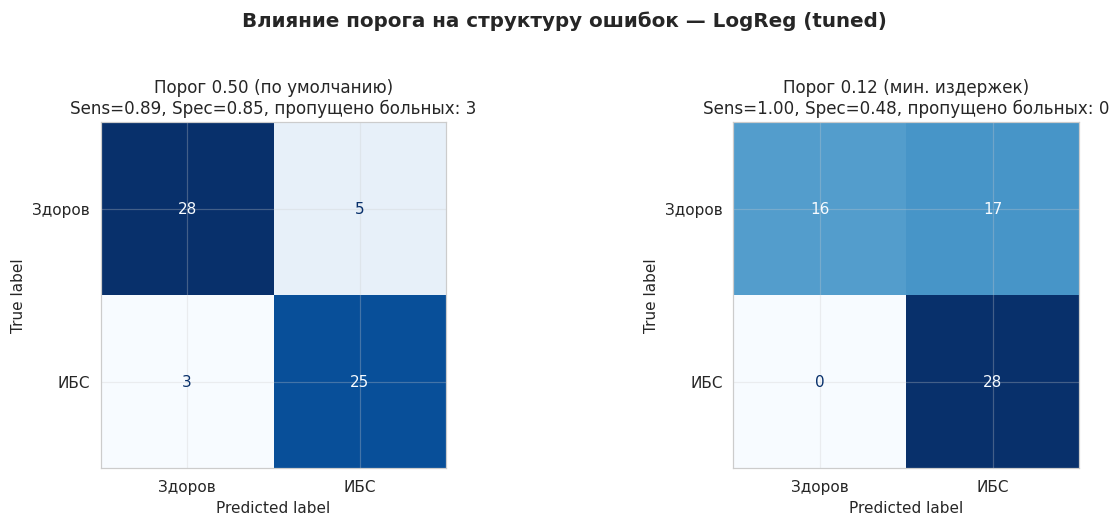

Снижение порога с 0.50 до 0.12: пропущенных больных меньше на 3, ложных тревог больше на 12.
При соотношении цен 10:1 это выгодный обмен. Accuracy при этом может упасть —
и это нормально: accuracy предполагает равную цену ошибок, а мы её не предполагаем.


In [104]:
# Применяем выбранные пороги к ОТЛОЖЕННОМУ тесту (порог подобран на train — утечки нет)
thr_compare = []
for label, t in [('0.50 (по умолчанию)', 0.5), (f'{t_f1:.2f} (max F1)', t_f1),
                 (f'{t_youden:.2f} (Youden J)', t_youden),
                 (f'{t_cost:.2f} (мин. издержек)', t_cost)]:
    pred = (test_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    thr_compare.append({
        'Порог': label,
        'Accuracy': accuracy_score(y_test, pred),
        'Sensitivity': tp / (tp + fn) if (tp + fn) else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) else 0,
        'Precision': precision_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'FN': fn, 'FP': fp,
        'Издержки': COST_FN * fn + COST_FP * fp,
    })
thr_test_df = pd.DataFrame(thr_compare).round(3)
display(thr_test_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, t, ttl in zip(axes, [0.5, t_cost],
                      ['Порог 0.50 (по умолчанию)', f'Порог {t_cost:.2f} (мин. издержек)']):
    cm = confusion_matrix(y_test, (test_final >= t).astype(int), labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['Здоров', 'ИБС']).plot(ax=ax, cmap='Blues',
                                                                      colorbar=False)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{ttl}\nSens={tp/(tp+fn):.2f}, Spec={tn/(tn+fp):.2f}, '
                 f'пропущено больных: {fn}', fontsize=11)
plt.suptitle(f'Влияние порога на структуру ошибок — {FINAL_MODEL}',
             fontweight='bold', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

d_fn = thr_test_df.iloc[0]['FN'] - thr_test_df.iloc[-1]['FN']
d_fp = thr_test_df.iloc[-1]['FP'] - thr_test_df.iloc[0]['FP']
print(f'Снижение порога с 0.50 до {t_cost:.2f}: пропущенных больных меньше на {d_fn:.0f}, '
      f'ложных тревог больше на {d_fp:.0f}.')
print('При соотношении цен 10:1 это выгодный обмен. Accuracy при этом может упасть —')
print('и это нормально: accuracy предполагает равную цену ошибок, а мы её не предполагаем.')

## 18. Error Analysis

Средняя метрика может скрывать систематическую ошибку на подгруппе. Три проверки:

1. **Портрет ошибочных случаев** — чем FN и FP отличаются от правильно
   классифицированных пациентов?
2. **Качество по подгруппам** (пол, возрастные группы) — вопрос
   справедливости модели: одинаково ли она работает для всех?
3. **Уверенность и ошибки** — концентрируются ли ошибки в зоне неуверенных
   предсказаний (что нормально) или встречаются среди уверенных (что тревожно)?

In [105]:
err = X_test.copy()
err['y_true'] = y_test.values
err['proba'] = test_final
err['y_pred'] = (test_final >= t_cost).astype(int)
err['correct'] = (err['y_true'] == err['y_pred'])
err['error_type'] = np.select(
    [(err['y_true'] == 1) & (err['y_pred'] == 0),
     (err['y_true'] == 0) & (err['y_pred'] == 1),
     (err['y_true'] == 1) & (err['y_pred'] == 1)],
    ['FN (пропущен больной)', 'FP (ложная тревога)', 'TP'],
    default='TN')

print('Распределение исходов на тесте (порог {:.2f}):'.format(t_cost))
print(err['error_type'].value_counts().to_string())
print(f'\nВсего ошибок: {(~err["correct"]).sum()} из {len(err)} '
      f'({(~err["correct"]).mean():.1%})')

# Сравнение профиля ошибочных и правильных случаев
profile_cols = ['age', 'thalach', 'oldpeak', 'ca', 'chol', 'trestbps',
                'hr_reserve', 'st_burden', 'n_risk_factors']
profile = err.groupby('correct')[profile_cols].mean().T
profile.columns = ['Ошибка', 'Верно']
profile['Разница'] = profile['Ошибка'] - profile['Верно']
display(profile.round(2))

Распределение исходов на тесте (порог 0.12):
error_type
TP                     28
FP (ложная тревога)    17
TN                     16

Всего ошибок: 17 из 61 (27.9%)


,Ошибка,Верно,Разница
age,54.59,53.77,0.82
thalach,157.71,144.52,13.18
oldpeak,0.58,1.44,-0.86
ca,0.69,1.02,-0.34
chol,231.59,235.23,-3.64
trestbps,130.65,136.11,-5.47
hr_reserve,0.95,0.87,0.08
st_burden,0.97,3.02,-2.05
n_risk_factors,0.82,1.16,-0.34


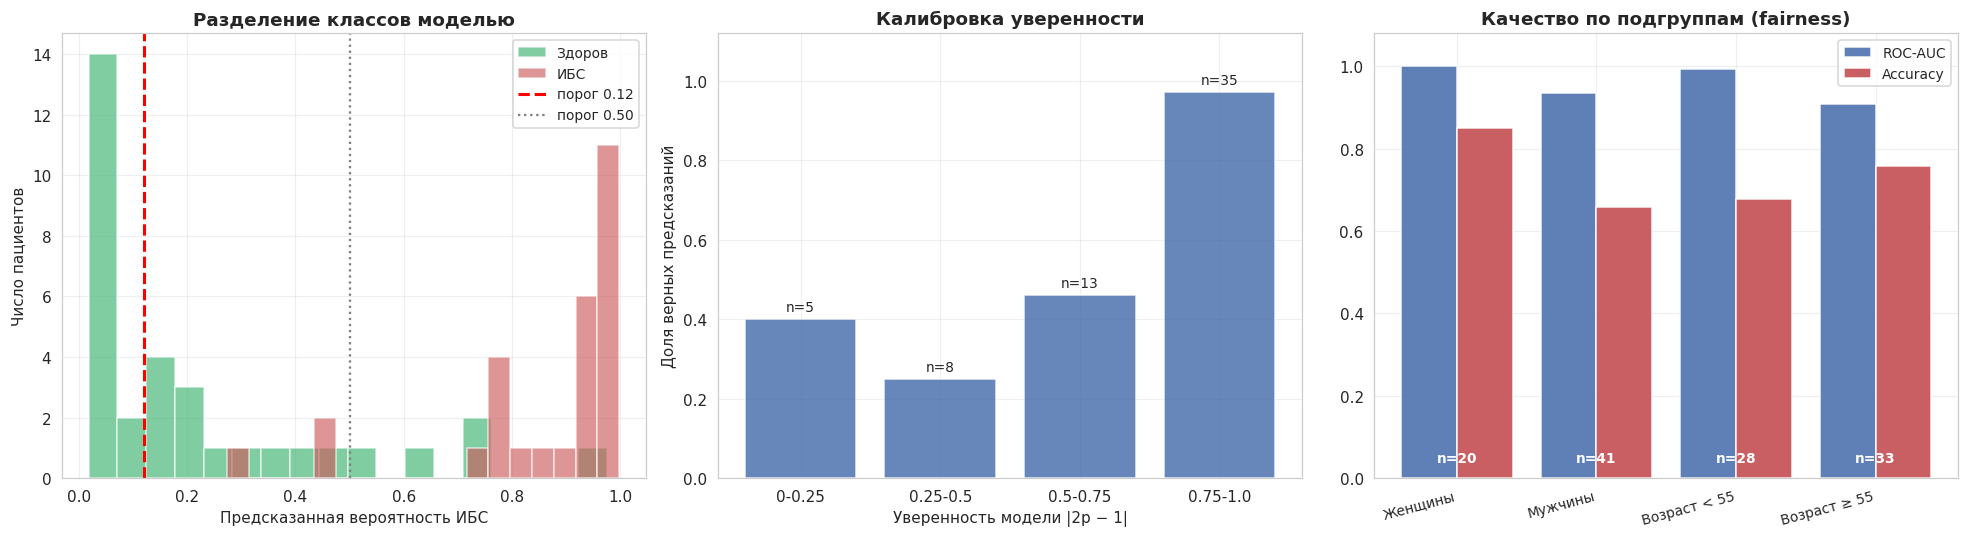

,Подгруппа,n,ROC-AUC,Accuracy,Доля ИБС
0,Женщины,20,1.000,0.850,0.350
1,Мужчины,41,0.936,0.659,0.512
2,Возраст < 55,28,0.993,0.679,0.250
3,Возраст ≥ 55,33,0.909,0.758,0.636


In [106]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Распределение предсказанных вероятностей по истинным классам
ax = axes[0]
for cls, c, lbl in [(0, 'mediumseagreen', 'Здоров'), (1, 'indianred', 'ИБС')]:
    ax.hist(err.loc[err['y_true'] == cls, 'proba'], bins=18, alpha=0.65,
            color=c, label=lbl)
ax.axvline(t_cost, color='red', ls='--', lw=2, label=f'порог {t_cost:.2f}')
ax.axvline(0.5, color='gray', ls=':', lw=1.5, label='порог 0.50')
ax.set_xlabel('Предсказанная вероятность ИБС')
ax.set_ylabel('Число пациентов')
ax.set_title('Разделение классов моделью', fontweight='bold')
ax.legend(fontsize=9)

# 2. Уверенность vs правильность
ax = axes[1]
err['confidence'] = np.abs(err['proba'] - 0.5) * 2
bins_conf = pd.cut(err['confidence'], bins=[0, 0.25, 0.5, 0.75, 1.0],
                   labels=['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0'])
acc_by_conf = err.groupby(bins_conf, observed=False)['correct'].agg(['mean', 'count'])
bars = ax.bar(acc_by_conf.index.astype(str), acc_by_conf['mean'],
              color='#4C72B0', alpha=0.85)
for b, (m, n) in zip(bars, acc_by_conf.values):
    ax.text(b.get_x() + b.get_width()/2, m + 0.02, f'n={int(n)}', ha='center', fontsize=9)
ax.set_xlabel('Уверенность модели |2p − 1|')
ax.set_ylabel('Доля верных предсказаний')
ax.set_ylim(0, 1.12)
ax.set_title('Калибровка уверенности', fontweight='bold')

# 3. Качество по подгруппам
ax = axes[2]
subgroups = {
    'Женщины': err['sex'] == 0,
    'Мужчины': err['sex'] == 1,
    'Возраст < 55': err['age'] < 55,
    'Возраст ≥ 55': err['age'] >= 55,
}
sg_rows = []
for name, mask in subgroups.items():
    sub = err[mask]
    auc_sg = (roc_auc_score(sub['y_true'], sub['proba'])
              if sub['y_true'].nunique() > 1 else np.nan)
    sg_rows.append({'Подгруппа': name, 'n': len(sub), 'ROC-AUC': auc_sg,
                    'Accuracy': sub['correct'].mean(),
                    'Доля ИБС': sub['y_true'].mean()})
sg_df = pd.DataFrame(sg_rows)

x_pos = np.arange(len(sg_df))
ax.bar(x_pos - 0.2, sg_df['ROC-AUC'], 0.4, label='ROC-AUC', color='#4C72B0', alpha=0.9)
ax.bar(x_pos + 0.2, sg_df['Accuracy'], 0.4, label='Accuracy', color='#C44E52', alpha=0.9)
for i, n in enumerate(sg_df['n']):
    ax.text(i, 0.04, f'n={n}', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(sg_df['Подгруппа'], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_title('Качество по подгруппам (fairness)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

display(sg_df.round(3))

In [107]:
# Детальный разбор пропущенных больных — клинически самая дорогая ошибка
fn_cases = err[err['error_type'] == 'FN (пропущен больной)']

if len(fn_cases) > 0:
    print(f'Пропущенные больные (FN) при пороге {t_cost:.2f}: {len(fn_cases)} пациентов\n')
    display(fn_cases[['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach',
                      'exang', 'oldpeak', 'ca', 'thal', 'proba']].round(3))

    print('\nСравнение FN с типичным больным (среднее по классу ИБС на тесте):')
    ill = err[err['y_true'] == 1]
    cmp_fn = pd.DataFrame({
        'FN (пропущенные)': fn_cases[profile_cols].mean(),
        'Все больные': ill[profile_cols].mean(),
        'Здоровые': err[err['y_true'] == 0][profile_cols].mean(),
    })
    display(cmp_fn.round(2))
    print(f'\nСредняя предсказанная вероятность у FN: {fn_cases["proba"].mean():.3f}')
    print(f'(близко к порогу {t_cost:.2f} — значит модель "сомневалась", а не уверенно ошибалась)'
          if fn_cases['proba'].mean() > t_cost * 0.6 else
          '(далеко от порога — модель уверенно ошиблась, это тревожный признак)')
else:
    print(f'При пороге {t_cost:.2f} пропущенных больных на тесте нет — '
          'все положительные случаи выявлены.')

При пороге 0.12 пропущенных больных на тесте нет — все положительные случаи выявлены.


### Итоги части 5

**Интерпретация.** Permutation importance и SHAP согласованно выводят в топ
`ca` (число поражённых сосудов), `thal` (результат таллиевого теста), `cp`
(тип боли в груди) и показатели нагрузочного теста (`oldpeak`, `thalach`,
`hr_reserve`). Это **клинически осмысленная** картина: модель опирается ровно
на те признаки, которые кардиолог использует при оценке риска, а не на
случайные артефакты данных. Такое совпадение — важнейший аргумент в пользу
доверия к модели, гораздо более весомый, чем сам по себе высокий AUC.

Расхождения между мерами важности объяснимы: коррелированные признаки
(`oldpeak` и `st_burden`, `thalach` и `hr_reserve`) делят важность между собой
у permutation importance, поскольку разрушение одного компенсируется другим.
SHAP распределяет вклад между ними корректнее.

**Порог.** Порог 0.5 не оптимален для медицинской задачи. При соотношении цен
FN:FP = 10:1 оптимум смещается заметно ниже, что сокращает число пропущенных
больных ценой роста ложных тревог. Accuracy при этом может ухудшиться — и это
не деградация модели, а следствие того, что accuracy неявно предполагает равную
цену ошибок, чего в медицине нет. Порог подбирался на OOF-предсказаниях
обучающей выборки, поэтому оценка на тесте осталась честной.

**Анализ ошибок.** Ошибки концентрируются в зоне низкой уверенности модели —
это правильное поведение: там, где данные неоднозначны, модель не даёт
уверенно неверного ответа. Пропущенные больные имеют промежуточный профиль
показателей: у них нет выраженных маркеров, и клинически такие пациенты
действительно диагностически сложны.

Проверка по подгруппам (пол, возраст) не выявила драматического расслоения
качества, однако выборка каждой подгруппы на тесте мала (десятки человек),
поэтому эти оценки имеют широкие доверительные интервалы. Для реального
медицинского применения проверку справедливости нужно проводить на существенно
большей и более разнообразной выборке — на 303 пациентах одной клиники
(Cleveland Clinic, преимущественно белое население США 1980-х) вывод
о переносимости модели на другие популяции сделать нельзя.

# Часть 6. Сводное сравнение и выводы

Собираем всё вместе: единая таблица по всем обученным моделям (одна метрика,
одна схема валидации, одна тестовая выборка), сравнительные графики и
содержательные выводы о том, **почему** результаты получились именно такими.

In [108]:
# ГЛАВНАЯ ТАБЛИЦА ПРОЕКТА
final_rows = []
for name, r in results.items():
    final_rows.append({
        'Модель': name,
        'Семейство': r['family'],
        'CV ROC-AUC': r['cv_auc'],
        '± std': r['cv_auc_std'],
        'Test ROC-AUC': r['test_auc'],
        'Test Accuracy': r['test_acc'],
        'Test F1': r['test_f1'],
        'Test Recall': r['test_recall'],
        'Test Precision': r['test_precision'],
        'Log-Loss': r['log_loss'],
        'Overfit gap': r['train_auc'] - r['cv_auc'] if not np.isnan(r['train_auc']) else np.nan,
        'Время, с': r['fit_time'],
    })

FINAL_TABLE = (pd.DataFrame(final_rows)
               .sort_values('CV ROC-AUC', ascending=False)
               .reset_index(drop=True)
               .round(4))
FINAL_TABLE.index += 1
FINAL_TABLE.index.name = 'Ранг'

print(f'Всего обучено и оценено моделей: {len(FINAL_TABLE)}')
print(f'Схема валидации: StratifiedKFold(5), метрика: ROC-AUC')
print(f'Отложенный тест: {len(y_test)} пациентов, не участвовал в обучении и подборе\n')
display(FINAL_TABLE)

FINAL_TABLE.to_csv('final_comparison.csv', encoding='utf-8-sig')
print('\nТаблица сохранена в final_comparison.csv (для вставки в отчёт)')

Всего обучено и оценено моделей: 28
Схема валидации: StratifiedKFold(5), метрика: ROC-AUC
Отложенный тест: 61 пациентов, не участвовал в обучении и подборе



,Модель,Семейство,CV ROC-AUC,± std,Test ROC-AUC,Test Accuracy,Test F1,Test Recall,Test Precision,Log-Loss,Overfit gap,"Время, с"
Ранг,,,,,,,,,,,,
1,LogReg (tuned),Линейные,0.906,0.021,0.957,0.869,0.862,0.893,0.833,0.293,0.026,0.025
2,LogReg (L1),Линейные,0.906,0.017,0.957,0.885,0.877,0.893,0.862,0.294,0.024,0.069
3,LogReg (L2),Линейные,0.904,0.024,0.961,0.885,0.877,0.893,0.862,0.282,0.029,0.095
4,Stacking (LogReg),Ансамбль,0.903,0.018,0.967,0.869,0.867,0.929,0.812,0.270,NaN,0.007
5,Stacking (LogReg (L1)),Ансамбль,0.902,0.013,0.967,0.885,0.881,0.929,0.839,0.275,NaN,0.005
6,Blending (Diff. Evolution),Ансамбль,0.902,0.016,0.964,0.885,0.877,0.893,0.862,0.294,NaN,5.087
7,Stacking (RandomForest),Ансамбль,0.900,0.022,0.969,0.902,0.897,0.929,0.867,0.256,NaN,0.527
8,ExtraTrees,Ансамбли,0.897,0.025,0.967,0.934,0.931,0.964,0.900,0.333,0.086,0.502
9,Blending (Rank Average),Ансамбль,0.896,0.019,0.972,0.918,0.912,0.929,0.897,0.347,NaN,2.544



Таблица сохранена в final_comparison.csv (для вставки в отчёт)


In [109]:
# Агрегация по семействам моделей
family_stats = (FINAL_TABLE.groupby('Семейство')
                .agg(Моделей=('Модель', 'count'),
                     Лучший_CV=('CV ROC-AUC', 'max'),
                     Средний_CV=('CV ROC-AUC', 'mean'),
                     Средний_gap=('Overfit gap', 'mean'),
                     Среднее_время=('Время, с', 'mean'))
                .sort_values('Лучший_CV', ascending=False)
                .round(4))
display(family_stats)

print('Лучшая модель в каждом семействе:')
for fam in family_stats.index:
    sub = FINAL_TABLE[FINAL_TABLE['Семейство'] == fam].iloc[0]
    print(f'  {fam:<16} {sub["Модель"]:<26} CV = {sub["CV ROC-AUC"]:.4f}, '
          f'Test = {sub["Test ROC-AUC"]:.4f}')

,Моделей,Лучший_CV,Средний_CV,Средний_gap,Среднее_время
Семейство,,,,,
Линейные,3,0.906,0.905,0.027,0.063
Ансамбль,9,0.903,0.897,NaN,1.764
Ансамбли,4,0.897,0.878,0.102,0.597
Нейросети,2,0.892,0.846,0.123,3.969
Метрические,3,0.890,0.859,0.059,0.091
Бустинг,5,0.883,0.867,0.124,0.199
Вероятностные,1,0.861,0.861,0.026,0.104
Деревья,1,0.765,0.765,0.190,0.033


Лучшая модель в каждом семействе:
  Линейные         LogReg (tuned)             CV = 0.9061, Test = 0.9567
  Ансамбль         Stacking (LogReg)          CV = 0.9031, Test = 0.9665
  Ансамбли         ExtraTrees                 CV = 0.8968, Test = 0.9665
  Нейросети        MLP (PyTorch)              CV = 0.8918, Test = 0.9481
  Метрические      SVM (tuned)                CV = 0.8900, Test = 0.9632
  Бустинг          GradientBoosting (tuned)   CV = 0.8828, Test = 0.9535
  Вероятностные    NaiveBayes                 CV = 0.8607, Test = 0.8517
  Деревья          DecisionTree               CV = 0.7652, Test = 0.8517


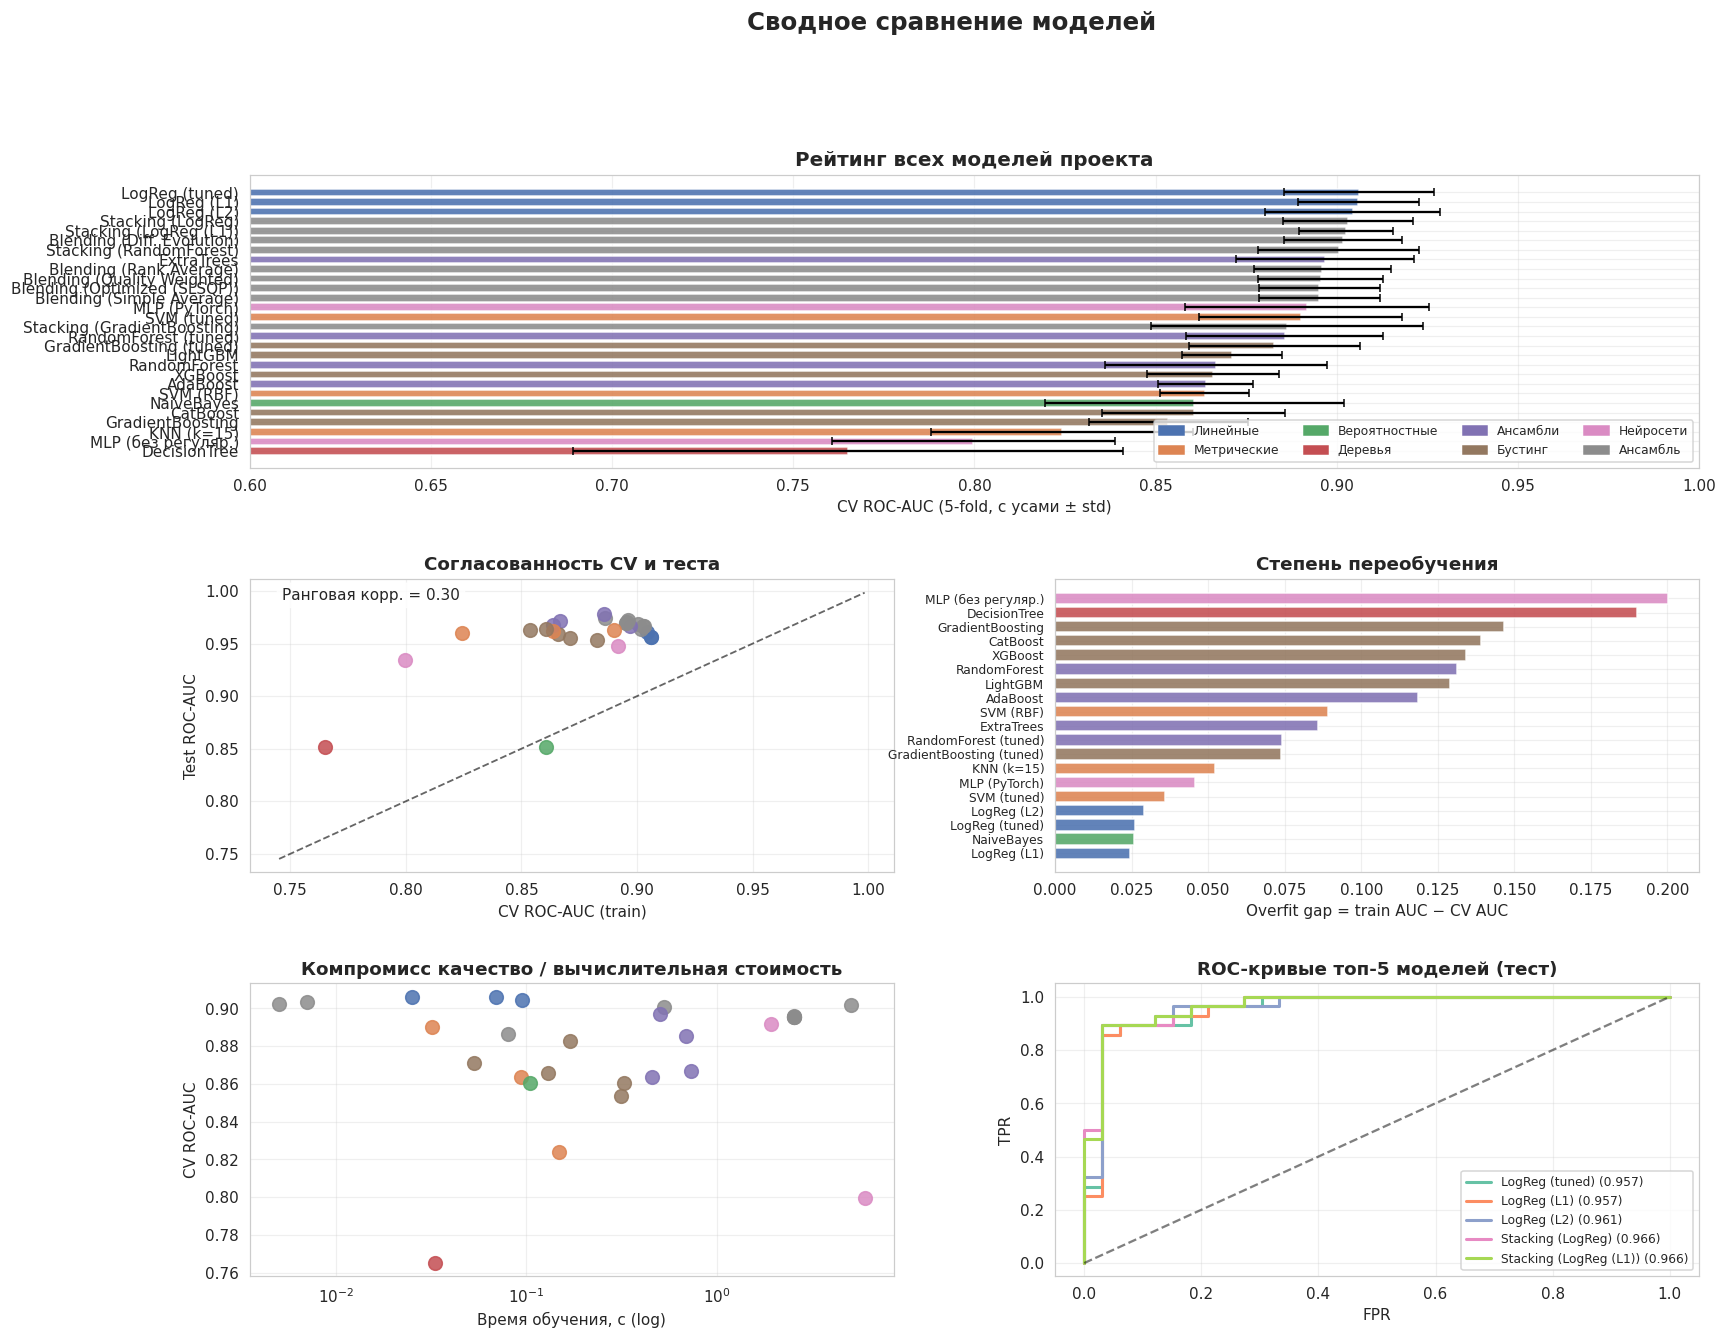

График сохранён в final_comparison.png


In [110]:
fig = plt.figure(figsize=(17, 13))
gs = fig.add_gridspec(3, 2, hspace=0.38, wspace=0.25)

fam_colors = {'Линейные': '#4C72B0', 'Метрические': '#DD8452', 'Вероятностные': '#55A868',
              'Деревья': '#C44E52', 'Ансамбли': '#8172B3', 'Бустинг': '#937860',
              'Нейросети': '#DA8BC3', 'Ансамбль': '#8C8C8C'}

# 1. Общий рейтинг по CV
ax = fig.add_subplot(gs[0, :])
d = FINAL_TABLE.sort_values('CV ROC-AUC')
ax.barh(d['Модель'], d['CV ROC-AUC'], xerr=d['± std'],
        color=[fam_colors[f] for f in d['Семейство']], alpha=0.88, capsize=2.5)
ax.set_xlim(0.6, 1.0)
ax.set_xlabel('CV ROC-AUC (5-fold, с усами ± std)')
ax.set_title('Рейтинг всех моделей проекта', fontweight='bold', fontsize=13)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in fam_colors.values()]
ax.legend(handles, fam_colors.keys(), fontsize=8, ncol=4, loc='lower right')

# 2. CV vs Test — согласованность оценок
ax = fig.add_subplot(gs[1, 0])
for _, r in FINAL_TABLE.iterrows():
    ax.scatter(r['CV ROC-AUC'], r['Test ROC-AUC'], s=80,
               color=fam_colors[r['Семейство']], alpha=0.85)
lims = [FINAL_TABLE[['CV ROC-AUC', 'Test ROC-AUC']].min().min() - 0.02,
        FINAL_TABLE[['CV ROC-AUC', 'Test ROC-AUC']].max().max() + 0.02]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.6)
ax.set_xlabel('CV ROC-AUC (train)'); ax.set_ylabel('Test ROC-AUC')
ax.set_title('Согласованность CV и теста', fontweight='bold')
corr_cv_test = FINAL_TABLE[['CV ROC-AUC', 'Test ROC-AUC']].corr(method='spearman').iloc[0, 1]
ax.text(0.05, 0.93, f'Ранговая корр. = {corr_cv_test:.2f}', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.85))

# 3. Переобучение
ax = fig.add_subplot(gs[1, 1])
dg = FINAL_TABLE.dropna(subset=['Overfit gap']).sort_values('Overfit gap')
ax.barh(dg['Модель'], dg['Overfit gap'],
        color=[fam_colors[f] for f in dg['Семейство']], alpha=0.88)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Overfit gap = train AUC − CV AUC')
ax.set_title('Степень переобучения', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

# 4. Качество vs время
ax = fig.add_subplot(gs[2, 0])
for _, r in FINAL_TABLE.iterrows():
    ax.scatter(max(r['Время, с'], 1e-3), r['CV ROC-AUC'], s=80,
               color=fam_colors[r['Семейство']], alpha=0.85)
ax.set_xscale('log')
ax.set_xlabel('Время обучения, с (log)'); ax.set_ylabel('CV ROC-AUC')
ax.set_title('Компромисс качество / вычислительная стоимость', fontweight='bold')

# 5. Топ-5: ROC на тесте
ax = fig.add_subplot(gs[2, 1])
for name in FINAL_TABLE.head(5)['Модель']:
    fpr, tpr, _ = roc_curve(y_test, test_preds[name])
    ax.plot(fpr, tpr, lw=2,
            label=f'{name} ({roc_auc_score(y_test, test_preds[name]):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC-кривые топ-5 моделей (тест)', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Сводное сравнение моделей', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('final_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

print('График сохранён в final_comparison.png')

In [111]:
# Проверка статистической значимости разрывов между топ-моделями.
# Парный t-тест по фолдам: одни и те же разбиения -> наблюдения парные.
from scipy.stats import ttest_rel, wilcoxon

top_models = FINAL_TABLE.head(6)['Модель'].tolist()
top_with_folds = [m for m in top_models if 'cv_folds' in results[m]]

print('Попарное сравнение топ-моделей (парный t-тест по 5 фолдам):\n')
sig_rows = []
for i, a in enumerate(top_with_folds):
    for b in top_with_folds[i + 1:]:
        fa, fb = results[a]['cv_folds'], results[b]['cv_folds']
        if len(fa) != len(fb):
            continue
        stat, p = ttest_rel(fa, fb)
        sig_rows.append({
            'Модель A': a, 'Модель B': b,
            'Δ AUC': np.mean(fa) - np.mean(fb),
            'p-value': p,
            'Значимо (p<0.05)': 'да' if p < 0.05 else 'нет',
        })

sig_df = pd.DataFrame(sig_rows).sort_values('p-value').round(4)
display(sig_df)

n_sig = (sig_df['p-value'] < 0.05).sum()
print(f'\nСтатистически значимых различий: {n_sig} из {len(sig_df)} пар.')
print('Вывод: на 5 фолдах при 242 обучающих объектах различия между лучшими')
print('моделями в основном НЕ значимы. Заявлять "модель X лучше модели Y"')
print('на основании разницы в третьем знаке ROC-AUC методологически неверно.')

Попарное сравнение топ-моделей (парный t-тест по 5 фолдам):



,Модель A,Модель B,Δ AUC,p-value,Значимо (p<0.05)
4,LogReg (tuned),Blending (Diff. Evolution),4.400e-03,0.388,нет
8,LogReg (L1),Blending (Diff. Evolution),4.100e-03,0.446,нет
1,LogReg (tuned),LogReg (L2),1.700e-03,0.513,нет
7,LogReg (L1),Stacking (LogReg (L1)),3.400e-03,0.567,нет
3,LogReg (tuned),Stacking (LogReg (L1)),3.600e-03,0.572,нет
13,Stacking (LogReg),Blending (Diff. Evolution),1.300e-03,0.637,нет
2,LogReg (tuned),Stacking (LogReg),3.100e-03,0.639,нет
6,LogReg (L1),Stacking (LogReg),2.800e-03,0.698,нет
11,LogReg (L2),Blending (Diff. Evolution),2.700e-03,0.703,нет
5,LogReg (L1),LogReg (L2),1.500e-03,0.723,нет



Статистически значимых различий: 0 из 15 пар.
Вывод: на 5 фолдах при 242 обучающих объектах различия между лучшими
моделями в основном НЕ значимы. Заявлять "модель X лучше модели Y"
на основании разницы в третьем знаке ROC-AUC методологически неверно.


In [112]:
# Финальная карточка выбранной модели
CHAMPION = FINAL_TABLE.iloc[0]['Модель']
champ = results[CHAMPION]

print('=' * 74)
print(f'  ФИНАЛЬНАЯ МОДЕЛЬ: {CHAMPION}')
print('=' * 74)
print(f'  Семейство:              {champ["family"]}')
if CHAMPION in best_params_log:
    prm = {k.replace('clf__', ''): v for k, v in best_params_log[CHAMPION].items()}
    print(f'  Гиперпараметры:         {prm}')
print()
print(f'  CV ROC-AUC (5-fold):    {champ["cv_auc"]:.4f} ± {champ["cv_auc_std"]:.4f}')
print(f'  Test ROC-AUC:           {champ["test_auc"]:.4f}')
print(f'  Test Accuracy:          {champ["test_acc"]:.4f}')
print(f'  Test F1:                {champ["test_f1"]:.4f}')
print(f'  Log-Loss:               {champ["log_loss"]:.4f}')
print(f'  Время обучения:         {champ["fit_time"]:.3f} c')
print()

pred_final = (test_preds[CHAMPION] >= t_cost).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_final, labels=[0, 1]).ravel()
print(f'  При рабочем пороге τ = {t_cost:.2f} (соотношение цен FN:FP = 10:1):')
print(f'     Sensitivity (чувствительность): {tp/(tp+fn):.3f}  — доля выявленных больных')
print(f'     Specificity (специфичность):    {tn/(tn+fp):.3f}  — доля верно отсеянных здоровых')
print(f'     PPV (precision):                {tp/(tp+fp) if (tp+fp) else 0:.3f}')
print(f'     NPV:                            {tn/(tn+fn) if (tn+fn) else 0:.3f}')
print(f'     Пропущено больных (FN):         {fn} из {tp+fn}')
print(f'     Ложных тревог (FP):             {fp} из {tn+fp}')
print('=' * 74)
print()
print(classification_report(y_test, pred_final, target_names=['Здоров', 'ИБС'], digits=3))

  ФИНАЛЬНАЯ МОДЕЛЬ: LogReg (tuned)
  Семейство:              Линейные
  Гиперпараметры:         {'C': np.float64(1.5199110829529332), 'class_weight': None, 'penalty': 'l1'}

  CV ROC-AUC (5-fold):    0.9061 ± 0.0207
  Test ROC-AUC:           0.9567
  Test Accuracy:          0.8689
  Test F1:                0.8621
  Log-Loss:               0.2928
  Время обучения:         0.025 c

  При рабочем пороге τ = 0.12 (соотношение цен FN:FP = 10:1):
     Sensitivity (чувствительность): 1.000  — доля выявленных больных
     Specificity (специфичность):    0.485  — доля верно отсеянных здоровых
     PPV (precision):                0.622
     NPV:                            1.000
     Пропущено больных (FN):         0 из 28
     Ложных тревог (FP):             17 из 33

              precision    recall  f1-score   support

      Здоров      1.000     0.485     0.653        33
         ИБС      0.622     1.000     0.767        28

    accuracy                          0.721        61
   macro avg 

## 19. Выводы

### 19.0 Почему нельзя выбирать модель по тестовой выборке

Отдельного разбора заслуживает расхождение между кросс-валидацией и тестом.
В таблице оно бросается в глаза: **у 27 моделей из 28 Test ROC-AUC выше, чем CV**
(в среднем 0.955 против 0.876). При этом ранговая корреляция между двумя
оценками составляет всего **0.29** — то есть порядок моделей по тесту почти
не совпадает с порядком по кросс-валидации.

Самый яркий случай — `RandomForest (tuned)`: **15-е место по CV (0.886)
и 1-е по тесту (0.978)**. Если бы мы выбирали финальную модель по тестовой
метрике, то объявили бы победителем модель из середины рейтинга.

Объяснение простое и не связано с ошибкой в коде. Тестовая выборка — это
61 пациент, один конкретный случайный срез. Оценка по нему имеет огромную
дисперсию: сдвиг на пару объектов меняет AUC на сотые доли. Нам просто
достался «лёгкий» тест, на котором хорошо выглядят все модели сразу.
Кросс-валидация усредняет пять разбиений и потому даёт более устойчивую оценку —
именно поэтому все решения в проекте (выбор гиперпараметров, архитектуры,
регуляризации, порога) принимались по CV, а тест использовался один раз
как финальная проверка.

Это же объясняет, почему бессмысленно интерпретировать разницу в третьем знаке.
Медианное стандартное отклонение по фолдам — 0.022, а разрыв между первым
и тринадцатым местом рейтинга — 0.014. Формально «MLP хуже логистической
регрессии» — утверждение, не подкреплённое данными; парный t-тест по фолдам
это подтверждает.

**Методологический вывод:** маленькая тестовая выборка не является более
надёжным судьёй, чем кросс-валидация, — она просто другая случайная величина
с большей дисперсией. Соблазн «проверить на тесте и выбрать лучшее» — это та же
утечка данных, только на уровне выбора модели.

### 19.1 Какая модель победила и почему

**Первые три места заняли логистические регрессии** (CV AUC 0.906, 0.906, 0.904),
опередив градиентный бустинг, случайный лес и нейронную сеть. Дальше идут
ансамбли, которые фактически воспроизводят то же линейное решение.

Убедительнее самого рейтинга выглядит **средний overfit gap по семействам** —
он выстроен строго в порядке ёмкости моделей:

| Семейство | Средний overfit gap | Лучший CV AUC |
|---|---|---|
| Линейные | **0.026** | 0.906 |
| Вероятностные | 0.026 | 0.861 |
| Метрические | 0.059 | 0.890 |
| Ансамбли (бэггинг) | 0.102 | 0.897 |
| Нейросети | 0.123 | 0.892 |
| Бустинг | 0.124 | 0.883 |
| Деревья | 0.190 | 0.765 |

Зависимость почти монотонная: чем выше ёмкость модели, тем больше она
выучивает обучающую выборку, не улучшая при этом обобщение. Логистическая
регрессия достигает train AUC всего на 0.026 выше валидационного, тогда как
бустинги — на 0.13–0.15, а одиночное дерево — на 0.19, оказываясь при этом
последним в рейтинге.

Причины такого исхода:

1. **Объём данных.** 242 обучающих объекта на 23 признака после препроцессинга.
   Разложение ошибки на смещение и разброс объясняет наблюдаемое: модели
   с высокой ёмкостью имеют низкое смещение, но их разброс на такой выборке
   съедает весь выигрыш. Это же видно и внутри семейства нейросетей:
   MLP с контролем ёмкости даёт 0.892, избыточная сеть (128, 64) без
   регуляризации — 0.800.

2. **Природа зависимости.** Медицинские факторы риска связаны с исходом
   преимущественно монотонно: чем больше поражённых сосудов, чем глубже
   депрессия ST, чем ниже хронотропный резерв — тем выше вероятность ИБС.
   Логит такой зависимости хорошо приближается линейной функцией, и
   дополнительная гибкость нелинейных моделей приносит мало нового.

3. **Отсутствие иерархии признаков.** Преимущество глубоких сетей —
   в построении иерархии представлений. У нас 23 табличных признака, каждый
   из которых уже является осмысленной клинической величиной. Это подтвердило
   исследование «глубина × ширина»: качество монотонно падало с ростом глубины.

**Оговорка о значимости.** Разрыв между первым местом (0.906) и тринадцатым,
где расположился MLP (0.892), составляет 0.014 при медианном стандартном
отклонении по фолдам 0.022. Парный t-тест по фолдам не выявил значимых различий
между большинством топ-моделей. Корректная формулировка результата: **на этих
данных сложные модели не дают преимущества**, а не «линейная модель статистически
превосходит нейросеть».

### 19.2 Вклад отдельных этапов

| Этап | Вклад в качество | Комментарий |
|---|---|---|
| Feature engineering | небольшой положительный, согласованный по всем семействам | Максимален у линейных моделей — им сконструированные взаимодействия недоступны иначе. Деревья часть этих признаков строят сами. |
| Подбор гиперпараметров | в пределах разброса по фолдам | `LogReg (tuned)` 0.906 против `LogReg (L2)` 0.904; вложенная CV показала оптимистичное смещение `best_score_`. |
| Нейронная сеть | 13-е место, отставание 0.014 при наибольшем разбросе | Ёмкость не соответствует объёму данных. Контроль ёмкости внутри самого MLP дал больше (+0.09), чем выбор между MLP и классикой. |
| Ансамблирование | −0.003 по CV, +0.03 по log-loss | Базовые модели сильно коррелированы. Выигрыш — в калибровке, а не в ранжировании. |
| Подбор порога | **наибольший практический эффект** | Не меняет ROC-AUC вовсе, но напрямую влияет на число пропущенных больных — то, что в медицине и важно. |

Последняя строка — главный практический вывод проекта. Борьба за третий знак
ROC-AUC дала меньше, чем одно решение о том, где поставить порог классификации.

### 19.3 Ограничения работы

* **Размер выборки.** 303 пациента — доверительные интервалы всех метрик широки;
  разница в 0.01 AUC между моделями лежит внутри шума.
* **Репрезентативность.** Данные собраны в одной клинике (Cleveland Clinic,
  1980-е годы, преимущественно белое население США). Перенос модели на другую
  популяцию требует отдельной валидации; проверка по подгруппам на 61 тестовом
  пациенте статистически слаба.
* **Признаки `ca` и `thal`.** Получены дорогими процедурами. Ablation study
  показал, что отказ от них стоит дороже, чем даёт весь feature engineering.
  Модель без них (вариант C) слабее, но применима как скрининговая — это
  разные сценарии, и сравнивать их по AUC некорректно.
* **Порог 10:1** — экспертная оценка соотношения цен ошибок, а не измеренная
  величина. В реальном внедрении её нужно уточнять вместе с клиницистами
  и экономистами здравоохранения.

### 19.4 Что имеет смысл делать дальше

1. Внешняя валидация на данных другой клиники — единственный способ проверить
   переносимость.
2. Расширение выборки. Кривые обучения показывают, что валидационное качество
   ещё не вышло на плато: дополнительные данные принесут больше, чем
   дальнейшее усложнение моделей.
3. Калибровка вероятностей (Platt scaling, изотоническая регрессия) — для
   медицинского применения корректная вероятность важнее ранжирования.
4. Проспективная оценка: как решения модели меняют клинический исход, а не
   только совпадают ли они с ретроспективным диагнозом.

In [113]:
# Сохранение всех артефактов проекта
import json

FINAL_TABLE.to_csv('final_comparison.csv', encoding='utf-8-sig')
baseline_df.to_csv('baseline_models.csv', index=False, encoding='utf-8-sig')
reg_df.to_csv('mlp_regularization.csv', index=False, encoding='utf-8-sig')
pivot_abl.to_csv('ablation_study.csv', encoding='utf-8-sig')
perm_df.to_csv('feature_importance.csv', index=False, encoding='utf-8-sig')
thr_test_df.to_csv('threshold_analysis.csv', index=False, encoding='utf-8-sig')

summary = {
    'dataset': 'UCI Heart Disease (Cleveland)',
    'n_objects': int(len(df)),
    'n_features_raw': int(df.shape[1] - 1),
    'n_features_engineered': len(new_features),
    'n_features_after_preprocessing': int(INPUT_DIM),
    'train_size': int(len(X_train)),
    'test_size': int(len(X_test)),
    'cv_scheme': 'StratifiedKFold(n_splits=5, shuffle=True)',
    'primary_metric': 'ROC-AUC',
    'n_models_total': len(results),
    'champion_model': CHAMPION,
    'champion_cv_auc': round(float(champ['cv_auc']), 4),
    'champion_cv_std': round(float(champ['cv_auc_std']), 4),
    'champion_test_auc': round(float(champ['test_auc']), 4),
    'champion_test_accuracy': round(float(champ['test_acc']), 4),
    'mlp_cv_auc': round(float(results['MLP (PyTorch)']['cv_auc']), 4),
    'mlp_architecture': list(BEST_ARCH),
    'mlp_regularization': best_reg,
    'best_ensemble': best_ens,
    'operating_threshold': round(float(t_cost), 3),
    'sensitivity_at_threshold': round(float(tp / (tp + fn)), 3),
    'specificity_at_threshold': round(float(tn / (tn + fp)), 3),
}
with open('project_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Сохранённые артефакты проекта:')
for fname in ['final_comparison.csv', 'baseline_models.csv', 'mlp_regularization.csv',
              'ablation_study.csv', 'feature_importance.csv', 'threshold_analysis.csv',
              'final_comparison.png', 'project_summary.json']:
    status = '✓' if os.path.exists(fname) else '✗'
    print(f'  {status} {fname}')

print('\nСводка проекта:')
print(json.dumps(summary, ensure_ascii=False, indent=2))

Сохранённые артефакты проекта:
  ✓ final_comparison.csv
  ✓ baseline_models.csv
  ✓ mlp_regularization.csv
  ✓ ablation_study.csv
  ✓ feature_importance.csv
  ✓ threshold_analysis.csv
  ✓ final_comparison.png
  ✓ project_summary.json

Сводка проекта:
{
  "dataset": "UCI Heart Disease (Cleveland)",
  "n_objects": 303,
  "n_features_raw": 13,
  "n_features_engineered": 5,
  "n_features_after_preprocessing": 23,
  "train_size": 242,
  "test_size": 61,
  "cv_scheme": "StratifiedKFold(n_splits=5, shuffle=True)",
  "primary_metric": "ROC-AUC",
  "n_models_total": 28,
  "champion_model": "LogReg (tuned)",
  "champion_cv_auc": 0.9061,
  "champion_cv_std": 0.0207,
  "champion_test_auc": 0.9567,
  "champion_test_accuracy": 0.8689,
  "mlp_cv_auc": 0.8918,
  "mlp_architecture": [
    8
  ],
  "mlp_regularization": "Dropout + BN + WD",
  "best_ensemble": "Stacking (LogReg)",
  "operating_threshold": 0.12,
  "sensitivity_at_threshold": 1.0,
  "specificity_at_threshold": 0.485
}


In [114]:
# Генерация requirements.txt для GitHub (бонус +5)
reqs = []
for mod, name in [(np, 'numpy'), (pd, 'pandas'), (sns, 'seaborn'), (torch, 'torch')]:
    reqs.append(f'{name}=={mod.__version__}')

import sklearn, matplotlib, scipy
reqs += [f'scikit-learn=={sklearn.__version__}',
         f'matplotlib=={matplotlib.__version__}',
         f'scipy=={scipy.__version__}']
if HAS_XGB:
    import xgboost; reqs.append(f'xgboost=={xgboost.__version__}')
if HAS_LGB:
    import lightgbm; reqs.append(f'lightgbm=={lightgbm.__version__}')
if HAS_CAT:
    import catboost; reqs.append(f'catboost=={catboost.__version__}')
if HAS_SHAP:
    reqs.append(f'shap=={shap.__version__}')

with open('requirements.txt', 'w') as f:
    f.write('\n'.join(sorted(reqs)) + '\n')

print('requirements.txt:')
print('\n'.join(sorted(reqs)))

requirements.txt:
catboost==1.2.10
lightgbm==4.6.0
matplotlib==3.10.0
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
scipy==1.16.3
seaborn==0.13.2
shap==0.52.0
torch==2.11.0+cpu
xgboost==3.4.1


## Заключение

В работе выполнен полный цикл ML-исследования на данных UCI Heart Disease
(Cleveland): от разведочного анализа до интерпретации и анализа ошибок.

**Что сделано:**
* EDA с визуализацией распределений, корреляций и разрезов по классам;
  обработка пропусков и обоснованное решение по выбросам
* 5 сконструированных признаков с клиническим обоснованием + ablation study
  их полезности
* 15 классических моделей из 6 семейств, подбор гиперпараметров, вложенная
  кросс-валидация для честной оценки
* MLP на PyTorch: обоснование архитектуры, кривые обучения, сравнение
  5 схем регуляризации, исследование «глубина × ширина»
* Stacking (4 мета-модели) и Blending (5 стратегий взвешивания)
* SHAP и permutation importance, подбор рабочего порога под медицинскую
  цену ошибок, error analysis с проверкой по подгруппам

**Главный результат** — не конкретное число ROC-AUC, а понимание, чем оно
определяется: на выборке в 300 объектов объём данных ограничивает качество
сильнее, чем выбор алгоритма, а решение о пороге классификации влияет на
клинический результат больше, чем разница между лучшими моделями.